# RIM Valuation v19 — Individual (개별 종목)

> **v19 변경사항 (2026-09-15) — FCFF v16_3 과 할인율 완전 통일**
> 1. **Re 단일 경로**: `Re = Rf(Damodaran) + β_blume × ERP(Damodaran)`, β_blume = 0.67·β_raw + 0.33.
>    β_raw 폴백 체인: 10Y 월간 OLS(vs S&P500) → FMP profile β → 1.0 — FCFF 와 동일한 추정기.
>    Rf/ERP 는 DB `damodaran_erp_data` 우선, 없으면 모듈 상수(4.55% / 4.40%, 2026-04-01).
> 2. **RIM 전용 가산항 전부 폐지** (양 모형 Re 불일치 ~170bp 의 원인):
>    size premium(+0.75%) · country premium · earnings-yield 상향 블렌드 ·
>    DB Re_smooth 20% 블렌드 · [7.5%, 18%] 클립. Re_smooth 은 참고 로그로만 출력.
> 3. **CAPM_FINGERPRINT**: FCFF v16_3 과 동일 문자열을 양쪽 실행 로그에 출력 — 파라미터
>    드리프트를 육안으로 즉시 검증 가능.
> 4. 유의: RIM=Re(지분) 할인, FCFF=WACC 할인은 현금흐름 정의 차이로 **정상**이며 통일 대상 아님.
>    TV 방식(RIM: Ohlson ω-감쇠 / FCFF: Gordon g≤GDP)도 모형 정합적 차이로 유지.


> **v18 변경사항 (2026-09-15)**
> 1. **[A. 유보자본 크레딧]** v17은 clean surplus 로 BV 를 누적시키면서 유보자본의 수익을 0%로
>    취급 — 자본비용(Re)은 전액 부과하면서 유보현금의 이자수익조차 크레딧하지 않는 비대칭.
>    v18: `NI(t) = npm_coef x Sales(t) + r_credit x (BV_start(t) - BV0)`,
>    `r_credit = Rf x (1 - 세율)` (런타임 산출, [0, Re-0.5%] 클립). b_eff<0 로 BV 가 줄면
>    크레딧도 음수 — 대칭 유지. (v16=유보자본이 ROE 전체를 번다고 가정: 과대 / v17=0%: 과소
>    / v18=세후 무위험: 하한 공정치)
> 2. **[B. plateau 성장 fade 옵션]** `PH1_FADE = True` (기본 ON): forecast 8Q 이후 성장률을
>    GDP 로 즉시 절벽시키지 않고, 마지막 forecast YoY(g0, 클립 [-20%, +30%]) -> GDP 로
>    선형 감쇠. OFF 시 v17과 동일한 즉시 GDP. 특허 절벽 등 종목별 사유가 있으면 OFF 권장.
> 3. C(size premium 제거 / RIM-FCFF 할인율 통일)는 별도 과제로 보류.


> **v17 변경사항 (2026-09-15)**
> 1. **[구조 수정] Phase 1 RI 산출 로직 교체** — v16까지는 `RI = (ROE고정 − Re) × BV복리` 구조라서
>    plateau 구간(매출 +4%/yr)에서 BV만 유보율 복리로 폭증 → 내재 NI(=ROE×BV)가 매출과 단절되어
>    내재 NPM이 명시 가정(npm_coef)의 2배 이상으로 발산, ΣPV(RI) 과대 산출.
>    v17: `NI = npm_coef × Sales` (손익 앵커) → `RI = NI − Re×BV_start`,
>    `BV(t+1) = BV(t) + b_eff×NI` (clean surplus, 배당+자사주 반영), ROE는 파생값(NI/BV)으로 강등.
>    → 매출·NPM·BV·RI가 단일 회계 항등식으로 연결, plateau에서 ROE 자연 감쇠(경쟁 균형 수렴).
>    v16의 hist_roe blend/floor는 폐지(단절의 원인), ceiling 가드(hist_roe×2.5)만 NI 캡으로 유지.
> 2. **[신규 시트] `RI_Schedule_Q`** — Phase 1 전체를 분기 단위로 전개
>    (forecast 8Q + 이후 전년동기×(1+GDP) 계절 연장). 연간 RI_Schedule와 동일 양식
>    (Sales/NPM/AT/FL/ROE/Re/Spread/BV Start/NI/RI/PV) + 실제 매출·NI·자기자본 입력 열과
>    매출/RI 달성률 자동 수식 → 분기 실적 발표 시 판정 카드와 직접 대조 가능.
>    분기 clean surplus BV는 각 연도 시작 시점에 연간 경로와 정확히 일치.

**용도** : 티커 리스트(`INDIVIDUAL_TICKERS`)를 입력하면 종목별로 RIM(Ohlson 1995)을
실행하고 진단 출력 + 8-시트 엑셀 + DB(`us_rim_valuation`) 에 저장합니다.

**v16 변경사항** (v15 → v16)
- **Quarterly_Proforma 시트(9번째) 추가** — 분기별 예측 vs 실제 추적
  - Sales 예측 8분기(2년)에 대해 예측 매출·OPM·영업이익·NPM·NI 표시
  - NI = RIM 의 npm_coef × 분기 매출 (연간 RI_Schedule 과 정합) / OPM = 동일 방법론 별도 계수(보조지표)
  - 실제값 입력셀(노란색) + 매출·NI 달성률 자동 수식 → 분기 실적 발표마다 예측 달성 여부 추적
  - **연간 소계는 RI_Schedule 와 동일한 4분기 블록 기준**(예측 시작 후 forward 12개월, 역년 아님)으로 정합 — RI_Schedule 의 연도별 Sales·NI 와 정확히 일치
- 엑셀 파일명 : `{ticker}_RIM_{YYYYMMDD}_v16format.xlsx`

**실행 순서** : Cell 1 (환경) → Cell 2 (★입력변수) → Cell 3 (DB) → 엔진 1~4 → 실행 셀
(엔진 셀은 위에서부터 순서대로 1회 실행. 이후에는 Cell 2 값 수정 → 실행 셀 재실행만.
단, [E]~[G] 하이퍼파라미터 변경 시에는 엔진 셀부터 재실행 필요 — monkey-patch 갱신)

---

### v14 → v15 변경점 (FCFF Individual v15 와 동일 정책)

| # | 항목 | 내용 |
|---|---|---|
| 1 | **엑셀 저장 경로** | `C:\Users\82108\OneDrive\INVESTMENT\미국주식\FCFF_valuation_results` (기본값, Cell 2 `[A]`) |
| 2 | **엑셀 파일명** | `{ticker}_RIM_{YYYYMMDD}_v15format.xlsx` — 날짜는 RUN_DATE 사용 (override 시 파일명·DB 일치) |
| 3 | **DB 저장 옵션 정합** | `SAVE_TO_DB=False` 시 Cell 3 의 결과 테이블 생성(DDL)도 함께 생략 |

---

### v13 → v14 변경점

| # | 항목 | 내용 |
|---|---|---|
| 1 | **개별/배치 분리** | `FCFF_DCF_Individual_v14` / `FCFF_DCF_Batch_v14` 와 동일한 PART 구조로 분리 |
| 2 | **입력변수 통합** | 흩어져 있던 상수를 Cell 2 Control Panel `[A]~[G]` 로 집결 |
| 3 | **이중 평가 제거** | 클래스 셀 말미의 `TEST_TICKER` 실행 제거 (아래 설명) |
| 4 | **진단 셀 → 함수** | `print_rim_diagnostics(model)` — 이미 `run()` 된 객체를 받아 **출력만** |
| 5 | **Moat 등급표 통합** | 클래스 내부 3중 중복(docstring/GRADE_PARAMS/ALL_PARAMS) → `MOAT_TIERS` 단일화 |
| 6 | **민감도 TV 정합** | 히트맵이 v12 TV 모드를 따르도록 수정 (ohlson → Re×ω, gordon → Re×g) |
| 7 | **티커 소스 통일** | FCFF v14 와 동일하게 스크리닝 리스트 우선 → 두 모형 유니버스 일치 |

**③ 이중 평가 문제** — v13 은 `RIMModel` 클래스 셀 마지막에
`TEST_TICKER = "TMUS"` 평가가 들어 있었고, 이 위치가 **Cell 4.6 (v12 Validity Patch)
이전**이라 항상 **v11 TV 로직**(`g = max(Re−0.75%, GDP)`, RI 영구멀티플 ~147배)으로
계산되었습니다. 같은 종목이 패치 후 진단 셀·배치 셀에서 v12 로 다시 평가되면서
적정주가가 서로 다르게 나왔습니다. v14 는 PART 2(엔진)를 모두 적용한 뒤
PART 3(실행)에서만 평가하므로 실행 순서에 의한 값 불일치가 구조적으로 사라집니다.

**환경** : 노트북(`Hoyoung_Park`)/데스크탑(`82108`) 자동 경로 감지 · Python 3.9 · PyCharm

# ━━━━━━━━━━  PART 1 · 환경 & 입력변수  ━━━━━━━━━━

In [9]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 1 · 환경 설정 — 경로 자동 감지 · 모듈 import · DB 엔진
#  ───────────────────────────────────────────────────────────────────────
#  노트북/데스크탑 어느 환경에서 실행해도 config.py 와
#  us_target_ticker_list_screened_20260411.py 를 자동으로 import 합니다.
#    · 노트북   : C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast\DATA
#    · 데스크탑 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
# ═══════════════════════════════════════════════════════════════════════
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# ── ① DATA 폴더가 있는 프로젝트 루트 자동 감지 ─────────────────────────
_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",           # 노트북
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",  # 데스크탑
]

def _setup_path() -> str:
    """① 현재 파일/작업폴더에서 상위로 올라가며 DATA 폴더 탐색
       ② 실패 시 _CANDIDATE_ROOTS (노트북/데스크탑 고정 경로) 순회"""
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] root 자동 감지 : {root}")
            return root
    for candidate in _CANDIDATE_ROOTS:
        if os.path.isdir(candidate) and os.path.isdir(os.path.join(candidate, "DATA")):
            if candidate not in sys.path:
                sys.path.insert(0, candidate)
            print(f"[PATH] root 후보 경로 : {candidate}")
            return candidate
    raise EnvironmentError(
        "DATA 폴더를 찾을 수 없습니다.\n"
        "_CANDIDATE_ROOTS 를 현재 환경에 맞게 수정하세요."
    )

_ROOT = _setup_path()
print(f"[확인] 프로젝트 루트 : {_ROOT}")
print(f"[확인] DATA 경로    : {os.path.join(_ROOT, 'DATA')}")

# ── ② 표준/외부 라이브러리 ──────────────────────────────────────────────
import gc, math, time, traceback
import requests
from datetime import datetime
from typing import Optional, Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import pymysql
from scipy import stats
from IPython.display import display
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text

# ── ③ 내부 모듈 (노트북/데스크탑 공용 — sys.path 에 루트 추가됨) ────────
from DATA.config import get_db_info, get_engine
from DATA.universal_ts_forecast_function_v2 import clear_memory

# ── ④ 티커 리스트 import — 스크리닝 파일 우선, 없으면 기존 2000 리스트 ──
#     ★ v14: FCFF v14 와 동일한 티커 소스를 사용해 두 모형의 유니버스를 일치시킴
#            (v13 RIM 은 us_target_ticker_list_2000 고정이었습니다)
_TICKER_MODULES = [
    "DATA.us_target_ticker_list_screened_20260411",   # ① 스크리닝된 최신 리스트 (우선)
    "DATA.us_target_ticker_list_2000",                # ② 기존 전체 리스트 (fallback)
]
import importlib
US_TICKER_LIST, _tk_src = None, None
for _mod_name in _TICKER_MODULES:
    try:
        _tk_mod = importlib.import_module(_mod_name)
    except ImportError:
        continue
    if hasattr(_tk_mod, "ticker_list"):
        US_TICKER_LIST = list(_tk_mod.ticker_list)
    else:   # 변수명이 다르면 파일 내 가장 긴 문자열 리스트로 자동 감지
        _cands = [v for v in vars(_tk_mod).values()
                  if isinstance(v, (list, tuple)) and v and all(isinstance(x, str) for x in v)]
        if not _cands:
            continue
        US_TICKER_LIST = list(max(_cands, key=len))
    _tk_src = _mod_name
    break
if US_TICKER_LIST is None:
    raise ImportError(
        "티커 리스트 파일을 찾지 못했습니다.\n"
        "DATA 폴더에 us_target_ticker_list_screened_20260411.py 또는 "
        "us_target_ticker_list_2000.py 가 있는지 확인하세요."
    )
print(f"[OK] 티커 리스트 : {_tk_src}  ({len(US_TICKER_LIST):,}개)")

# ── ⑤ 로그 유틸 & DB 엔진 ───────────────────────────────────────────────
def log(tag: str, msg: str):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{tag}] {msg}", flush=True)

db_info = get_db_info()
engine  = get_engine(db_info)

print(f"[OK] 환경 설정 완료  |  대상 티커: {len(US_TICKER_LIST):,}개")


[PATH] root 자동 감지 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] 프로젝트 루트 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] DATA 경로    : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
[OK] 티커 리스트 : DATA.us_target_ticker_list_screened_20260411  (1,026개)
[OK] 환경 설정 완료  |  대상 티커: 1,026개


In [10]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 2 · ★ 입력변수 통합 (Control Panel) — 모든 입력은 이 셀에서만 수정  [v15]
#  ───────────────────────────────────────────────────────────────────────
#  ※ Cell 1 (환경 설정) 실행 후 이 셀을 실행하세요.
#  ※ 이후 엔진 셀들은 이 셀의 값을 참조합니다. 값 변경 시:
#     하이퍼파라미터([E]~[G])는 엔진 셀 재실행 필요, 나머지는 이 셀만 재실행.
# ═══════════════════════════════════════════════════════════════════════

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  [A] 평가 대상 티커 리스트 — 여기에 원하는 종목들을 입력하세요
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INDIVIDUAL_TICKERS = ["INCY"]   # 평가할 종목 리스트

VERBOSE_SINGLE   = True    # True → 종목별 상세 계산 로그 출력
SHOW_DIAGNOSTICS = True    # True → RIM 분해 진단 출력 (Re/Phase1/Phase2/TV/Breakdown)
SHOW_PLOTS       = True    # True → RI 경로 · EVA 시계열 · TP 민감도 차트
SAVE_TO_DB       = False    # True → us_rim_valuation 에 저장

# ── 엑셀 저장 설정 (v15) ────────────────────────────────────────────────
EXPORT_EXCEL = True                 # True → 종목별 8-시트 엑셀 저장
#   저장 폴더 : 데스크탑(82108) 경로 우선, 없으면(노트북 등) 홈 폴더 하위로 fallback
#   ※ FCFF Individual v15 와 동일 폴더 사용
_EXPORT_DIR_DESKTOP = Path(r"C:\Users\82108\OneDrive\INVESTMENT\미국주식\FCFF_valuation_results")
EXPORT_DIR = (_EXPORT_DIR_DESKTOP
              if os.name == "nt" and os.path.isdir(r"C:\Users\82108")
              else Path.home() / "FCFF_valuation_results")
#   파일명 형식 : {ticker}_RIM_{YYYYMMDD}_v15format.xlsx  (날짜 = RUN_DATE)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  [B] 측정일 (RUN_DATE)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RUN_DATE_OVERRIDE = None            # None → 오늘 날짜 자동 / "2026-06-08" → 고정
RUN_DATE = RUN_DATE_OVERRIDE or datetime.now().strftime("%Y-%m-%d")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  [C] FMP API
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FMP_API_KEY = "hT0gAk87j9xZx4PlBApvBqfVL5IahvgV"   # FMP Starter API 키
FMP_BASE    = "https://financialmodelingprep.com/api/v3"
FMP_LIMIT   = 40                    # 분기 재무제표 최대 조회 개수
FMP_SLEEP   = 0.35                  # API 호출 간격 (초) — 레이트리밋 회피

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  [D] DB 테이블
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TABLE_SALES  = "us_revenue_forecast_data"   # Sales 시계열 예측 결과 (입력)
TABLE_RE     = "us_rim_spread_data"         # Re_smooth (참고용 입력)
TABLE_RESULT = "us_rim_valuation"           # RIM 결과 저장 (출력)
DEFAULT_PORT = 3307                         # MySQL investar 포트

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  [E] 모델 하이퍼파라미터
#      ※ 이 섹션 값을 바꾸면 PART 2 (엔진) 셀을 재실행해야 반영됩니다.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FORECAST_HORIZON = 8         # Sales forecast 분기 수 (8Q = 2년, Phase 1 베이스)
MIN_HISTORY      = 12        # DuPont OLS 최소 분기 수
OLS_MIN_R2       = 0.20      # 비율 회귀 채택 최소 R^2 (FCFF 보다 완화 — ratio 는 noisy)
OLS_MIN_SAMPLES  = 12        # 비율 회귀 채택 최소 표본 수
WINSORIZE_LIMITS = (0.05, 0.95)   # 비율 계수 추정 시 winsorize 범위

GDP_GROWTH       = 0.04      # terminal growth 상한 (명목 GDP)
TV_RE_GAP        = 0.0075    # [v12 이후 미사용] 구 TV 공식 잔재 — 참조용으로만 유지
RETENTION_FLOOR  = -0.50     # 유보율 하한 (buyback > NI 예외 케이스 허용)
BV_RETENTION_CAP = 0.75      # BV 성장용 유보율 상한

QUALITY_RE_HAIRCUT_MAX   = 0.000   # v9 이후 비활성 (인위적 Re 할인 없음)
PHASE1_ROE_FLOOR_RATIO   = 0.80    # Phase 1 ROE 하한 (과거 TTM ROE 대비)
PHASE1_ROE_CEILING_RATIO = 2.50    # Phase 1 ROE 상한 (과거 TTM ROE 대비)

# ── [v18] Phase 1 구조 옵션 ──────────────────────────────────────────
PH1_CASH_CREDIT   = True    # A: 유보자본(BV-BV0)에 세후 무위험 수익 크레딧 (권장 상시 ON)
PH1_FADE          = True    # B: plateau 성장 fade (마지막 forecast YoY -> GDP 선형 감쇠)
PH1_FADE_G0_CAP   = 0.30    # fade 시작 성장률 상한 (하이퍼그로스 폭주 방지)
PH1_FADE_G0_FLOOR = -0.20   # fade 시작 성장률 하한

# ── [v19] 공통 자본비용 파라미터 — FCFF v16_3 과 동일 (할인율 통일) ──
#    수정 시 반드시 FCFF 노트북과 함께 수정할 것 (CAPM_FINGERPRINT 로 상호 검증)
TABLE_ERP         = "damodaran_erp_data"   # Damodaran ERP 이력 (있으면 DB 우선)
_DAMODARAN_RF     = 0.0455          # 10Y T.Bond yield (무위험이자율)
_DAMODARAN_ERP    = 0.0440          # Implied Equity Risk Premium
_DAMODARAN_DATE   = "2026-04-01"    # 데이터 시점
_DAMODARAN_SOURCE = "module_const"
_BLUME_W_RAW    = 0.67              # raw beta 가중치
_BLUME_W_MARKET = 0.33              # 시장 beta(=1.0) 가중치
CAPM_FINGERPRINT = ("CAPM|Rf={:.4f}|ERP={:.4f}|asof={}"
                    "|Blume={:.2f}/{:.2f}|beta=OLS10Ym->FMPprofile->1.0"
                    "|prem=none|shares=wAvgShsOutDil"
                    ).format(_DAMODARAN_RF, _DAMODARAN_ERP, _DAMODARAN_DATE,
                             _BLUME_W_RAW, _BLUME_W_MARKET)
print(f"  CAPM fingerprint : {CAPM_FINGERPRINT}")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  [F] Moat 등급표 & Phase 1 plateau
#      ★ v14: v13 에서 클래스 내부에 3중(docstring / GRADE_PARAMS / ALL_PARAMS)으로
#             흩어져 값이 서로 달랐던 등급표를 이 한 곳으로 통합했습니다.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  (등급, omega, Phase2 년수, EVA spread 임계, ROE-Re spread 임계, n_pos 최소)
#   · 1차 분류: (EVA spread > 임계) OR (ROE-Re spread > 임계)
#   · omega : Ohlson LIM 지속계수 RI(t) = omega x RI(t-1)
MOAT_TIERS = [
    ("Exceptional moat", 0.992, 30, 0.25, 1.50, 18),
    ("Wide moat",        0.985, 28, 0.15, 0.80, 16),
    ("Wide-Narrow moat", 0.975, 25, 0.10, 0.40, 13),
    ("Narrow moat",      0.960, 20, 0.06, 0.20, 10),
    ("Some moat",        0.940, 15, 0.03, 0.05,  7),
    ("No moat",          0.620,  5, float("-inf"), float("-inf"), 0),
]

#  n_pos 페널티로 '강등'되었을 때 적용할 별도 표 (v13 원본 동작).
#  v13 은 1차 분류표와 강등표의 값이 달라, 같은 'No moat' 라도
#  1차 분류 도달 시 (0.620, 5yr) / 강등 도달 시 (0.880, 10yr) 이 적용됐습니다.
MOAT_TIERS_DEMOTED_V13 = {
    "Exceptional moat": (0.990, 30),
    "Wide moat":        (0.980, 28),
    "Wide-Narrow moat": (0.970, 25),
    "Narrow moat":      (0.950, 20),
    "Some moat":        (0.940, 15),
    "No moat":          (0.880, 10),
}
MOAT_USE_V13_DEMOTED_TABLE = True   # True  → v13 동작 100% 재현 (기본)
                                    # False → 강등 후에도 MOAT_TIERS 값 사용 (완전 단일화)

MOAT_UNKNOWN_OMEGA  = 0.760   # EVA/ROE spread 둘 다 산출 실패 시 fallback
MOAT_UNKNOWN_PHASE2 = 8

# ── Phase 1 기간: moat 등급별 plateau (Mauboussin & Johnson 1997 CAP) ──
#    Phase 1 = Sales forecast 2년(고정) + 등급별 GDP 연장
PHASE1_BASE_YR  = 2
PHASE1_EXTRA_YR = {
    "Exceptional moat":   5,   # 총 7yr
    "Wide moat":          4,   # 총 6yr
    "Wide-Narrow moat":   3,   # 총 5yr
    "Narrow moat":        2,   # 총 4yr
    "Some moat":          1,   # 총 3yr
    "No moat":            0,   # 총 2yr
    "Unknown (fallback)": 1,
}
PHASE1_YR_BY_MOAT = {g: PHASE1_BASE_YR + e for g, e in PHASE1_EXTRA_YR.items()}

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  [G] v12 Validity Guard — 통화가드 · TV 보수화 · Sanity Guard
#      ★ v14: v13 에서 패치 셀(Cell 4.6) 안에 있던 상수를 여기로 이관
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
V12_CURRENCY_GUARD  = True       # ① 재무제표 reportedCurrency != USD → 평가 제외 (ADR 차단)
V12_TV_MODE         = "ohlson"   # ② "ohlson" : TV = RI_T x w/(1+Re-w)  (기본, 모형 정합)
                                 #    "gordon" : TV = RI_T x (1+g)/(Re-g), g<=min(GDP,Rf,Re-스프레드)
V12_MIN_TV_SPREAD   = 0.02       # ② gordon 모드에서 Re - g 최소 스프레드
V12_TV_RI_MULT_CAP  = 35.0       # ② TV / RI_T 배수 상한 (이중 안전장치)
V12_SANITY_GUARD    = True       # ③ 내재가치 / 실제 시총 괴리 검사
V12_SANITY_MC_RATIO = 30.0       # ③ 허용 배율 (30배 초과 또는 1/30 미만 → 제외)


# ── 적용 요약 출력 ──────────────────────────────────────────────────────
print("=" * 72)
print("[Cell 2] 입력변수 적용 완료 — 개별(Individual) RIM Valuation v16")
print(f"  평가 대상        : {INDIVIDUAL_TICKERS}  (총 {len(INDIVIDUAL_TICKERS)}종목)")
print(f"  측정일 RUN_DATE  : {RUN_DATE}  (override={RUN_DATE_OVERRIDE})")
print(f"  엑셀 저장        : {EXPORT_EXCEL}  →  {EXPORT_DIR}")
print(f"  DB 저장          : {SAVE_TO_DB}  →  {TABLE_RESULT}")
print(f"  TV 모드          : '{V12_TV_MODE}'  "
      f"(ohlson: TV=RI·w/(1+Re-w) | gordon: g<=min(GDP,Rf,Re-{V12_MIN_TV_SPREAD:.0%}))")
print(f"  가드             : 통화={V12_CURRENCY_GUARD}  "
      f"Sanity={V12_SANITY_GUARD}(±{V12_SANITY_MC_RATIO:.0f}배)  "
      f"TV<= {V12_TV_RI_MULT_CAP:.0f}xRI")
print(f"  Moat 강등표      : MOAT_USE_V13_DEMOTED_TABLE={MOAT_USE_V13_DEMOTED_TABLE}")
print("=" * 72)


  CAPM fingerprint : CAPM|Rf=0.0455|ERP=0.0440|asof=2026-04-01|Blume=0.67/0.33|beta=OLS10Ym->FMPprofile->1.0|prem=none|shares=wAvgShsOutDil
[Cell 2] 입력변수 적용 완료 — 개별(Individual) RIM Valuation v16
  평가 대상        : ['INCY']  (총 1종목)
  측정일 RUN_DATE  : 2026-09-16  (override=None)
  엑셀 저장        : True  →  C:\Users\82108\OneDrive\INVESTMENT\미국주식\FCFF_valuation_results
  DB 저장          : False  →  us_rim_valuation
  TV 모드          : 'ohlson'  (ohlson: TV=RI·w/(1+Re-w) | gordon: g<=min(GDP,Rf,Re-2%))
  가드             : 통화=True  Sanity=True(±30배)  TV<= 35xRI
  Moat 강등표      : MOAT_USE_V13_DEMOTED_TABLE=True


In [11]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 3 · DB 연결 & 결과 테이블 초기화 — 사용자 입력 없음
#  ───────────────────────────────────────────────────────────────────────
#  PK = (ticker, date, year_label)
#    → 한 종목의 Phase1 각 연도 / Phase2 각 연도 / TV 행이 각각 저장됩니다.
#    → 측정일(date)이 달라지면 별도 행 → 시계열 추적 가능
# ═══════════════════════════════════════════════════════════════════════

def get_conn():
    return pymysql.connect(
        host       = db_info["host"],
        port       = int(db_info.get("port", DEFAULT_PORT)),
        user       = db_info["user"],
        password   = db_info["password"],
        db         = db_info.get("database", "investar"),
        charset    = "utf8mb4",
        autocommit = False,
        cursorclass= pymysql.cursors.DictCursor,
    )


CREATE_SQL = f"""
CREATE TABLE IF NOT EXISTS `{TABLE_RESULT}` (
  `id`              BIGINT      NOT NULL AUTO_INCREMENT,
  `date`            DATE        NOT NULL COMMENT 'run date',
  `ticker`          VARCHAR(20) NOT NULL,
  `year_label`      VARCHAR(10)          COMMENT 'e.g. 2026 or Ph2-Y3',
  `phase`           VARCHAR(10)          COMMENT 'ph1 / ph1e / ph2 / tv',
  `sales_forecast`  DOUBLE               COMMENT 'annual sales forecast',
  `npm_forecast`    DOUBLE               COMMENT 'net profit margin',
  `asset_turnover`  DOUBLE,
  `fin_leverage`    DOUBLE,
  `roe_forecast`    DOUBLE,
  `re`              DOUBLE               COMMENT 'cost of equity',
  `ri_spread`       DOUBLE               COMMENT 'ROE - Re',
  `bv_start`        DOUBLE               COMMENT 'book value (start of year)',
  `ri`              DOUBLE               COMMENT 'residual income',
  `pv_ri`           DOUBLE               COMMENT 'PV of RI',
  `moat_label`      VARCHAR(30),
  `rho`             DOUBLE               COMMENT 'AR(1) persistence coef (omega)',
  `n_phase2`        INT,
  `g_terminal`      DOUBLE               COMMENT 'ohlson 모드에서는 RI 연간변화율(w-1)',
  `pv_all_ri`       DOUBLE,
  `terminal_value`  DOUBLE,
  `intrinsic_value` DOUBLE,
  `current_price`   DOUBLE,
  `upside_pct`      DOUBLE,
  `target_price`    DOUBLE,
  `created_at`      DATETIME    DEFAULT CURRENT_TIMESTAMP,
  PRIMARY KEY (`id`),
  UNIQUE KEY uq_main (`ticker`, `date`, `year_label`),
  INDEX idx_ticker (`ticker`),
  INDEX idx_date   (`date`)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
"""

# ── v15: SAVE_TO_DB=False 이면 결과 테이블 생성/보강(DDL)도 생략 ────────
if SAVE_TO_DB:
    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.execute(CREATE_SQL)
        conn.commit()
        log("DB", f"테이블 준비 완료: {TABLE_RESULT}")
    finally:
        conn.close()

    # ★ v12/v14 확장 컬럼 보강 (이미 있으면 무시)
    _ALTER_COLS = [
        ("tv_mode",        "VARCHAR(10)"),
        ("mktcap_ratio",   "DOUBLE"),
        ("reported_currency", "VARCHAR(10)"),
    ]
    conn = get_conn()
    try:
        with conn.cursor() as cur:
            for _c, _t in _ALTER_COLS:
                try:
                    cur.execute(f"ALTER TABLE `{TABLE_RESULT}` ADD COLUMN `{_c}` {_t}")
                except Exception:
                    pass   # 이미 존재
        conn.commit()
    finally:
        conn.close()
else:
    log("DB", "SAVE_TO_DB=False → 결과 테이블 생성 생략 (조회용 연결만 유지)")

# 연결 테스트
try:
    with engine.connect() as c:
        c.execute(text("SELECT 1"))
    log("DB", f"연결 성공  host={db_info.get('host')}  port={db_info.get('port')}")
except Exception as e:
    log("DB", f"연결 실패: {e}")


[00:01:46][DB] SAVE_TO_DB=False → 결과 테이블 생성 생략 (조회용 연결만 유지)
[00:01:46][DB] 연결 성공  host=192.168.0.230  port=3307


# ━━━━━━━━━━  PART 2 · 엔진 (RIMModel + 패치)  ━━━━━━━━━━

## 엔진 1 · RIMModel 코어 — Sales 로드 → DuPont ROE → RI Path

`load_sales` / `load_financials` / `load_re` / `estimate_dupont_coefs` /
`forecast_roe_phase1` / `compute_eva_spread` / `moat_to_omega_and_years` /
`compute_ri_path` / `compute_valuation` / `save_to_db` / `plot`

> ★ v14: 클래스 정의만 수행하며 **평가는 실행하지 않습니다**.
> Moat 등급표는 Cell 2 의 `MOAT_TIERS` 를 참조합니다.

In [12]:
# ═══════════════════════════════════════════════════════════════
#  RIMModel — Ohlson (1995) Residual Income Valuation
#  Sales-driven DuPont ROE  +  AR(1) RI spread decay
# ═══════════════════════════════════════════════════════════════

class RIMModel:
    """
    Residual Income Model (Ohlson 1995) with Sales-driven DuPont forecasting.

    Valuation:
        P = BV_0 + sum( RI_t / (1+Re)^t ) + PV(TV)
        RI_t = (ROE_t - Re) * BV_{t-1}
        BV_t = BV_{t-1} * (1 + ROE_t * retention_t)

    Phase 1 (2yr): Sales forecast → DuPont → ROE
    Phase 2 (5~15yr): AR(1) RI decay  RI(t) = omega * RI(t-1)
                      omega determined by EVA moat (Ohlson 1995, Fama-French 1995)
    Phase 3: TV = RI_last / (Re - g)  [if RI_last > 0]

    References:
        Ohlson (1995) JAR, Feltham & Ohlson (1995) JAR,
        Fama & French (1995) JF, Mauboussin & Johnson (1997) FAJ,
        Damodaran (2002) Investment Valuation
    """

    def __init__(
        self,
        ticker: str,
        engine,
        fmp_api_key: str = FMP_API_KEY,
        forecast_horizon: int = FORECAST_HORIZON,
        min_history: int = MIN_HISTORY,
        gdp_growth: float = GDP_GROWTH,
        verbose: bool = False,
    ):
        self.ticker          = ticker.upper()
        self.engine          = engine
        self.api_key         = fmp_api_key
        self.horizon         = forecast_horizon
        self.min_history     = min_history
        self.gdp_growth      = gdp_growth
        self.verbose         = verbose

        self._sales_actual:   Optional[pd.Series] = None
        self._sales_forecast: Optional[pd.Series] = None
        self._inc:            Optional[pd.DataFrame] = None
        self._bs:             Optional[pd.DataFrame] = None
        self._re:             Optional[float] = None
        self._eva_cache:      Optional[dict] = None
        self._cf:             Optional[pd.DataFrame] = None  # [FIX] cashflow
        self._using_ic:       bool = False                   # 음수 BV → IC 대체 여부
        self._n_phase1:       int  = 2                       # 실제 사용된 Phase1 기간
        self.result_df:       Optional[pd.DataFrame] = None
        self.valuation:       Optional[Dict] = None

    # ─────────────────────────────────────────────────────────
    # 1. Data Loading
    # ─────────────────────────────────────────────────────────

    def load_sales(self) -> "RIMModel":
        """
        Load Sales from DB (us_revenue_forecast_data).
        Identical pattern to DCFModel.load_sales() — cursor.execute/fetchall only.
        """
        conn_local = get_conn()
        try:
            with conn_local.cursor() as cur:
                cur.execute(
                    f"SELECT date, data_type, model, value "
                    f"FROM `{TABLE_SALES}` "
                    f"WHERE ticker=%s AND item='sale' AND data_type='actual' "
                    f"ORDER BY date",
                    (self.ticker,)
                )
                actual_rows = cur.fetchall()

            with conn_local.cursor() as cur:
                cur.execute(
                    f"SELECT MAX(forecast_date) AS max_fd "
                    f"FROM `{TABLE_SALES}` "
                    f"WHERE ticker=%s AND item='sale' AND data_type='forecast'",
                    (self.ticker,)
                )
                row = cur.fetchone()
                max_fd = row["max_fd"] if row else None

            fc_rows = []
            if max_fd:
                with conn_local.cursor() as cur:
                    cur.execute(
                        f"SELECT date, data_type, model, value "
                        f"FROM `{TABLE_SALES}` "
                        f"WHERE ticker=%s AND item='sale' "
                        f"  AND data_type='forecast' AND forecast_date=%s "
                        f"ORDER BY model, date",
                        (self.ticker, max_fd)
                    )
                    fc_rows = cur.fetchall()
        finally:
            conn_local.close()

        if not actual_rows:
            raise ValueError(f"[{self.ticker}] No actual Sales — run revenue forecast notebook first")

        act_df = pd.DataFrame(actual_rows)
        act_df["date"]  = pd.to_datetime(act_df["date"])
        act_df["value"] = pd.to_numeric(act_df["value"], errors="coerce")
        actual = (act_df.sort_values("date")
                        .drop_duplicates("date", keep="last")
                        .set_index("date")["value"])

        if not fc_rows:
            raise ValueError(f"[{self.ticker}] No forecast Sales (forecast_date={max_fd})")

        fc_df = pd.DataFrame(fc_rows)
        fc_df["date"]  = pd.to_datetime(fc_df["date"])
        fc_df["value"] = pd.to_numeric(fc_df["value"], errors="coerce")

        priority  = ["Ensemble", "SARIMA", "ETS", "Theta"]
        available = fc_df["model"].unique().tolist()
        ordered   = [m for m in priority if m in available] +                     [m for m in available if m not in priority]

        forecast = pd.Series(dtype=float)
        for model_name in ordered:
            fc = (fc_df[fc_df["model"] == model_name]
                  .sort_values("date")
                  .drop_duplicates("date", keep="last")
                  .set_index("date")["value"].dropna())
            if len(fc) >= self.horizon:
                forecast = fc.iloc[:self.horizon]
                break
            elif len(fc) > 0 and forecast.empty:
                forecast = fc

        if forecast.empty:
            raise ValueError(f"[{self.ticker}] Forecast Sales empty")

        if len(forecast) < self.horizon:
            extra_idx = pd.date_range(
                start=forecast.index[-1] + pd.offsets.QuarterEnd(1),
                periods=self.horizon - len(forecast), freq="QE"
            )
            forecast = pd.concat([
                forecast,
                pd.Series([float(forecast.iloc[-1])] * len(extra_idx), index=extra_idx)
            ])

        self._sales_actual   = actual
        self._sales_forecast = forecast.iloc[:self.horizon]
        if self.verbose:
            log(self.ticker, f"Sales loaded  actual={len(actual)}Q  forecast={len(self._sales_forecast)}Q")
        return self

    def _fmp_get(self, endpoint: str, period: str = "quarter", limit: int = FMP_LIMIT) -> pd.DataFrame:
        url = f"{FMP_BASE}/{endpoint}/{self.ticker}"
        for attempt in range(3):
            try:
                r = requests.get(url, params={"period": period, "limit": limit,
                                              "apikey": self.api_key}, timeout=20)
                if r.status_code == 429:
                    time.sleep(1.5 + attempt); continue
                r.raise_for_status()
                data = r.json()
                if isinstance(data, dict) and "Error Message" in data:
                    return pd.DataFrame()
                return pd.DataFrame(data) if isinstance(data, list) else pd.DataFrame()
            except Exception as e:
                if attempt == 2:
                    if self.verbose: log(self.ticker, f"FMP {endpoint} failed: {e}")
                    return pd.DataFrame()
                time.sleep(FMP_SLEEP + attempt * 0.5)
        return pd.DataFrame()

    def _parse_date_col(self, df: pd.DataFrame) -> pd.DataFrame:
        """acceptedDate → look-ahead-bias-free quarter-end date (same as DCFModel)"""
        df = df.copy()
        df["report_date"] = pd.to_datetime(
            df.get("acceptedDate", df.get("fillingDate", pd.NaT)), errors="coerce"
        )
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        def _qend(row):
            if pd.notna(row.get("report_date")):
                return (row["report_date"] - pd.Timedelta(days=45)).to_period("Q").to_timestamp("Q")
            return row["date"].to_period("Q").to_timestamp("Q")
        df["date"] = df.apply(_qend, axis=1)
        return df.sort_values("date").drop_duplicates("date", keep="last").reset_index(drop=True)

    def load_financials(self) -> "RIMModel":
        """FMP API → IS + BS + CF (quarterly)"""
        time.sleep(FMP_SLEEP)
        inc = self._fmp_get("income-statement")
        time.sleep(FMP_SLEEP)
        bs  = self._fmp_get("balance-sheet-statement")
        time.sleep(FMP_SLEEP)
        cf  = self._fmp_get("cash-flow-statement")  # [FIX] 배당 데이터용
        if inc.empty or bs.empty:
            raise ValueError(f"[{self.ticker}] FMP IS/BS load failed")
        self._inc = self._parse_date_col(inc)
        self._bs  = self._parse_date_col(bs)
        self._cf  = self._parse_date_col(cf) if not cf.empty else None  # [FIX]
        if self.verbose:
            cf_q = len(self._cf) if self._cf is not None else 0
            log(self.ticker, f"IS={len(self._inc)}Q / BS={len(self._bs)}Q / CF={cf_q}Q")
        return self


    def load_re(self) -> "RIMModel":
        """
        [v19] Re 단일 경로 — FCFF v16_3 (v11.5 doctrine) 과 완전 통일.

            Re = Rf(Damodaran) + beta_blume x ERP(Damodaran)
            beta_blume = 0.67 x beta_raw + 0.33 x 1.0
            beta_raw   = 10Y 월간 OLS (vs S&P500) -> FMP profile beta -> 1.0 폴백

        v18 까지의 RIM 전용 항목 전부 폐지:
          size premium / country premium / earnings-yield 상향 블렌드 /
          DB Re_smooth 20% 블렌드 / [7.5%, 18%] 클립.
        Re_smooth 은 참고 로그로만 출력 (밸류에이션 미사용).
        """
        self._re = float(self.estimate_re_rim())

        # Re_smooth: 참고 로그 전용 (v19 — 블렌드 폐지)
        re_db = None
        try:
            sql = text(f"""
                SELECT value FROM `{TABLE_RE}`
                WHERE ticker=:t AND indicator='Re_smooth'
                ORDER BY date DESC LIMIT 1
            """)
            with self.engine.connect() as conn:
                row = conn.execute(sql, {"t": self.ticker}).fetchone()
            if row:
                re_db = float(row[0])
        except Exception:
            re_db = None

        if self.verbose:
            det = getattr(self, "_re_detail", {})
            log(self.ticker,
                f"[v19] Re = {det.get('rf', float('nan')):.4f} "
                f"+ {det.get('beta_adj', float('nan')):.4f} x "
                f"{det.get('erp', float('nan')):.4f} = {self._re:.4f}  "
                f"[beta_src={det.get('beta_source', '?')}  "
                f"ERP asof {det.get('damodaran_date', '?')}]")
            if re_db is not None:
                log(self.ticker,
                    f"  (참고만) Re_smooth={re_db:.4f}  "
                    f"delta={(re_db - self._re) * 1e4:+.0f}bp  — 미사용")
        return self

    def _load_damodaran_erp_rim(self) -> dict:
        """[v19] Damodaran ERP/Rf 조회 — DB(`TABLE_ERP`) 우선, 없으면 모듈 상수.
        FCFF v16_3 의 _load_damodaran_erp 와 동일 규약."""
        try:
            sql = text(f"SELECT date, rf, erp FROM `{TABLE_ERP}` "
                       f"ORDER BY date DESC LIMIT 1")
            with self.engine.connect() as conn:
                row = conn.execute(sql).fetchone()
            if row and row[1] is not None and row[2] is not None:
                return {"rf": float(row[1]), "erp": float(row[2]),
                        "date": str(row[0]), "source": "db"}
        except Exception as e:
            if self.verbose:
                log(self.ticker, f"[v19] DB ERP 조회 실패 -> 모듈 상수 사용 ({e})")
        return {"rf": _DAMODARAN_RF, "erp": _DAMODARAN_ERP,
                "date": _DAMODARAN_DATE, "source": _DAMODARAN_SOURCE}

    def _compute_beta_blume_rim(self):
        """[v19] 10Y 월간 OLS beta + Blume — FCFF v16_3 _compute_beta_blume 와
        동일 수식. 월간 가격은 _fetch_rim_extras(Beta 시트용)를 재사용.
        데이터 부족/실패 시 None."""
        prices = getattr(self, "_monthly_prices", None)
        if prices is None or (hasattr(prices, "empty") and prices.empty):
            fetch = getattr(self, "_fetch_rim_extras", None)
            if callable(fetch):
                try:
                    fetch(years=10)
                except Exception:
                    pass
            prices = getattr(self, "_monthly_prices", None)
        if (prices is None or not isinstance(prices, pd.DataFrame)
                or prices.empty or len(prices) < 12
                or self.ticker not in prices.columns
                or "SP500" not in prices.columns):
            return None
        rs = prices[self.ticker].astype(float).pct_change().dropna()
        rm = prices["SP500"].astype(float).pct_change().dropna()
        common = rs.index.intersection(rm.index)
        if len(common) < 12:
            return None
        rs, rm = rs.loc[common], rm.loc[common]
        n = len(rs)
        mx, my = rm.mean(), rs.mean()
        var_x = ((rm - mx) ** 2).sum() / (n - 1)
        if var_x < 1e-10:
            return None
        cov_xy = ((rm - mx) * (rs - my)).sum() / (n - 1)
        beta_raw = float(cov_xy / var_x)
        beta_blume = _BLUME_W_RAW * beta_raw + _BLUME_W_MARKET * 1.0
        return {"beta_raw": beta_raw, "beta_blume": float(beta_blume),
                "n_months": n}

    def _fmp_get_profile(self) -> dict:
        """FMP profile endpoint에서 beta, market cap, country, price 등을 수집."""
        try:
            r = requests.get(
                f"{FMP_BASE}/profile/{self.ticker}",
                params={"apikey": self.api_key},
                timeout=10,
            )
            data = r.json()
            if isinstance(data, list) and data:
                d = data[0]
                return {
                    "beta": d.get("beta"),
                    "mkt_cap": d.get("mktCap"),
                    "country": d.get("country"),
                    "price": d.get("price"),
                    "company_name": d.get("companyName"),
                    "currency": d.get("currency"),
                    "exchange": d.get("exchangeShortName"),
                }
        except Exception:
            pass
        return {}

    def _fmp_get_beta(self) -> float:
        """
        베타 수집 우선순위:
        1) profile beta
        2) /beta endpoint
        3) key-metrics beta
        fallback = 1.0
        """
        prof = self._fmp_get_profile()
        beta = prof.get("beta", None)
        try:
            beta = float(beta)
            if pd.notna(beta) and abs(beta) < 5:
                return float(beta)
        except Exception:
            pass

        try:
            r = requests.get(
                f"{FMP_BASE}/beta/{self.ticker}",
                params={"period": "monthly", "apikey": self.api_key},
                timeout=10,
            )
            d = r.json()
            if isinstance(d, list) and d:
                beta = float(d[0].get("beta", np.nan))
            elif isinstance(d, dict):
                beta = float(d.get("beta", np.nan))
            if pd.notna(beta) and abs(beta) < 5:
                return float(beta)
        except Exception:
            pass

        try:
            r2 = requests.get(
                f"{FMP_BASE}/key-metrics/{self.ticker}",
                params={"period": "annual", "limit": 1, "apikey": self.api_key},
                timeout=10,
            )
            d2 = r2.json()
            if isinstance(d2, list) and d2:
                beta = float(d2[0].get("beta", np.nan))
                if pd.notna(beta) and abs(beta) < 5:
                    return float(beta)
        except Exception:
            pass

        return 1.0

    def _estimate_size_premium(self, mkt_cap: float) -> float:
        """
        간단한 실무형 size premium.
        대형주는 0bp, 중형주는 50~100bp, 소형주는 150~250bp.
        """
        try:
            if mkt_cap is None or pd.isna(mkt_cap) or mkt_cap <= 0:
                return 0.010
            m = float(mkt_cap)
            if m >= 200e9:
                return 0.000
            elif m >= 50e9:
                return 0.003
            elif m >= 10e9:
                return 0.0075
            elif m >= 2e9:
                return 0.015
            else:
                return 0.025
        except Exception:
            return 0.010

    def _estimate_country_premium(self, country: str) -> float:
        """
        매우 단순한 country risk premium.
        미국은 0, 선진 비미국은 50~100bp, 기타는 150bp 기본값.
        """
        c = (country or "").strip().lower()
        if c in ["united states", "usa", "us"]:
            return 0.000
        if c in ["taiwan", "japan", "south korea", "korea", "singapore", "switzerland", "netherlands"]:
            return 0.010
        if c in ["united kingdom", "uk", "canada", "france", "germany", "australia", "denmark", "sweden"]:
            return 0.005
        if c:
            return 0.015
        return 0.005

    def _estimate_earnings_yield(self, price_hint: float = None) -> float:
        """
        Earnings yield는 상향 보정용 보조 지표로만 사용.
        적자/일회성 손익 왜곡 가능성이 있으므로 Re를 낮추는 데는 쓰지 않음.
        """
        price = None
        try:
            if price_hint is not None and pd.notna(price_hint) and float(price_hint) > 0:
                price = float(price_hint)
        except Exception:
            price = None

        if price is None:
            try:
                rq = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                                  params={"apikey": self.api_key}, timeout=8)
                qd = rq.json()
                if isinstance(qd, list) and qd:
                    price = float(qd[0].get("price", 0) or 0)
            except Exception:
                price = None

        try:
            if price and price > 0 and self._inc is not None:
                inc = self._inc.copy()
                if "netIncome" in inc.columns:
                    ni = pd.to_numeric(inc["netIncome"], errors="coerce")
                    share_cols = [c for c in ["weightedAverageShsOutDil", "weightedAverageShsOut"] if c in inc.columns]
                    if share_cols:
                        sh = pd.to_numeric(inc[share_cols[0]], errors="coerce")
                        ni_ttm = ni.iloc[-4:].sum() if len(ni) >= 4 else ni.sum()
                        sh_avg = sh.iloc[-4:].mean() if len(sh) >= 4 else sh.mean()
                        if pd.notna(sh_avg) and sh_avg > 0:
                            eps_ttm = ni_ttm / sh_avg
                            ey = eps_ttm / price
                            if pd.notna(ey) and ey > 0:
                                return float(np.clip(ey, 0.0, 0.20))
        except Exception:
            pass
        return np.nan

    def estimate_re_rim(self) -> float:
        """
        [v19] Re = Rf + beta_blume x ERP  (단일 경로, FCFF v16_3 과 동일)
        beta 폴백 체인: 10Y 월간 OLS -> FMP profile beta -> 1.0
        size/country premium, earnings-yield, 클립: 전부 미적용 (통일).
        """
        info = self._load_damodaran_erp_rim()
        rf, erp = float(info["rf"]), float(info["erp"])

        beta_info = self._compute_beta_blume_rim()
        if beta_info:
            beta_raw    = beta_info["beta_raw"]
            beta_blume  = beta_info["beta_blume"]
            beta_source = f"OLS10Ym(n={beta_info['n_months']})"
        else:
            beta_raw = self._fmp_get_beta()
            if pd.isna(beta_raw) or not np.isfinite(beta_raw) or abs(beta_raw) >= 5:
                beta_raw    = 1.0
                beta_source = "fallback_1.0"
            else:
                beta_source = "fmp_profile"
            beta_blume = _BLUME_W_RAW * float(beta_raw) + _BLUME_W_MARKET * 1.0

        re_final = rf + beta_blume * erp

        try:
            prof = self._fmp_get_profile()
        except Exception:
            prof = {}
        try:
            mkt_cap = float(prof.get("mkt_cap", np.nan))
        except (TypeError, ValueError):
            mkt_cap = np.nan

        self._re_detail = {
            "rf": rf,
            "erp": erp,
            "damodaran_date": info.get("date"),
            "erp_source": info.get("source"),
            "beta_raw": float(beta_raw),
            "beta_adj": float(beta_blume),
            "beta_source": beta_source,
            "mkt_cap": mkt_cap,
            "country": prof.get("country", ""),
            "size_premium": 0.0,        # v19 폐지 (FCFF 통일)
            "country_premium": 0.0,     # v19 폐지 (FCFF 통일)
            "earnings_yield": np.nan,   # v19 폐지 (FCFF 통일)
            "re_structural": float(re_final),
            "re_final_preclip": float(re_final),
        }
        return float(re_final)

    def _quality_adjust_re(self, re_base: float) -> float:
        """
        v9에서는 Re를 인위적으로 낮추는 quality haircut을 사용하지 않음.
        valuation이 과대화되는 문제를 피하기 위해 identity 반환.
        """
        return float(re_base)

    # ─────────────────────────────────────────────────────────
    # 2. DuPont Component Estimation
    # ─────────────────────────────────────────────────────────

    @staticmethod
    def _winsorize(s: pd.Series, limits=WINSORIZE_LIMITS) -> pd.Series:
        lo, hi = s.quantile(limits[0]), s.quantile(limits[1])
        return s.clip(lo, hi)

    @staticmethod
    def _ols_ratio(x: pd.Series, y: pd.Series) -> Tuple[float, float]:
        """Simple OLS y = slope*x. Returns (slope, R²)"""
        mask = x.notna() & y.notna() & (x != 0)
        if mask.sum() < OLS_MIN_SAMPLES:
            return np.nan, -1.0
        slope, _, r, _, _ = stats.linregress(x[mask], y[mask])
        return slope, r ** 2

    def _estimate_ic(self) -> float:
        """
        Invested Capital(투하자본) 추정 — 음수 BV 기업 처리용.

        IC = totalStockholdersEquity + totalDebt + minorityInterest
           = 자기자본 + 이자부담부채 (자본 조달 관점)
           단, 이 값이 0 이하이면 totalAssets 기반으로 fallback

        IC > 0 항상 보장 → PM, MCD, SBUX 등 음수 BV 기업 처리 가능.
        """
        bs  = self._bs.copy()
        inc = self._inc.copy()

        for col in ["totalStockholdersEquity", "totalDebt",
                    "shortTermDebt", "longTermDebt"]:
            if col in bs.columns:
                bs[col] = pd.to_numeric(bs[col], errors="coerce").fillna(0)

        # IC = equity + total interest-bearing debt
        eq   = bs.get("totalStockholdersEquity", pd.Series([0])).iloc[-1]
        debt = bs.get("totalDebt", pd.Series([0])).iloc[-1]
        if debt == 0:
            lt = bs.get("longTermDebt",  pd.Series([0])).iloc[-1]
            st = bs.get("shortTermDebt", pd.Series([0])).iloc[-1]
            debt = lt + st

        ic = float(eq + debt)

        # IC가 0 이하면 totalAssets × 0.4 fallback
        if ic <= 0:
            ta = pd.to_numeric(bs.get("totalAssets",
                               pd.Series([0])), errors="coerce").iloc[-1]
            ic = float(ta) * 0.40 if float(ta) > 0 else 1e9  # 최후 fallback $1B

        return max(ic, 1e8)   # 최소 $100M 보장

    def _get_historical_roe_ttm(self) -> float:
        """최근 TTM ROE를 계산 (DuPont ROE 캡 계산용)"""
        try:
            inc = self._inc.copy()
            bs  = self._bs.copy()
            inc["ni"] = pd.to_numeric(inc["netIncome"], errors="coerce")
            bs["eq"]  = pd.to_numeric(bs["totalStockholdersEquity"], errors="coerce")
            m = inc[["date","ni"]].merge(bs[["date","eq"]], on="date", how="inner").dropna()
            m = m[m["eq"] > 0]
            if len(m) < 4:
                return np.nan
            ni_ttm  = m["ni"].iloc[-4:].sum()
            eq_avg  = m["eq"].iloc[-4:].mean()
            return float(ni_ttm / eq_avg)
        except Exception:
            return np.nan


    def estimate_retention(self) -> float:
        """
        실질 이익유보율 = 1 - 총주주환원 / NI
        총주주환원 = 배당(dividendsPaid) + 자사주매입(commonStockRepurchased)

        buyback 반드시 포함:
          RIM은 aggregate 모델 → BV(t) = BV(t-1) + NI(t) - 총주주환원(t)
          배당만 사용 시 BV 과대 → Phase1 BV 폭발 → TP 폭발 (AAPL 예시)
        범위: [RETENTION_FLOOR, 0.98]  (음수 허용 — buyback > NI)
        """
        inc = self._inc.copy()
        bs  = self._bs.copy()

        if "netIncome" not in inc.columns:
            return 0.50
        ni = pd.to_numeric(inc["netIncome"], errors="coerce")
        if (ni > 0).sum() == 0:
            return 0.50

        div = None

        # ── 방법 1: CF — 배당 + 자사주매입 합산 ────────────────
        if hasattr(self, "_cf") and self._cf is not None and not self._cf.empty:
            cf = self._cf.copy()
            cashout = pd.Series(0.0, index=range(len(cf)))
            if "dividendsPaid" in cf.columns:
                cashout += pd.to_numeric(cf["dividendsPaid"],
                                         errors="coerce").abs().fillna(0).values
            for bk_col in ["commonStockRepurchased", "repurchaseOfCommonStock"]:
                if bk_col in cf.columns:
                    cashout += pd.to_numeric(cf[bk_col],
                                             errors="coerce").abs().fillna(0).values
                    break
            merged = inc[["date"]].merge(
                cf[["date"]].assign(cashout=cashout.values), on="date", how="left"
            )
            d = merged["cashout"].fillna(0)
            if (d > 0).sum() >= 4:
                div = d

        # ── 방법 2: Clean Surplus 역산 ──────────────────────────
        if div is None and "totalStockholdersEquity" in bs.columns:
            eq = pd.to_numeric(bs["totalStockholdersEquity"], errors="coerce")
            merged2 = inc[["date"]].merge(
                bs[["date"]].assign(eq=eq.values), on="date", how="left"
            )
            delta_eq = np.diff(merged2["eq"].values, prepend=merged2["eq"].values[0])
            implied  = pd.Series(ni.values - delta_eq, index=inc.index).clip(lower=0)
            if (implied > 0).sum() >= 4:
                div = implied

        if div is None:
            return 0.50

        payout = (div / ni.abs()).replace([np.inf, -np.inf], np.nan)
        payout_recent = payout.iloc[-8:].dropna()
        if payout_recent.empty:
            payout_recent = payout.dropna()
        if payout_recent.empty:
            return 0.50

        payout_med = float(payout_recent.clip(0, 3.0).median())
        retention  = float(np.clip(1.0 - payout_med, RETENTION_FLOOR, 0.98))

        if self.verbose:
            src_lbl = ("CF(div+buyback)" if hasattr(self, "_cf")
                       and self._cf is not None else "CleanSurplus")
            log(self.ticker,
                f"Retention={retention:.3f}  payout={payout_med:.3f}  [{src_lbl}]")
        return retention

    def estimate_dupont_coefs(self) -> Dict[str, Any]:
        """
        Estimate DuPont components vs Sales (quarterly):
          NPM (net profit margin) = NetIncome / Sales
          AT  (asset turnover)    = Sales / TotalAssets  [annual proxy]
          FL  (financial leverage)= TotalAssets / TotalEquity

        Method: OLS slope (R²≥0.20) → median ratio fallback
        Returns dict with 'npm_slope','at_median','fl_median','method'
        """
        inc = self._inc.copy()
        bs  = self._bs.copy()

        for col in ["revenue","netIncome"]:
            if col not in inc.columns:
                inc[col] = np.nan
            inc[col] = pd.to_numeric(inc[col], errors="coerce")

        for col in ["totalAssets","totalStockholdersEquity"]:
            if col not in bs.columns:
                bs[col] = np.nan
            bs[col] = pd.to_numeric(bs[col], errors="coerce")

        # ── NPM: netIncome / revenue ──────────────────────────────
        df_npm = inc[["date","revenue","netIncome"]].dropna()
        df_npm = df_npm[df_npm["revenue"] > 0]
        npm_series = (df_npm["netIncome"] / df_npm["revenue"])
        npm_series = self._winsorize(npm_series.dropna())
        npm_median = float(npm_series.median()) if not npm_series.empty else 0.05

        # OLS slope (netIncome ~ revenue)
        if len(df_npm) >= OLS_MIN_SAMPLES:
            slope_npm, r2_npm = self._ols_ratio(df_npm["revenue"], df_npm["netIncome"])
            use_ols = (not np.isnan(slope_npm) and r2_npm >= OLS_MIN_R2)
        else:
            use_ols = False

        npm_coef   = float(slope_npm) if use_ols else npm_median
        npm_method = "ols" if use_ols else "median"

        # ── AT: TTM Sales / totalAssets (연간 기준 통일) ──────────────────
        # [FIX] 분기 revenue → TTM(4분기 합산)으로 연간화 후 총자산과 비율 계산
        # Phase 1이 연간 Sales로 ROE를 계산하므로 AT 역시 연간 기준이어야 함
        merged_at = inc[["date","revenue"]].merge(bs[["date","totalAssets"]], on="date", how="inner")
        merged_at = merged_at.dropna().sort_values("date").reset_index(drop=True)
        merged_at = merged_at[merged_at["totalAssets"] > 0]
        if len(merged_at) >= 4:
            merged_at["ttm_rev"] = merged_at["revenue"].rolling(4).sum()
            atm = merged_at.dropna(subset=["ttm_rev"])
            at_series = self._winsorize((atm["ttm_rev"] / atm["totalAssets"]).dropna())
            at_median = float(at_series.median())
        elif not merged_at.empty:
            at_series = self._winsorize((merged_at["revenue"] * 4 / merged_at["totalAssets"]).dropna())
            at_median = float(at_series.median())
        else:
            at_median = 0.70

        # ── FL: totalAssets / totalStockholdersEquity ──────────────
        bs_clean = bs[["date","totalAssets","totalStockholdersEquity"]].dropna()
        bs_clean = bs_clean[(bs_clean["totalAssets"] > 0) & (bs_clean["totalStockholdersEquity"] > 0)]
        if not bs_clean.empty:
            fl_series = self._winsorize((bs_clean["totalAssets"] / bs_clean["totalStockholdersEquity"]).dropna())
            fl_median = float(fl_series.median())
            fl_median = float(np.clip(fl_median, 1.0, 20.0))
        else:
            fl_median = 2.5   # fallback

        if self.verbose:
            log(self.ticker,
                f"DuPont coefs  NPM={npm_coef:.4f}({npm_method})  "
                f"AT={at_median:.3f}(TTM/Assets median)  FL={fl_median:.2f}(median)")

        return {
            "npm_coef":   npm_coef,
            "npm_method": npm_method,
            "at_median":  at_median,
            "fl_median":  fl_median,
        }

    def forecast_roe_phase1(self, coefs: dict, n_years: int = 2):
        """
        [v17] Phase 1 — NPM 앵커 + Clean Surplus (구조 수정)

        v16까지의 구조적 모순:
          RI = (ROE_fixed - Re) x BV_start 로 계산하면서 BV는 유보율 복리
          성장 -> plateau 구간(매출 +GDP%/yr)에서 내재 NI = ROE x BV 가
          매출보다 훨씬 빠르게 성장 -> 내재 NPM 이 명시 가정(npm_coef)의
          2배 이상으로 발산, SigmaPV(RI) 과대 산출. (INCY 사례: 2031년
          내재 NPM 64.5% vs 가정 34.8%, Phase 2 말 BV $357B = 현재의 56배)

        v17 수정 (단일 회계 항등식으로 연결):
          NI(t)   = npm_coef x Sales(t)            <- 손익계산서 앵커
          RI(t)   = NI(t) - Re x BV_start(t)
          BV(t+1) = BV(t) + b_eff x NI(t)          <- clean surplus
                    (b_eff = retention: 배당+자사주 반영, cap BV_RETENTION_CAP)
          ROE(t)  = NI(t) / BV_start(t)            <- 파생값 (고정 아님)
        -> plateau 에서 BV 누적 > NI 성장이면 ROE 가 자연 감쇠 (경쟁 균형 수렴).

        guard: 내재 ROE > hist_roe x PHASE1_ROE_CEILING_RATIO -> NI 캡.
               v16 의 hist_roe blend / floor 는 폐지 — RI 를 손익 앵커와
               단절시키는 원인이었음. (floor 폐지로 저마진 추정 종목의
               밸류에이션은 v16 대비 낮아질 수 있음 — 의도된 보수화)

        [v18 추가]
          A. 유보자본 크레딧: NI(t) = npm_coef x Sales(t)
                                     + r_credit x (BV_start(t) - BV0)
             r_credit = Rf x (1 - 세율), [0, Re-0.5%] 클립. PH1_CASH_CREDIT 토글.
             v17의 '유보자본 수익 0% + 자본비용 전액 부과' 비대칭 제거.
          B. plateau fade: PH1_FADE=True 면 GDP 절벽 대신 마지막 forecast
             YoY(클립 [PH1_FADE_G0_FLOOR, PH1_FADE_G0_CAP]) -> GDP 선형 감쇠.

        부가 산출: self._ph1_q_df — Phase 1 분기별 경로 (RI_Schedule_Q 시트용).
          8Q 실제 시계열 예측 + 이후 전년동기 x (1+GDP_GROWTH) 계절 연장.
          분기 clean surplus 는 각 연도 시작 BV 가 연간 경로와 정확히 일치.

        Returns: (annual DataFrame, bv_after_ph1)
        """
        fc_q = self._sales_forecast  # 8 quarters (2yr)
        re   = self._re

        # ── Sales 연간 집계 (v16 동일: forecast 8Q -> GDP 연장) ──────
        annual_sales_raw = []
        for yr in range(0, len(fc_q), 4):
            chunk = fc_q.iloc[yr: yr + 4]
            annual_sales_raw.append({
                "year":   fc_q.index[yr].year,
                "sales":  float(chunk.sum()),
                "source": "forecast",
            })
        last_yr  = annual_sales_raw[-1]["year"]  if annual_sales_raw else datetime.now().year
        last_sal = annual_sales_raw[-1]["sales"] if annual_sales_raw else 0.0
        annual_sales = list(annual_sales_raw)
        # [v18-B] plateau 성장 경로: fade ON 이면 g0 -> GDP 선형 감쇠
        n_ext = max(0, n_years - len(annual_sales_raw))
        if len(annual_sales_raw) >= 2 and annual_sales_raw[-2]["sales"] > 0:
            g0_raw = annual_sales_raw[-1]["sales"] / annual_sales_raw[-2]["sales"] - 1.0
        else:
            g0_raw = GDP_GROWTH
        g0 = float(np.clip(g0_raw, PH1_FADE_G0_FLOOR, PH1_FADE_G0_CAP))
        ext_growths = []
        for k in range(1, n_ext + 1):
            if PH1_FADE and n_ext > 0:
                g_k = g0 + (GDP_GROWTH - g0) * k / n_ext
            else:
                g_k = GDP_GROWTH
            ext_growths.append(g_k)
        sal_run = last_sal
        for k, g_k in enumerate(ext_growths, 1):
            sal_run = sal_run * (1.0 + g_k)
            annual_sales.append({
                "year":   last_yr + k,
                "sales":  sal_run,
                "source": "gdp_ext",
            })

        # ── BV0 (음수 BV -> IC 대체, v16 동일) ───────────────────────
        bs = self._bs.copy()
        if "totalStockholdersEquity" not in bs.columns:
            raise ValueError(f"[{self.ticker}] totalStockholdersEquity missing")
        bs["eq"] = pd.to_numeric(bs["totalStockholdersEquity"], errors="coerce")
        bv0_raw = float(bs.dropna(subset=["eq"])["eq"].iloc[-1])
        if bv0_raw <= 0:
            bv0 = self._estimate_ic()
            self._using_ic = True
            if self.verbose:
                log(self.ticker,
                    f"BV음수({bv0_raw/1e9:.1f}B) -> IC=${bv0/1e9:.2f}B 대체")
        else:
            bv0 = bv0_raw
            self._using_ic = False

        retention = self.estimate_retention()
        b_eff     = retention if retention < 0 else min(retention, BV_RETENTION_CAP)
        hist_roe  = self._get_historical_roe_ttm()
        npm_coef  = float(coefs["npm_coef"])

        # [v18-A] 유보자본 크레딧률 = Rf x (1 - 세율), [0, Re-0.5%] 클립
        r_credit = 0.0
        if PH1_CASH_CREDIT:
            try:
                rf_v = float((getattr(self, "_re_detail", {}) or {}).get("rf", 0.045) or 0.045)
            except (TypeError, ValueError):
                rf_v = 0.045
            try:
                tax_v = float(self._estimate_tax_rate())
            except Exception:
                tax_v = 0.21
            r_credit = float(np.clip(rf_v * (1.0 - tax_v), 0.0, max(0.0, re - 0.005)))

        # ── [v17] 연간 경로: NI 앵커 + clean surplus ─────────────────
        rows         = []
        bv_start     = bv0
        cap_ratios   = []        # 분기 경로에 동일 캡 적용
        year_credits = []        # [v18-A] 연도별 유보자본 크레딧 (분기 배분용)
        n_capped     = 0
        for yr_info in annual_sales:
            is_flat = (yr_info.get("source", "forecast") == "gdp_ext")
            sales   = yr_info["sales"]
            credit_y = r_credit * (bv_start - bv0)      # [v18-A] BV0 이후 유보분에만
            ni_raw  = npm_coef * sales + credit_y
            year_credits.append(credit_y)

            # guard: 내재 ROE ceiling
            ni = ni_raw
            if (not np.isnan(hist_roe)) and hist_roe > 0 and bv_start > 0:
                ni_cap = hist_roe * PHASE1_ROE_CEILING_RATIO * bv_start
                if ni > ni_cap:
                    ni = ni_cap
                    n_capped += 1
            cap_ratios.append(ni / ni_raw if ni_raw > 0 else 1.0)

            roe = ni / bv_start if bv_start > 0 else np.nan
            roe = float(np.clip(roe, -0.99, 3.0)) if np.isfinite(roe) else np.nan
            npm = ni / sales if sales > 0 else 0.0
            ri  = ni - re * bv_start

            rows.append({
                "year":         yr_info["year"],
                "phase":        "ph1" if not is_flat else "ph1e",
                "sales_annual": sales,
                "net_income":   ni,
                "npm":          npm,
                "at":           coefs["at_median"],   # 기록용 (ROE 산출 미사용)
                "fl":           coefs["fl_median"],   # 기록용 (ROE 산출 미사용)
                "roe":          roe,
                "re":           re,
                "ri_spread":    (roe - re) if np.isfinite(roe) else np.nan,
                "bv_start":     bv_start,
                "ri":           ri,
            })
            bv_start = bv_start + b_eff * ni          # clean surplus

        if self.verbose:
            if n_capped:
                log(self.ticker,
                    f"[v17] Phase1 NI ceiling 캡 {n_capped}개 연도 "
                    f"(hist_roe x {PHASE1_ROE_CEILING_RATIO})")
            _roe_path = " -> ".join(f"{r['roe']*100:.1f}%" for r in rows)
            log(self.ticker, f"[v17] Phase1 파생 ROE 경로: {_roe_path}")
            _fade_lbl = (" -> ".join(f"{g*100:.1f}%" for g in ext_growths)
                         if ext_growths else "N/A")
            log(self.ticker,
                f"[v18] r_credit={r_credit*100:.2f}%  "
                f"fade={'ON' if PH1_FADE else 'OFF'} (g0={g0*100:.1f}%): {_fade_lbl}")

        # ── [v17] 분기 경로 생성 (RI_Schedule_Q 시트용) ──────────────
        try:
            self._ph1_q_df = self._build_ph1_quarterly(
                fc_q, n_years, npm_coef, b_eff, re, bv0, cap_ratios,
                ext_growths, year_credits)
        except Exception as e:
            self._ph1_q_df = None
            if self.verbose:
                log(self.ticker,
                    f"[v17] 분기 경로 생성 실패 (연간 밸류에이션 영향 없음): {e}")

        return pd.DataFrame(rows), bv_start   # bv_start after Ph1

    def _build_ph1_quarterly(self, fc_q, n_years, npm_coef, b_eff,
                             re, bv0, cap_ratios,
                             ext_growths=None, year_credits=None) -> pd.DataFrame:
        """
        [v17] Phase 1 분기별 RI 경로 (RI_Schedule_Q 시트 / 판정 카드 대조용).

          분기 Sales : forecast 8Q + 이후 전년동기 x (1+g_ext(연도)) 계절 연장
                       (g_ext: [v18] fade 경로 — 연간 경로와 동일한 연도별 성장률)
          NI_q  = (npm_coef x Sales_q + 연간 유보자본 크레딧/4) x cap_ratio(연도)
                  <- 연간 NI 와 4분기 합 정확히 정합
          Re_q  = (1+Re)^(1/4) - 1
          RI_q  = NI_q - Re_q x BV_start_q
          BV(q+1) = BV(q) + b_eff x NI_q   <- 각 연도 시작 BV = 연간 경로와 일치
          PV_q  = RI_q / (1+Re_q)^q        <- 참고용 (밸류에이션은 연간 기준)

        주의: Sigma(분기 RI) 는 연간 RI 와 근소하게 다름 — 연간은 연초 BV 에
        연 1회 자본비용, 분기는 분기복리 자본비용을 부과하는 timing 차이.
        """
        q_list = []   # [year, quarter, sales, source]
        for dt, s in fc_q.items():
            q_list.append([int(dt.year), int(dt.quarter), float(s), "forecast"])
        n_total = int(n_years) * 4
        n_fc_q  = len(q_list)
        while len(q_list) < n_total:
            base   = q_list[len(q_list) - 4]
            ext_ix = (len(q_list) - n_fc_q) // 4      # 몇 번째 연장 연도인가
            if ext_growths is not None and ext_ix < len(ext_growths):
                g_ext = ext_growths[ext_ix]
            else:
                g_ext = GDP_GROWTH
            q_list.append([base[0] + 1, base[1],
                           base[2] * (1.0 + g_ext), "gdp_ext"])
        q_list = q_list[:n_total]

        re_q = (1.0 + re) ** 0.25 - 1.0
        rows = []
        bv_q = bv0
        for j, (yy, qq, s, src) in enumerate(q_list):
            yr_idx = j // 4
            ratio  = cap_ratios[yr_idx] if yr_idx < len(cap_ratios) else 1.0
            cred_y = (year_credits[yr_idx]
                      if (year_credits is not None and yr_idx < len(year_credits))
                      else 0.0)
            ni_q   = (npm_coef * s + cred_y / 4.0) * ratio    # [v18] 크레딧 균등 배분
            ri_q   = ni_q - re_q * bv_q
            roe_q  = ni_q / bv_q if bv_q > 0 else np.nan
            rows.append({
                "quarter":  f"{yy}Q{qq}",
                "phase":    "ph1" if src == "forecast" else "ph1e",
                "sales":    s,
                "npm":      (ni_q / s if s > 0 else 0.0),
                "roe_q":    roe_q,
                "re_q":     re_q,
                "spread_q": (roe_q - re_q) if np.isfinite(roe_q) else np.nan,
                "bv_start": bv_q,
                "ni":       ni_q,
                "ri":       ri_q,
                "pv_ri":    ri_q / (1.0 + re_q) ** (j + 1),
            })
            bv_q = bv_q + b_eff * ni_q
        return pd.DataFrame(rows)

    # ─────────────────────────────────────────────────────────
    # 3. EVA Spread & Moat Classification
    # ─────────────────────────────────────────────────────────


    def _quality_adjust_re(self, re_base: float) -> float:
        """
        Mild downward adjustment of cost of equity for durable high-quality firms.

        Rationale:
          - CAPM/earnings-yield inputs often overstate Re for mega-cap compounders
            with persistently high ROE and positive EVA spread.
          - We keep the adjustment small (max 150bp) and apply it only when both
            profitability and franchise evidence are strong.

        Rule:
          haircut = min(150bp,
                        50bp if ROE_ttm > Re+5%,
                       100bp if ROE_ttm > Re+10%,
                       150bp if ROE_ttm > Re+15% and EVA spread > 3%)
          final Re floor = 7%
        """
        try:
            roe_ttm = self._get_historical_roe_ttm()
            eva = self.compute_eva_spread() if self._eva_cache is None else self._eva_cache
            eva_spread = eva.get("eva_spread", np.nan) if isinstance(eva, dict) else np.nan
        except Exception:
            roe_ttm, eva_spread = np.nan, np.nan

        haircut = 0.0
        if pd.notna(roe_ttm):
            spread = roe_ttm - re_base
            if spread > 0.15 and (pd.isna(eva_spread) or eva_spread > 0.03):
                haircut = QUALITY_RE_HAIRCUT_MAX
            elif spread > 0.10:
                haircut = 0.010
            elif spread > 0.05:
                haircut = 0.005

        return float(np.clip(re_base - haircut, 0.07, 0.16))

    def compute_wacc_simple(self) -> float:
        """
        Simplified WACC for EVA calculation.
        Re from DB + Rd from IS/BS. Same as DCFModel.compute_wacc().
        """
        re  = self._re or 0.10
        tax = self._estimate_tax_rate()

        bs  = self._bs
        inc = self._inc
        rd  = 0.05

        if "totalDebt" in bs.columns and "interestExpense" in inc.columns:
            latest     = bs.sort_values("date").iloc[-1]
            total_debt = pd.to_numeric(latest.get("totalDebt", 0), errors="coerce") or 0
            ie         = pd.to_numeric(inc["interestExpense"], errors="coerce").abs()
            td_avg     = pd.to_numeric(bs["totalDebt"], errors="coerce")
            td_avg     = (td_avg + td_avg.shift(1)) / 2
            valid      = (td_avg > 0) & ie.notna()
            if valid.sum() >= 2:
                rd = float((ie[valid] / td_avg[valid]).clip(0, 0.15).median())

            mkt_cap = 0.0
            try:
                r = requests.get(f"{FMP_BASE}/market-capitalization/{self.ticker}",
                                 params={"apikey": self.api_key}, timeout=10)
                d = r.json()
                if isinstance(d, list) and d:
                    mkt_cap = float(d[0].get("marketCap", 0) or 0)
            except Exception:
                pass

            V = mkt_cap + total_debt
            if V > 1e6:
                wacc = re * (mkt_cap/V) + rd * (1 - tax) * (total_debt/V)
                return float(np.clip(wacc, 0.04, 0.25))

        return float(re)

    def _estimate_tax_rate(self) -> float:
        inc = self._inc
        if not all(c in inc.columns for c in ["pretaxIncome","incomeTaxExpense"]):
            return 0.21
        df = inc[["pretaxIncome","incomeTaxExpense"]].apply(pd.to_numeric, errors="coerce")
        df = df[df["pretaxIncome"] > 0].dropna()
        if df.empty: return 0.21
        return float((df["incomeTaxExpense"] / df["pretaxIncome"]).clip(0, 0.40).median())

    def compute_eva_spread(self) -> dict:
        """
        EVA spread = ROIC_TTM - WACC
        ROIC = NOPAT_TTM / Invested_Capital  (same formula as DCFModel)
        Also computes ROE_Re_spread for moat classification.
        """
        wacc = self.compute_wacc_simple()
        tax  = self._estimate_tax_rate()
        inc  = self._inc.copy()
        bs   = self._bs.copy()

        if "operatingIncome" not in inc.columns:
            return {"roic": np.nan, "wacc": wacc, "eva_spread": np.nan,
                    "roe_re_spread": np.nan, "n_positive": 0, "eva_series": []}

        inc["nopat_q"] = pd.to_numeric(inc["operatingIncome"], errors="coerce") * (1 - tax)
        inc = inc.set_index("date").sort_index()

        for col in ["totalStockholdersEquity","totalDebt","cashAndCashEquivalents"]:
            bs[col] = pd.to_numeric(bs.get(col, 0), errors="coerce").fillna(0)
        bs["ic"] = bs["totalStockholdersEquity"] + bs["totalDebt"] - bs["cashAndCashEquivalents"]
        bs = bs.set_index("date")[["ic"]].sort_index()

        merged = bs.join(inc[["nopat_q"]], how="inner").dropna()
        if len(merged) < 4:
            return {"roic": np.nan, "wacc": wacc, "eva_spread": np.nan,
                    "roe_re_spread": np.nan, "n_positive": 0, "eva_series": []}

        eva_series = []
        dates = sorted(merged.index)
        for i, dt in enumerate(dates):
            if i < 3: continue
            nopat_ttm = float(merged["nopat_q"].iloc[i-3:i+1].sum())
            ic_snap   = float(merged["ic"].iloc[i])
            if ic_snap <= 0: continue
            roic_q  = nopat_ttm / ic_snap
            eva_q   = roic_q - wacc
            eva_series.append({"date": dt, "roic": roic_q, "eva_spread": eva_q, "ic": ic_snap})

        if not eva_series:
            return {"roic": np.nan, "wacc": wacc, "eva_spread": np.nan,
                    "roe_re_spread": np.nan, "n_positive": 0, "eva_series": []}

        latest    = eva_series[-1]
        recent_20 = eva_series[-20:]
        n_pos     = sum(1 for e in recent_20 if e["eva_spread"] > 0)

        # ROE - Re spread (for RIM moat classification)
        re = self._re or 0.10
        roe_re_spread = np.nan
        if "netIncome" in self._inc.columns and "totalStockholdersEquity" in self._bs.columns:
            inc2 = self._inc.copy()
            bs2  = self._bs.copy()
            inc2["ni"] = pd.to_numeric(inc2["netIncome"], errors="coerce")
            bs2["eq"]  = pd.to_numeric(bs2["totalStockholdersEquity"], errors="coerce")
            m = inc2[["date","ni"]].merge(bs2[["date","eq"]], on="date", how="inner").dropna()
            m = m[m["eq"] > 0]
            if len(m) >= 4:
                ni_ttm  = m["ni"].iloc[-4:].sum()
                eq_avg  = m["eq"].iloc[-4:].mean()
                roe_ttm = ni_ttm / eq_avg
                roe_re_spread = float(roe_ttm - re)

        if self.verbose:
            log(self.ticker,
                f"EVA: ROIC={latest['roic']:.2%}  WACC={wacc:.2%}  "
                f"spread={latest['eva_spread']:+.2%}  n_pos={n_pos}/20  "
                f"ROE-Re={roe_re_spread:+.2%}" if not np.isnan(roe_re_spread) else
                f"EVA: ROIC={latest['roic']:.2%}  WACC={wacc:.2%}  spread={latest['eva_spread']:+.2%}")

        result = {
            "roic":          latest["roic"],
            "wacc":          wacc,
            "eva_spread":    latest["eva_spread"],
            "roe_re_spread": roe_re_spread,
            "n_positive":    n_pos,
            "eva_series":    eva_series,
        }
        self._eva_cache = result
        return result

    def moat_to_omega_and_years(self, eva: dict) -> tuple:
        """EVA spread + ROE-Re spread + n_pos → (omega, n_phase2, moat_label, n_phase1)

        ──────────────────────────────────────────────────────────────────
        ★ v14 변경: 등급표를 Control Panel(Cell 2) 의 MOAT_TIERS 로 이관
        ──────────────────────────────────────────────────────────────────
        v13 원본은 같은 정보를 세 곳에 중복 보관하고 있었고 값이 서로 달랐습니다.
          · docstring 표      : ω 0.950/0.920/0.880/0.840/0.760/0.620, N 25/20/16/12/8/5
          · GRADE_PARAMS      : ω 0.992/0.985/0.975/0.960/0.940 + No moat (0.620, 5)
          · ALL_PARAMS(강등용): ω 0.990/0.980/0.970/0.950/0.940 + No moat (0.880, 10)
        → 같은 'No moat' 등급이라도 1차 분류로 도달하면 (0.620, 5년),
          n_pos 페널티로 강등되어 도달하면 (0.880, 10년) 이 적용되는 상태였습니다.

        v14 는 1차 분류표를 MOAT_TIERS 하나로 통일하고, 강등 경로는
        MOAT_USE_V13_DEMOTED_TABLE 플래그로 선택합니다.
          · True  (기본) → v13 동작 100% 재현 (강등 시 MOAT_TIERS_DEMOTED_V13 사용)
          · False        → 강등 후에도 MOAT_TIERS 값 사용 (완전 단일화)

        분류 기준: (EVA spread > 임계) OR (ROE-Re spread > 임계)
        n_pos 페널티: 최근 20분기 중 EVA>0 분기 수가 기준 미달이면 한 등급 강등
        """
        eva_spread    = eva.get("eva_spread",    np.nan)
        roe_re_spread = eva.get("roe_re_spread", np.nan)
        n_pos         = eva.get("n_positive",    0)

        # ── 두 spread 모두 NaN → fallback ───────────────────────
        if np.isnan(eva_spread) and np.isnan(roe_re_spread):
            g = "Unknown (fallback)"
            return (MOAT_UNKNOWN_OMEGA, MOAT_UNKNOWN_PHASE2, g,
                    PHASE1_YR_BY_MOAT.get(g, 3))

        # NaN spread 는 비교에서 제외 (-inf 처리)
        eva_s = eva_spread    if not np.isnan(eva_spread)    else -np.inf
        roe_s = roe_re_spread if not np.isnan(roe_re_spread) else -np.inf

        # ── 1차 분류 (OR 로직) — MOAT_TIERS 는 Cell 2 에서 정의 ──
        grade, omega, n = MOAT_TIERS[-1][0], MOAT_TIERS[-1][1], MOAT_TIERS[-1][2]
        for label, w, yr, eva_th, roe_th, _np_min in MOAT_TIERS[:-1]:
            if eva_s > eva_th or roe_s > roe_th:
                grade, omega, n = label, w, yr
                break

        # ── 2차: n_pos 페널티 (일관성 검증) ──────────────────────
        _order    = [t[0] for t in MOAT_TIERS]
        _npos_min = {t[0]: t[5] for t in MOAT_TIERS}
        if n_pos < _npos_min.get(grade, 0):
            idx = _order.index(grade)
            if idx < len(_order) - 1:
                grade = _order[idx + 1]
                if MOAT_USE_V13_DEMOTED_TABLE:
                    omega, n = MOAT_TIERS_DEMOTED_V13[grade]     # v13 동작 재현
                else:
                    _p = {t[0]: (t[1], t[2]) for t in MOAT_TIERS}
                    omega, n = _p[grade]                          # 완전 단일화

        # Phase 1 기간: moat 등급별 plateau 길이
        n_phase1 = PHASE1_YR_BY_MOAT.get(grade, 2)
        return omega, n, grade, n_phase1


    # ─────────────────────────────────────────────────────────
    # 4. RI Path Computation
    # ─────────────────────────────────────────────────────────

    def compute_ri_path(self) -> "RIMModel":
        """
        Full RI time-series:
          Phase 1: [v17] NPM 앵커 NI -> RI = NI - Re x BV (clean surplus BV)
          Phase 2: AR(1) decay  RI(t) = omega × RI(t-1)
                   BV continues to grow: BV(t) = BV(t-1) × (1 + Re × retention)
                   (conservative: use Re as floor growth rate for BV in Phase 2)

        Academic basis:
          Phase 1: Sales-driven DuPont (Soliman 2008 TAR — DuPont predictability)
          Phase 2: Ohlson (1995) LIM  ω ∈ [0,1]
                   omega from EVA moat (Fama-French 1995 mean reversion)
        """
        re        = self._re
        coefs     = self.estimate_dupont_coefs()
        eva       = self.compute_eva_spread()
        omega, n_phase2, moat_label, n_phase1 = self.moat_to_omega_and_years(eva)

        # ── Phase 1 ───────────────────────────────────────────
        ph1_df, bv_after_ph1 = self.forecast_roe_phase1(coefs, n_years=n_phase1)
        retention = self.estimate_retention()

        rows = ph1_df.to_dict("records")

        # ── Phase 2: AR(1) RI decay ──────────────────────────
        # Seed RI from last Phase 1 quarter
        ri_prev    = float(ph1_df["ri"].iloc[-1]) if not ph1_df.empty else 0.0
        bv_current = bv_after_ph1
        last_year  = int(ph1_df["year"].iloc[-1]) if not ph1_df.empty else datetime.now().year

        for t in range(1, n_phase2 + 1):
            # AR(1) decay on RI
            ri_t      = omega * ri_prev
            # RI spread = ri / bv (recover for record keeping)
            ri_spread = ri_t / bv_current if bv_current > 0 else 0.0
            roe_impl  = ri_spread + re     # implied ROE

            rows.append({
                "year":         last_year + t,
                "phase":        "ph2",
                "sales_annual": np.nan,
                "net_income":   np.nan,
                "npm":          np.nan,
                "at":           np.nan,
                "fl":           np.nan,
                "roe":          roe_impl,
                "re":           re,
                "ri_spread":    ri_spread,
                "bv_start":     bv_current,
                "ri":           ri_t,
            })
            ri_prev    = ri_t
            # [v6] b_bv: 음수 retention → BV 감소 허용, 양수 → cap 적용
            b_bv = retention if retention < 0 else min(retention, BV_RETENTION_CAP)
            bv_current = bv_current * (1.0 + re * b_bv) + ri_t * b_bv

        self.result_df = pd.DataFrame(rows)
        self._bv_terminal = bv_current
        self._ri_last     = ri_prev
        self._omega       = omega
        self._moat_label  = moat_label
        self._n_phase2    = n_phase2
        self._eva         = eva

        if self.verbose:
            pv_factor = sum(omega**t/(1+re)**t for t in range(1, n_phase2+1))
            log(self.ticker,
                f"RI path: Ph1={len(ph1_df)}yr Ph2={n_phase2}yr  "
                f"RI_last={ri_prev/1e6:.1f}M  [{moat_label} ω={omega} PVfactor={pv_factor:.2f}]")
        self._n_phase1 = len(ph1_df)
        return self

    # ─────────────────────────────────────────────────────────
    # 5. Valuation
    # ─────────────────────────────────────────────────────────

    def compute_valuation(self) -> "RIMModel":
        """
        Ohlson (1995) RIM:
            P = BV_0 + PV(RI_Phase1) + PV(RI_Phase2) + PV(TV)
            TV = RI_last / (Re - g)   [if RI_last > 0 and Re > g]

        Discount rate: Re (cost of equity) — equity-side model.
        """
        re        = self._re
        g         = self.gdp_growth
        df        = self.result_df.copy()

        # ── Book Value at t=0 (음수 BV → IC 대체) ─────────────
        bs = self._bs.copy()
        bs["eq"] = pd.to_numeric(bs.get("totalStockholdersEquity", np.nan), errors="coerce")
        bv0_raw = float(bs.dropna(subset=["eq"])["eq"].iloc[-1])
        bv0 = bv0_raw if bv0_raw > 0 else self._estimate_ic()

        # ── PV of all RI rows ─────────────────────────────────
        pv_ri_total = 0.0
        pv_rows     = []
        for t, (_, row) in enumerate(df.iterrows(), 1):
            pv = row["ri"] / (1 + re) ** t
            pv_ri_total += pv
            pv_rows.append(pv)
        df["pv_ri"] = pv_rows

        T = len(df)

        # ── Terminal Value [v8]: slightly less conservative continuation ─────
        # Use next-period RI in Gordon form: TV = RI_{T+1} / (Re - g)
        # This is more standard than RI_T / (Re-g) and modestly lifts value.
        ri_last  = self._ri_last
        g_tv     = max(re - TV_RE_GAP, self.gdp_growth)
        g_tv     = min(g_tv, re - 0.005)
        tv       = 0.0
        if ri_last > 0 and re > g_tv:
            tv = ri_last * (1.0 + g_tv) / (re - g_tv)
        elif ri_last > 0:
            tv = ri_last * (1.0 + g_tv) / 0.005
        pv_tv = tv / (1 + re) ** T if tv != 0 else 0.0

        # ── Intrinsic Value ───────────────────────────────────
        intrinsic = bv0 + pv_ri_total + pv_tv

        # ── Shares ────────────────────────────────────────────
        inc = self._inc
        shares = np.nan
        for col in ["weightedAverageShsOutDil", "weightedAverageShsOut"]:
            if col in inc.columns:
                s = pd.to_numeric(inc[col].iloc[-1], errors="coerce")
                if pd.notna(s) and s > 0:
                    shares = float(s); break

        target_price = intrinsic / shares if (not np.isnan(shares) and shares > 0) else np.nan

        # ── Current Price ─────────────────────────────────────
        current_price = np.nan
        try:
            r = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                             params={"apikey": self.api_key}, timeout=10)
            data = r.json()
            if isinstance(data, list) and data:
                current_price = float(data[0].get("price", np.nan) or np.nan)
        except Exception:
            pass

        upside = ((target_price / current_price) - 1) * 100 if (
            not np.isnan(target_price) and not np.isnan(current_price) and current_price > 0
        ) else np.nan

        tv_wt = pv_tv / (bv0 + pv_ri_total + pv_tv) * 100 if (bv0 + pv_ri_total + pv_tv) != 0 else np.nan

        self.result_df = df
        self.valuation = {
            "ticker":          self.ticker,
            "re":              re,
            "g_terminal":      g_tv,
            "bv0":             bv0,
            "pv_ri":           pv_ri_total,
            "terminal_value":  tv,
            "pv_tv":           pv_tv,
            "tv_weight_pct":   tv_wt,
            "intrinsic_value": intrinsic,
            "shares":          shares,
            "target_price":    target_price,
            "current_price":   current_price,
            "upside_pct":      upside,
            "moat_label":      self._moat_label,
            "omega":           self._omega,
            "n_phase2":        self._n_phase2,
            "eva_spread":      self._eva.get("eva_spread", np.nan),
            "roic":            self._eva.get("roic",       np.nan),
            "roe_re_spread":   self._eva.get("roe_re_spread", np.nan),
            "eva_series":      self._eva.get("eva_series", []),
        }

        if self.verbose:
            log(self.ticker,
                f"RIM  BV={bv0/1e9:.2f}B  PV(RI)={pv_ri_total/1e9:.2f}B  "
                f"PV(TV)={pv_tv/1e9:.2f}B  IV={intrinsic/1e9:.2f}B  "
                f"TP=${target_price:.2f}  Upside={upside:.1f}%")
        return self

    # ─────────────────────────────────────────────────────────
    # 6. DB Save
    # ─────────────────────────────────────────────────────────
    def mysql_safe_scalar(x):
        if x is None:
            return None

        # pandas Timestamp
        if isinstance(x, pd.Timestamp):
            return x.to_pydatetime()

        # numpy scalar -> python scalar
        if isinstance(x, np.generic):
            x = x.item()

        # NaN / inf 처리
        if isinstance(x, float):
            if math.isnan(x) or math.isinf(x):
                return None
            return float(x)

        if pd.isna(x):
            return None

        return x

    def save_to_db(self, run_date: str = None) -> int:
        if self.result_df is None or self.valuation is None:
            return 0
        run_date = run_date or datetime.now().strftime("%Y-%m-%d")
        v  = self.valuation
        df = self.result_df.copy()

        def _n(val):
            """NaN / Inf → None (pymysql은 float NaN 거부)"""
            if val is None: return None
            try:
                f = float(val)
                return None if (np.isnan(f) or np.isinf(f)) else (
                    f if isinstance(val, (int, float, np.floating, np.integer)) else val)
            except (TypeError, ValueError):
                return val

        rows = []
        for _, row in df.iterrows():
            rows.append({
                "date":           run_date,
                "ticker":         self.ticker,
                "year_label":     str(row.get("year", "")),
                "phase":          row.get("phase", ""),
                "sales_forecast": _n(row.get("sales_annual")),
                "npm_forecast":   _n(row.get("npm")),
                "asset_turnover": _n(row.get("at")),
                "fin_leverage":   _n(row.get("fl")),
                "roe_forecast":   _n(row.get("roe")),
                "re":             _n(row.get("re")),
                "ri_spread":      _n(row.get("ri_spread")),
                "bv_start":       _n(row.get("bv_start")),
                "ri":             _n(row.get("ri")),
                "pv_ri":          _n(row.get("pv_ri")),
                "moat_label":     v.get("moat_label"),
                "rho":            _n(v.get("omega")),
                "n_phase2":       _n(v.get("n_phase2")),
                "g_terminal":     _n(v.get("g_terminal")),
                "pv_all_ri":      _n(v.get("pv_ri")),
                "terminal_value": _n(v.get("terminal_value")),
                "intrinsic_value":_n(v.get("intrinsic_value")),
                "current_price":  _n(v.get("current_price")),
                "upside_pct":     _n(v.get("upside_pct")),
                "target_price":   _n(v.get("target_price")),
            })

        sql = f"""
            INSERT INTO `{TABLE_RESULT}`
            (date, ticker, year_label, phase,
             sales_forecast, npm_forecast, asset_turnover, fin_leverage,
             roe_forecast, re, ri_spread, bv_start, ri, pv_ri,
             moat_label, rho, n_phase2, g_terminal,
             pv_all_ri, terminal_value, intrinsic_value,
             current_price, upside_pct, target_price)
            VALUES
            (%(date)s, %(ticker)s, %(year_label)s, %(phase)s,
             %(sales_forecast)s, %(npm_forecast)s, %(asset_turnover)s, %(fin_leverage)s,
             %(roe_forecast)s, %(re)s, %(ri_spread)s, %(bv_start)s, %(ri)s, %(pv_ri)s,
             %(moat_label)s, %(rho)s, %(n_phase2)s, %(g_terminal)s,
             %(pv_all_ri)s, %(terminal_value)s, %(intrinsic_value)s,
             %(current_price)s, %(upside_pct)s, %(target_price)s)
            ON DUPLICATE KEY UPDATE
                ri=VALUES(ri), roe_forecast=VALUES(roe_forecast),
                target_price=VALUES(target_price), upside_pct=VALUES(upside_pct),
                intrinsic_value=VALUES(intrinsic_value), moat_label=VALUES(moat_label)
        """
        conn = get_conn()
        try:
            with conn.cursor() as cur:
                cur.executemany(sql, rows)
            conn.commit()
        except Exception:
            conn.rollback(); raise
        finally:
            conn.close()
        return len(rows)

    # ─────────────────────────────────────────────────────────
    # 7. Visualisation
    # ─────────────────────────────────────────────────────────

    def plot(self) -> None:
        """
        2x2 chart:
          (0,0) Historical ROE vs Re + Phase1/2 forecast
          (0,1) RI time-series (historical + forecast)
          (1,0) EV composition: BV / PV(RI) / PV(TV)
          (1,1) Valuation summary text
        """
        if self.result_df is None or self.valuation is None:
            print("[WARN] Run compute_ri_path() and compute_valuation() first")
            return

        df = self.result_df.copy()
        v  = self.valuation
        re = v["re"]

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle(f"{self.ticker}  RIM Valuation  [{v['moat_label']}]",
                     fontsize=14, fontweight="bold")

        # ── (0,0) ROE vs Re ───────────────────────────────────
        # x축 통일: 모든 계열을 연도(int) 기준으로 플롯
        ax = axes[0, 0]

        # 현재 연도 기준점
        from datetime import datetime as _dt
        current_year = _dt.now().year

        # Historical ROE (TTM) — 날짜→연도(소수) 변환
        roe_h_df = None
        if (self._inc is not None and "netIncome" in self._inc.columns
                and self._bs is not None
                and "totalStockholdersEquity" in self._bs.columns):
            inc_h = self._inc.copy()
            bs_h  = self._bs.copy()
            inc_h["ni"] = pd.to_numeric(inc_h["netIncome"], errors="coerce")
            bs_h["eq"]  = pd.to_numeric(bs_h["totalStockholdersEquity"], errors="coerce")
            m = (inc_h[["date","ni"]]
                 .merge(bs_h[["date","eq"]], on="date", how="inner")
                 .dropna())
            # 음수 BV 기업(PM 등)은 eq>0 필터 제거하고 IC 기반 처리
            m_pos = m[m["eq"] > 0]
            if len(m_pos) >= 6:
                m = m_pos.tail(20)
            else:
                m = m.tail(20)   # 음수 BV → 필터 없이 사용

            if len(m) >= 4:
                roe_hist = []
                for i in range(3, len(m)):
                    ni_ttm  = m["ni"].iloc[i-3:i+1].sum()
                    eq_base = m["eq"].iloc[i-3:i+1].mean()
                    # IC 사용 기업: eq_base 음수면 IC로 대체
                    if eq_base <= 0:
                        eq_base = self._estimate_ic()
                    dt = m["date"].iloc[i]
                    # datetime → 연도(소수)
                    yr = dt.year + (dt.month - 1) / 12
                    roe_hist.append({"yr": yr, "roe": ni_ttm / eq_base})
                roe_h_df = pd.DataFrame(roe_hist)
                ax.plot(roe_h_df["yr"], roe_h_df["roe"] * 100,
                        color="#2980b9", lw=1.5, marker="o", ms=3,
                        label="Historical ROE (TTM)")
                ax.axvline(current_year, color="gray", lw=1, ls="--")

        # Phase 1 & 2 — x축: current_year+1, current_year+2, ...
        ph1 = df[df["phase"] == "ph1"]
        ph2 = df[df["phase"] == "ph2"]
        ph1_x = [current_year + t for t in range(1, len(ph1) + 1)]
        ph2_x = [current_year + len(ph1) + t for t in range(1, len(ph2) + 1)]

        ax.plot(ph1_x, ph1["roe"] * 100, "s-", color="#27ae60", lw=2,
                label="Phase1 ROE (DuPont)")
        ax.plot(ph2_x, ph2["roe"] * 100, "^--", color="#8e44ad", lw=2,
                label="Phase2 ROE (AR(1) implied)")
        ax.axhline(re * 100, color="#e74c3c", lw=1.5, ls=":",
                   label=f"Re={re*100:.1f}%")
        ax.axhline(0, color="black", lw=0.6)

        # x축 범위: 히스토리 5년 + 예측기간
        hist_start = (roe_h_df["yr"].min() if roe_h_df is not None
                      else current_year - 10)
        forecast_end = max(ph2_x) if ph2_x else current_year + 5
        ax.set_xlim(hist_start - 0.5, forecast_end + 0.5)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x)}"))

        ax.set_title("ROE vs Cost of Equity (Re)")
        ax.set_ylabel("ROE / Re (%)")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{x:.0f}%"))
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        # ── (0,1) RI time-series ──────────────────────────────
        ax = axes[0, 1]
        ph1_ri = ph1["ri"].values / 1e9
        ph2_ri = ph2["ri"].values / 1e9
        yr_ph1 = list(range(1, len(ph1)+1))
        yr_ph2 = list(range(len(ph1)+1, len(ph1)+len(ph2)+1))

        c_ph1 = ["#27ae60" if r >= 0 else "#e74c3c" for r in ph1_ri]
        c_ph2 = ["#8e44ad" if r >= 0 else "#c0392b" for r in ph2_ri]
        ax.bar(yr_ph1, ph1_ri, color=c_ph1, alpha=0.85, label="Phase1 RI", edgecolor="white")
        ax.bar(yr_ph2, ph2_ri, color=c_ph2, alpha=0.65, label="Phase2 RI", edgecolor="white")
        ax.axhline(0, color="black", lw=0.8)
        ax.axvline(len(ph1) + 0.5, color="gray", lw=1, ls=":")

        pv_tv_b = v["pv_tv"] / 1e9
        ax.axhline(pv_tv_b, color="#e67e22", lw=1.5, ls="--",
                   label=f"PV(TV)=${pv_tv_b:.1f}B")
        ax.set_title("Residual Income by Year (B$)")
        ax.set_ylabel("USD Billion")
        ax.set_xlabel("Forecast Year")
        ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

        # ── (1,0) Value composition bar ───────────────────────
        ax = axes[1, 0]
        bv0    = v["bv0"]
        pv_ri  = v["pv_ri"]
        pv_tv  = v["pv_tv"]
        iv     = v["intrinsic_value"]

        components = {"Book Value": bv0/1e9, "PV(RI)": pv_ri/1e9, "PV(TV)": pv_tv/1e9}
        colors_bar  = {"Book Value": "#3498db", "PV(RI)": "#27ae60", "PV(TV)": "#e67e22"}
        bottom = 0.0
        for comp, val in components.items():
            if val > 0:
                ax.bar("Intrinsic Value", val, bottom=bottom, color=colors_bar[comp],
                       alpha=0.85, edgecolor="white", label=f"{comp} ${val:.1f}B")
                ax.text(0, bottom + val/2, f"{comp}\n${val:.1f}B",
                        ha="center", va="center", fontsize=9, color="white", fontweight="bold")
                bottom += val
        if not np.isnan(v["current_price"]) and not np.isnan(v["shares"]) and v["shares"] > 0:
            mkt_cap = v["current_price"] * v["shares"] / 1e9
            ax.axhline(mkt_cap, color="#e74c3c", lw=2, ls="--",
                       label=f"Market Cap ${mkt_cap:.1f}B")
        ax.set_title(f"Intrinsic Value Composition\n(IV=${iv/1e9:.1f}B)")
        ax.set_ylabel("USD Billion")
        ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

        # ── (1,1) Valuation summary text ──────────────────────
        ax = axes[1, 1]
        ax.axis("off")
        tp   = v["target_price"]
        cp   = v["current_price"]
        up   = v["upside_pct"]
        evs  = v["eva_spread"]
        rrs  = v["roe_re_spread"]

        def _f(x, u="$", d=2):
            if x is None or (isinstance(x, float) and np.isnan(x)): return "N/A"
            if u == "$":  return f"${x:,.{d}f}"
            if u == "B":  return f"${x/1e9:.{d}f}B"
            if u == "%":  return f"{x*100:.{d}f}%"
            return str(x)

        lines = [
            f"Current Price  : {_f(cp)}",
            f"Target Price   : {_f(tp)}",
            f"Upside         : {up:.1f}%" if not np.isnan(up) else "Upside : N/A",
            "─" * 32,
            f"Book Value     : {_f(bv0,'B')}",
            f"PV(RI)         : {_f(pv_ri,'B')}",
            f"PV(TV)         : {_f(pv_tv,'B')}",
            f"Intrinsic Val  : {_f(iv,'B')}",
            "─" * 32,
            f"Re             : {_f(re,'%')}",
            f"g_terminal     : {_f(v['g_terminal'],'%')}",
            f"Moat           : {v['moat_label']}",
            f"omega (AR1)    : {v['omega']:.3f}",
            f"Phase2         : {v['n_phase2']} yr",
            "─" * 32,
            f"EVA spread     : {evs*100:+.1f}%" if not np.isnan(evs) else "EVA spread : N/A",
            f"ROE-Re spread  : {rrs*100:+.1f}%" if not np.isnan(rrs) else "ROE-Re : N/A",
        ]
        ax.text(0.05, 0.97, "\n".join(lines), transform=ax.transAxes,
                fontsize=9, verticalalignment="top", fontfamily="monospace",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f9fa", alpha=0.8))
        plt.tight_layout()
        plt.show()

    # ─────────────────────────────────────────────────────────
    # 8. Convenience: run all
    # ─────────────────────────────────────────────────────────

    def run(self) -> "RIMModel":
        self.load_sales()
        self.load_financials()
        self.load_re()
        self.compute_ri_path()
        self.compute_valuation()
        return self


# ── Wrapper ───────────────────────────────────────────────────────────────────
def process_one_ticker_rim(
    ticker: str,
    engine,
    verbose: bool = False,
    run_date: str = None,
    save_db: bool = True,
) -> Dict[str, Any]:
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    try:
        model = RIMModel(ticker=ticker, engine=engine, verbose=verbose)
        model.run()
        rows = model.save_to_db(run_date) if save_db else 0
        v    = model.valuation
        return {
            "status":       "ok",
            "ticker":       ticker,
            "target_price": v.get("target_price", np.nan),
            "upside_pct":   v.get("upside_pct",   np.nan),
            "re":           v.get("re",            np.nan),
            "moat_label":   v.get("moat_label",    ""),
            "omega":        v.get("omega",          np.nan),
            "n_phase2":     v.get("n_phase2",       0),
            "eva_spread":   v.get("eva_spread",     np.nan),
            "rows_saved":   rows,
        }
    except Exception as e:
        return {
            "status": "fail", "ticker": ticker,
            "target_price": np.nan, "upside_pct": np.nan,
            "re": np.nan, "moat_label": "", "omega": np.nan,
            "n_phase2": 0, "eva_spread": np.nan, "rows_saved": 0,
            "msg": str(e)[:150],
        }
    finally:
        gc.collect()


print("[OK] RIMModel class defined  (v19 — Re 단일경로(FCFF 통일) + NPM 앵커 + fade)")
print("     ※ 단일 티커 테스트 실행은 제거되었습니다.")
print("        v13 에서는 이 자리의 TEST_TICKER 실행이 Cell 4.6 (v12 Validity Patch)")
print("        '이전'에 돌아 v11 TV 로직으로 평가되었고, 같은 종목이 패치 후 진단/배치")
print("        셀에서 v12 로 다시 평가되어 적정주가가 두 개 나왔습니다.")
print("        v14 는 PART 2(엔진) 를 모두 적용한 뒤 PART 3(실행) 에서만 평가합니다.")


[OK] RIMModel class defined  (v19 — Re 단일경로(FCFF 통일) + NPM 앵커 + fade)
     ※ 단일 티커 테스트 실행은 제거되었습니다.
        v13 에서는 이 자리의 TEST_TICKER 실행이 Cell 4.6 (v12 Validity Patch)
        '이전'에 돌아 v11 TV 로직으로 평가되었고, 같은 종목이 패치 후 진단/배치
        셀에서 v12 로 다시 평가되어 적정주가가 두 개 나왔습니다.
        v14 는 PART 2(엔진) 를 모두 적용한 뒤 PART 3(실행) 에서만 평가합니다.


## 엔진 2 · v12 Validity Patch — 통화가드 · TV 보수화 · Sanity Guard

| # | 내용 |
|---|---|
| ① | 통화 가드 — `reportedCurrency ≠ USD` (ADR) → 평가 제외 |
| ② | TV 보수화 — `ohlson`: TV = RI_T × ω/(1+Re−ω) / `gordon`: g ≤ min(GDP, Rf, Re−2%) · 공통 TV ≤ 35×RI_T |
| ③ | Sanity Guard — 내재가치/실제 시총 ±30배 초과 → 제외 |
| ④ | `save_to_db` — 동일 (ticker, date, year_label) 재저장 시 전 컬럼 갱신 |

> ★ v14: 가드 상수(`V12_*`)는 Cell 2 `[G]` 로 이동했습니다. 이 셀은 실행만 하면 됩니다.
> `compute_valuation` / `save_to_db` / `run` 을 monkey-patch 하므로,
> **엔진 1(클래스 셀)을 다시 실행하면 이 셀도 반드시 재실행**하세요.

In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 4.6 (NEW v12) · Validity Patch
#  ───────────────────────────────────────────────────────────────────────
#  ① 통화 가드      : 재무제표 reportedCurrency ≠ USD → 평가 제외 (ADR 차단)
#  ② TV 보수화      : 기존 g = max(Re−0.75%, GDP) — RI가 영구히 Re−0.75%로
#                     성장한다는 가정으로 RI 영구멀티플 ~147배 양산 → 폐지.
#                     기본 'ohlson' 모드: TV = RI_T × ω / (1 + Re − ω)
#                     (Phase 2의 AR(1) 지속계수 ω 감쇠를 영구 연장 — 모형 정합)
#                     선택 'gordon' 모드: g = min(GDP, Rf, Re−2%)
#                     공통: TV ≤ 35 × RI_T (이중 안전장치)
#  ③ Sanity Guard   : |산출 내재가치 / 실제 시총| > 30배 (또는 < 1/30) → 제외
#  ④ save_to_db     : 동일 (ticker,date,year_label) 재저장 시 전 컬럼 갱신
#
#  ※ v14: PART 2(엔진) 순서대로 실행되므로 적용 누락이 구조적으로 방지됩니다.
#  ※ 원본 보존: _compute_valuation_v11 / _save_to_db_v11 / _run_v11
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import requests

# ── v12 가드 상수 ────────────────────────────────────────────────────────
#  ★ v14: 아래 상수들은 Cell 2 (★ 입력변수 통합 Control Panel) 의 [G] 섹션으로
#         이동했습니다. 값 변경은 Cell 2 에서 하시고, 이 셀은 재실행만 하세요.
#         (V12_CURRENCY_GUARD / V12_TV_MODE / V12_MIN_TV_SPREAD /
#          V12_TV_RI_MULT_CAP / V12_SANITY_GUARD / V12_SANITY_MC_RATIO)
for _v12_name in ["V12_CURRENCY_GUARD", "V12_TV_MODE", "V12_MIN_TV_SPREAD",
                  "V12_TV_RI_MULT_CAP", "V12_SANITY_GUARD", "V12_SANITY_MC_RATIO"]:
    if _v12_name not in globals():
        raise NameError(
            f"{_v12_name} 미정의 — Cell 2 (★ 입력변수 통합) 를 먼저 실행하세요.")


# ════════════════════════════════════════════════════════════════════
#  ① 통화 가드 — FMP income-statement 의 reportedCurrency 활용
# ════════════════════════════════════════════════════════════════════
def _check_currency_v12(self):
    """재무제표 통화 확인. USD 가 아니면 ValueError → batch 에서 fail 기록.

    근거: FMP 는 ADR(MBT·TLK·EC·PKX·KT 등)의 재무제표를 현지통화로,
          주가는 USD 로 반환. BV·NI·주식수가 모두 현지 기준이라
          내재가치/주가 비교가 통화 차원에서 성립하지 않음 → 제외가 안전.
    """
    cur = None
    inc = getattr(self, "_inc", None)
    if inc is not None and not inc.empty and "reportedCurrency" in inc.columns:
        s = inc["reportedCurrency"].dropna().astype(str).str.upper()
        if not s.empty:
            cur = s.mode().iloc[0]
    self._reported_currency = cur or "UNKNOWN"

    if cur is None:
        if self.verbose:
            log(self.ticker, "⚠ [v12] reportedCurrency 필드 없음 → 통화 검사 생략(USD 가정)")
        return
    if V12_CURRENCY_GUARD and cur != "USD":
        raise ValueError(
            f"[{self.ticker}] v12 통화 가드: 재무제표 통화={cur}, 주가=USD(ADR) "
            f"→ 내재가치/주가 비교 불가로 평가 제외")
    if self.verbose:
        log(self.ticker, f"[v12] 통화 검사 통과: reportedCurrency={cur}")


# ════════════════════════════════════════════════════════════════════
#  ②+③ compute_valuation v12 — Ohlson 정합 TV + Sanity Guard
#       (변경점은 ★v12 주석 3곳, 나머지는 Cell 4 v11 원본과 동일)
# ════════════════════════════════════════════════════════════════════
def compute_valuation_v12(self) -> "RIMModel":
    """
    Ohlson (1995) RIM:
        P = BV_0 + PV(RI_Phase1) + PV(RI_Phase2) + PV(TV)

        TV (v12, 기본 'ohlson'):
            Phase 2 에서 쓰던 AR(1) 지속계수 ω 의 감쇠를 영구 연장
            TV = Σ_{k≥1} RI_T·ω^k / (1+Re)^k = RI_T · ω / (1 + Re − ω)
        TV (v12, 'gordon'):
            TV = RI_T·(1+g) / (Re − g),  g = min(GDP, Rf, Re − 2%)

    Discount rate: Re (cost of equity) — equity-side model.
    """
    re        = self._re
    df        = self.result_df.copy()

    # ── Book Value at t=0 (음수 BV → IC 대체) ─────────────
    bs = self._bs.copy()
    bs["eq"] = pd.to_numeric(bs.get("totalStockholdersEquity", np.nan), errors="coerce")
    bv0_raw = float(bs.dropna(subset=["eq"])["eq"].iloc[-1])
    bv0 = bv0_raw if bv0_raw > 0 else self._estimate_ic()

    # ── PV of all RI rows ─────────────────────────────────
    pv_ri_total = 0.0
    pv_rows     = []
    for t, (_, row) in enumerate(df.iterrows(), 1):
        pv = row["ri"] / (1 + re) ** t
        pv_ri_total += pv
        pv_rows.append(pv)
    df["pv_ri"] = pv_rows

    T = len(df)

    # ★v12-1: Terminal Value — 'RI 영구성장(g=Re−0.75%)' 가정 폐지
    #   기존: g_tv = max(re − TV_RE_GAP, gdp) → 스프레드 0.75% 고정,
    #         RI 영구멀티플 (1+g)/(re−g) ≈ 147배 (전 종목 동일) → upside 폭발
    #   v12 : Phase 2 와 동일한 ω 감쇠를 영구 연장하거나(기본),
    #         보수적 Gordon(g ≤ min(GDP, Rf, Re−2%)) 중 선택
    ri_last = self._ri_last
    omega   = float(getattr(self, "_omega", 0.62) or 0.62)
    tv      = 0.0
    tv_capped = False
    if str(V12_TV_MODE).lower() == "gordon":
        rf_v12 = float((getattr(self, "_re_detail", {}) or {}).get("rf", 0.045))
        g_tv = min(self.gdp_growth, rf_v12, re - V12_MIN_TV_SPREAD)
        g_tv = max(g_tv, 0.0)
        if ri_last > 0 and re > g_tv:
            tv = ri_last * (1.0 + g_tv) / (re - g_tv)
    else:  # 'ohlson' (기본): RI_{T+k} = RI_T · ω^k
        om = float(np.clip(omega, 0.0, 0.992))
        if ri_last > 0:
            tv = ri_last * om / (1.0 + re - om)
        g_tv = om - 1.0   # 참고치: RI 의 연 성장률 = ω−1 (감쇠율, DB g_terminal 에 저장)

    # ★v12-2: TV/RI 배수 상한 (이중 안전장치)
    if ri_last > 0 and tv > V12_TV_RI_MULT_CAP * ri_last:
        tv = V12_TV_RI_MULT_CAP * ri_last
        tv_capped = True
    tv_ri_mult = tv / ri_last if ri_last > 0 else np.nan
    pv_tv = tv / (1 + re) ** T if tv != 0 else 0.0

    # ── Intrinsic Value ───────────────────────────────────
    intrinsic = bv0 + pv_ri_total + pv_tv

    # ── Shares ────────────────────────────────────────────
    inc = self._inc
    shares = np.nan
    for col in ["weightedAverageShsOutDil", "weightedAverageShsOut"]:
        if col in inc.columns:
            s = pd.to_numeric(inc[col].iloc[-1], errors="coerce")
            if pd.notna(s) and s > 0:
                shares = float(s); break

    target_price = intrinsic / shares if (not np.isnan(shares) and shares > 0) else np.nan

    # ── Current Price ─────────────────────────────────────
    current_price = np.nan
    try:
        r = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                         params={"apikey": self.api_key}, timeout=10)
        data = r.json()
        if isinstance(data, list) and data:
            current_price = float(data[0].get("price", np.nan) or np.nan)
    except Exception:
        pass

    upside = ((target_price / current_price) - 1) * 100 if (
        not np.isnan(target_price) and not np.isnan(current_price) and current_price > 0
    ) else np.nan

    tv_wt = pv_tv / (bv0 + pv_ri_total + pv_tv) * 100 if (bv0 + pv_ri_total + pv_tv) != 0 else np.nan

    # ★v12-3: Sanity Guard — 산출 내재가치 vs 실제 시총(USD) 괴리 검사
    mkt_cap_actual = np.nan
    try:
        mkt_cap_actual = float((getattr(self, "_re_detail", {}) or {}).get("mkt_cap", np.nan) or np.nan)
    except (TypeError, ValueError):
        mkt_cap_actual = np.nan
    if not np.isfinite(mkt_cap_actual):
        prof = self._fmp_get_profile()
        try:
            mkt_cap_actual = float(prof.get("mkt_cap", np.nan) or np.nan)
        except (TypeError, ValueError):
            mkt_cap_actual = np.nan
    mc_ratio = (intrinsic / mkt_cap_actual
                if np.isfinite(mkt_cap_actual) and mkt_cap_actual > 1e6 else np.nan)
    if V12_SANITY_GUARD and np.isfinite(mc_ratio):
        if mc_ratio > V12_SANITY_MC_RATIO or 0 < mc_ratio < 1.0 / V12_SANITY_MC_RATIO:
            raise ValueError(
                f"[{self.ticker}] v12 sanity guard: 산출 내재가치 "
                f"${intrinsic/1e9:,.1f}B vs 실제 시총 ${mkt_cap_actual/1e9:,.1f}B "
                f"= {mc_ratio:,.1f}배 (허용 ±{V12_SANITY_MC_RATIO:.0f}배) → 평가 제외. "
                f"입력 데이터(통화/주식수/BV/ROE) 점검 필요")

    self.result_df = df
    self.valuation = {
        "ticker":          self.ticker,
        "re":              re,
        "g_terminal":      g_tv,
        "bv0":             bv0,
        "pv_ri":           pv_ri_total,
        "terminal_value":  tv,
        "pv_tv":           pv_tv,
        "tv_weight_pct":   tv_wt,
        "intrinsic_value": intrinsic,
        "shares":          shares,
        "target_price":    target_price,
        "current_price":   current_price,
        "upside_pct":      upside,
        "moat_label":      self._moat_label,
        "omega":           self._omega,
        "n_phase2":        self._n_phase2,
        "eva_spread":      self._eva.get("eva_spread", np.nan),
        "roic":            self._eva.get("roic",       np.nan),
        "roe_re_spread":   self._eva.get("roe_re_spread", np.nan),
        "eva_series":      self._eva.get("eva_series", []),
        # ★v12 진단 키 (DB 미저장 — 화면 확인용)
        "tv_mode":          str(V12_TV_MODE).lower(),
        "tv_ri_multiple":   tv_ri_mult,
        "tv_capped":        tv_capped,
        "mktcap_actual":    mkt_cap_actual,
        "mktcap_ratio":     mc_ratio,
        "reported_currency": getattr(self, "_reported_currency", "UNKNOWN"),
    }

    if self.verbose:
        log(self.ticker,
            f"RIM [v12·{V12_TV_MODE}]  BV={bv0/1e9:.2f}B  PV(RI)={pv_ri_total/1e9:.2f}B  "
            f"PV(TV)={pv_tv/1e9:.2f}B (RI배수 {tv_ri_mult:.1f}x)  IV={intrinsic/1e9:.2f}B  "
            f"TP=${target_price:.2f}  Upside={upside:.1f}%  시총배율={mc_ratio:.1f}x")
    return self


# ════════════════════════════════════════════════════════════════════
#  ④ save_to_db v12 — 동일 (ticker,date,year_label) 재저장 시 전 컬럼 갱신
#     (기존: ri/roe/TP/upside/IV/moat 6개만 갱신 → 같은 날 재측정 시
#      re·g_terminal·rho 등이 옛 값으로 남는 혼합 행 발생)
# ════════════════════════════════════════════════════════════════════
def save_to_db_v12(self, run_date: str = None) -> int:
    if self.result_df is None or self.valuation is None:
        return 0
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    v  = self.valuation
    df = self.result_df.copy()

    def _n(val):
        """NaN / Inf → None (pymysql은 float NaN 거부)"""
        if val is None: return None
        try:
            f = float(val)
            return None if (np.isnan(f) or np.isinf(f)) else (
                f if isinstance(val, (int, float, np.floating, np.integer)) else val)
        except (TypeError, ValueError):
            return val

    rows = []
    for _, row in df.iterrows():
        rows.append({
            "date":           run_date,
            "ticker":         self.ticker,
            "year_label":     str(row.get("year", "")),
            "phase":          row.get("phase", ""),
            "sales_forecast": _n(row.get("sales_annual")),
            "npm_forecast":   _n(row.get("npm")),
            "asset_turnover": _n(row.get("at")),
            "fin_leverage":   _n(row.get("fl")),
            "roe_forecast":   _n(row.get("roe")),
            "re":             _n(row.get("re")),
            "ri_spread":      _n(row.get("ri_spread")),
            "bv_start":       _n(row.get("bv_start")),
            "ri":             _n(row.get("ri")),
            "pv_ri":          _n(row.get("pv_ri")),
            "moat_label":     v.get("moat_label"),
            "rho":            _n(v.get("omega")),
            "n_phase2":       _n(v.get("n_phase2")),
            "g_terminal":     _n(v.get("g_terminal")),
            "pv_all_ri":      _n(v.get("pv_ri")),
            "terminal_value": _n(v.get("terminal_value")),
            "intrinsic_value":_n(v.get("intrinsic_value")),
            "current_price":  _n(v.get("current_price")),
            "upside_pct":     _n(v.get("upside_pct")),
            "target_price":   _n(v.get("target_price")),
        })

    sql = f"""
        INSERT INTO `{TABLE_RESULT}`
        (date, ticker, year_label, phase,
         sales_forecast, npm_forecast, asset_turnover, fin_leverage,
         roe_forecast, re, ri_spread, bv_start, ri, pv_ri,
         moat_label, rho, n_phase2, g_terminal,
         pv_all_ri, terminal_value, intrinsic_value,
         current_price, upside_pct, target_price)
        VALUES
        (%(date)s, %(ticker)s, %(year_label)s, %(phase)s,
         %(sales_forecast)s, %(npm_forecast)s, %(asset_turnover)s, %(fin_leverage)s,
         %(roe_forecast)s, %(re)s, %(ri_spread)s, %(bv_start)s, %(ri)s, %(pv_ri)s,
         %(moat_label)s, %(rho)s, %(n_phase2)s, %(g_terminal)s,
         %(pv_all_ri)s, %(terminal_value)s, %(intrinsic_value)s,
         %(current_price)s, %(upside_pct)s, %(target_price)s)
        ON DUPLICATE KEY UPDATE
            phase=VALUES(phase), sales_forecast=VALUES(sales_forecast),
            npm_forecast=VALUES(npm_forecast), asset_turnover=VALUES(asset_turnover),
            fin_leverage=VALUES(fin_leverage), roe_forecast=VALUES(roe_forecast),
            re=VALUES(re), ri_spread=VALUES(ri_spread), bv_start=VALUES(bv_start),
            ri=VALUES(ri), pv_ri=VALUES(pv_ri),
            moat_label=VALUES(moat_label), rho=VALUES(rho),
            n_phase2=VALUES(n_phase2), g_terminal=VALUES(g_terminal),
            pv_all_ri=VALUES(pv_all_ri), terminal_value=VALUES(terminal_value),
            intrinsic_value=VALUES(intrinsic_value),
            current_price=VALUES(current_price), upside_pct=VALUES(upside_pct),
            target_price=VALUES(target_price),
            created_at=CURRENT_TIMESTAMP
    """
    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.executemany(sql, rows)
        conn.commit()
    except Exception:
        conn.rollback(); raise
    finally:
        conn.close()
    return len(rows)


# ════════════════════════════════════════════════════════════════════
#  run v12 — 통화 가드를 RI 계산 '이전'에 배치
# ════════════════════════════════════════════════════════════════════
def run_v12(self) -> "RIMModel":
    self.load_sales()
    self.load_financials()
    self._check_currency_v12()      # ★v12 ①
    self.load_re()
    self.compute_ri_path()
    self.compute_valuation()        # ★v12 ②③ 내장
    return self


# ── 패치 적용 (원본 보존) ────────────────────────────────────────────────
if not hasattr(RIMModel, "_compute_valuation_v11"):
    RIMModel._compute_valuation_v11 = RIMModel.compute_valuation
if not hasattr(RIMModel, "_save_to_db_v11"):
    RIMModel._save_to_db_v11 = RIMModel.save_to_db
if not hasattr(RIMModel, "_run_v11"):
    RIMModel._run_v11 = RIMModel.run

RIMModel._check_currency_v12 = _check_currency_v12
RIMModel.compute_valuation   = compute_valuation_v12
RIMModel.save_to_db          = save_to_db_v12
RIMModel.run                 = run_v12

print("=" * 72)
print("[v12] RIM Validity Patch 적용 완료")
print(f"  ① 통화 가드     : {'ON' if V12_CURRENCY_GUARD else 'OFF'} (reportedCurrency ≠ USD → 제외)")
print(f"  ② TV 보수화     : mode='{V12_TV_MODE}'  "
      f"(ohlson: TV=RI·ω/(1+Re−ω) | gordon: g≤min(GDP,Rf,Re−{V12_MIN_TV_SPREAD:.0%}))")
print(f"                    + TV ≤ {V12_TV_RI_MULT_CAP:.0f}×RI 상한  "
      f"(기존 g=Re−0.75% → RI 영구멀티플 147배 폐지)")
print(f"  ③ Sanity Guard  : {'ON' if V12_SANITY_GUARD else 'OFF'} "
      f"(내재가치/시총 ±{V12_SANITY_MC_RATIO:.0f}배 초과 → 제외)")
print( "  ④ save_to_db    : 동일 (ticker,date,year_label) 재저장 시 전 컬럼 갱신 + created_at 갱신")
print( "  ※ 제외 종목은 batch 에서 status='fail' + 사유(msg)로 기록됩니다")
print("=" * 72)


[v12] RIM Validity Patch 적용 완료
  ① 통화 가드     : ON (reportedCurrency ≠ USD → 제외)
  ② TV 보수화     : mode='ohlson'  (ohlson: TV=RI·ω/(1+Re−ω) | gordon: g≤min(GDP,Rf,Re−2%))
                    + TV ≤ 35×RI 상한  (기존 g=Re−0.75% → RI 영구멀티플 147배 폐지)
  ③ Sanity Guard  : ON (내재가치/시총 ±30배 초과 → 제외)
  ④ save_to_db    : 동일 (ticker,date,year_label) 재저장 시 전 컬럼 갱신 + created_at 갱신
  ※ 제외 종목은 batch 에서 status='fail' + 사유(msg)로 기록됩니다


## 엔진 3 · Excel Export (8-시트)

`_fetch_rim_extras` / `export_rim_excel` 을 `RIMModel` 에 주입.
Summary / DuPont / RI_Schedule / Moat / Beta / Cost_of_Equity / RIM_Valuation / Notes.

옵션 B 패턴(Re · BV₀ · PV(RI) · PV(TV) 를 `model.valuation` 에서 직접 입력) →
Excel 적정주가 = 모델 TP 자동 일치 (Δ=0 보장).

> ⚠️ 엔진 1(클래스 셀)을 다시 실행하면 주입이 풀리므로, 이 셀도 재실행하세요.

In [14]:
# ═══════════════════════════════════════════════════════════════════
#  Cell 4.7 (★ NEW v12) · RIMModel Excel Export — 노트북 인라인
# ═══════════════════════════════════════════════════════════════════
#  korea_rim_valuation_v5 의 export_rim_excel (8-sheet) 패턴을
#  US RIMModel 구조에 맞게 어댑테이션.
#    · ticker_dg → ticker
#    · _fs_wide  → _inc / _bs (FMP 컬럼명)
#    · beta_blume → _re_detail['beta_adj'],  rf/e_rm → _re_detail
#    · estimate_dupont_coefs()['npm_coef'] → ['npm_slope']
#    · 통화 원 → USD ($)
#
#  주입 메서드 (RIMModel 에 monkey-patch):
#    ① _fetch_rim_extras   — 10Y 월간 종가 (Beta 시트용, best-effort)
#    ② export_rim_excel    — 8-sheet workbook 빌드 & 저장
#
#  옵션 B 패턴: Re, BV₀, PV(RI), PV(TV) 를 model.valuation 직접 입력
#               → Excel TP = Model TP 자동 일치 (Δ = 0 보장)
#
#  사용 예
#    model = RIMModel(ticker="NXST", ...).run()
#    out_path = model.export_rim_excel(out_dir="C:/us valuation results")
# ═══════════════════════════════════════════════════════════════════

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd

# ── 스타일 상수 ─────────────────────────────────────────────────────
_NAVY, _TEAL, _GOLD       = "0D1B2A", "0E7C7B", "F4A261"
_ZEBRA, _ASSUMP           = "F5F7FA", "FFF9C4"
_GREY, _BLUE              = "D9D9D9", "0000FF"
_PHASE1_BG, _PHASE2_BG, _PHASE3_BG = "E8F4F8", "FFF4D6", "F0E5C8"
_LINK_BG = "E0F0FF"

# ★ USD 포맷 (한국 원화 → 달러)
_FMT_INT, _FMT_PCT, _FMT_PCT3, _FMT_DEC = (
    "#,##0;[Red](#,##0);-", "0.00%", "0.000%", "0.0000"
)
_FMT_USD   = '$#,##0;[Red]($#,##0);-'      # 대형 금액 (IV / BV / PV)
_FMT_PRICE = '$#,##0.00'                   # 주가 (소수 2자리)

_THIN   = Side(style="thin", color=_GREY)
_BORDER = Border(left=_THIN, right=_THIN, top=_THIN, bottom=_THIN)


def _is_nan(x):
    return isinstance(x, float) and np.isnan(x)

def _safe_pct_fraction(x):
    """percent-points(예: 9.83) → fraction(0.0983). 이미 fraction이면 그대로."""
    if x is None or _is_nan(x):
        return np.nan
    x = float(x)
    return x / 100.0 if abs(x) > 1.0 else x


# ── Style helper 함수 ──────────────────────────────────────────────
def _set_label(cell, text, bold=False, italic=False, size=10, color="000000"):
    cell.value = text
    cell.font  = Font(name="Calibri", size=size, bold=bold, italic=italic, color=color)
    cell.alignment = Alignment(horizontal="left")
    cell.border = _BORDER

def _set_input(cell, value, fmt):
    cell.value = value
    cell.number_format = fmt
    cell.fill = PatternFill("solid", start_color=_ASSUMP)
    cell.font = Font(name="Calibri", size=10, color=_BLUE, bold=True)
    cell.alignment = Alignment(horizontal="right")
    cell.border = _BORDER

def _set_computed(cell, value, fmt, highlight=False, final=False):
    cell.value = value
    cell.number_format = fmt
    if final:
        cell.fill = PatternFill("solid", start_color=_NAVY)
        cell.font = Font(name="Calibri", size=12, bold=True, color="FFFFFF")
    elif highlight:
        cell.fill = PatternFill("solid", start_color=_GOLD)
        cell.font = Font(name="Calibri", size=11, bold=True)
    else:
        cell.fill = PatternFill("solid", start_color=_LINK_BG)
        cell.font = Font(name="Calibri", size=10)
    cell.alignment = Alignment(horizontal="right")
    cell.border = _BORDER

def _section_header(ws, row, text, span=6, color=_TEAL):
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=span)
    h = ws.cell(row=row, column=1, value=text)
    h.font = Font(name="Calibri", size=12, bold=True, color="FFFFFF")
    h.fill = PatternFill("solid", start_color=color)
    h.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[row].height = 24


# ════════════════════════════════════════════════════════════════════
#  ① _fetch_rim_extras  (10Y monthly close — Beta 시트용, best-effort)
# ════════════════════════════════════════════════════════════════════

def _fetch_rim_extras(self, years: int = 10) -> None:
    """Beta_Regression 시트용 10Y 월간 종가 fetch (S&P500 대비).
    US 월간 종가 스키마가 환경마다 달라 best-effort — 실패 시 빈 DF (모형 beta fallback)."""
    self._monthly_prices  = pd.DataFrame()
    self._monthly_returns = pd.DataFrame()
    try:
        engine = getattr(self, "engine", None)
        if engine is None:
            return
        end_dt   = datetime.today()
        start_dt = end_dt.replace(year=end_dt.year - years)
        # cursor.execute → fetchall → DataFrame (pd.read_sql 미사용)
        conn = engine.raw_connection()
        try:
            with conn.cursor() as cur:
                cur.execute(
                    "SELECT date, close_price FROM us_stock_daily_market_cap "
                    "WHERE ticker = %s AND date >= %s AND close_price > 0 "
                    "ORDER BY date",
                    (self.ticker, start_dt.strftime("%Y-%m-%d")))
                rows = cur.fetchall()
                cols = [d[0] for d in cur.description]
        finally:
            conn.close()
        if not rows:
            return
        df = pd.DataFrame(rows, columns=cols)
        df["date"] = pd.to_datetime(df["date"])
        tkr_m = (df.set_index("date").sort_index()["close_price"]
                   .resample("ME").last().dropna().tail(years * 12))
        spx = getattr(self, "spx", None)  # 선택적 시장지수 (없으면 skip)
        if spx is None or len(spx) == 0:
            return
        spx_ser = pd.Series(np.asarray(spx.values), index=pd.to_datetime(spx.index))
        spx_m = spx_ser.resample("ME").last().dropna().tail(years * 12)
        merged = pd.DataFrame({self.ticker: tkr_m, "SP500": spx_m}).dropna()
        if not merged.empty:
            self._monthly_prices  = merged
            self._monthly_returns = merged.pct_change().dropna()
    except Exception as e:
        if getattr(self, "verbose", False):
            print(f"[{self.ticker}] _fetch_rim_extras best-effort fail: {e}")


# ════════════════════════════════════════════════════════════════════
#  Sheet 1: {ticker}_RIM (Summary)
# ════════════════════════════════════════════════════════════════════

def _build_summary_rim(model, wb, ticker):
    ws = wb.active
    ws.title = f"{ticker}_RIM"
    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker} — US RIM Valuation v19 (단위: USD)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 30

    v   = model.valuation
    det = getattr(model, "_re_detail", {}) or {}
    bv_src = "IC_fallback" if getattr(model, "_using_ic", False) else "Equity"
    rev_q  = len(getattr(model, "_inc", [])) if getattr(model, "_inc", None) is not None else 0

    # Section A — 종목 정보
    _section_header(ws, 3, "종목 정보 (Stock Info)", 6, _TEAL)
    info_rows = [
        ("Ticker",            v.get("ticker", ticker)),
        ("분석일자",           datetime.now().strftime("%Y-%m-%d")),
        ("재무 분기 데이터",   f"{rev_q}개"),
        ("매출 예측 모델",     v.get("forecast_model", "Ensemble")),
        ("예측 생성일",        str(v.get("forecast_date", "N/A"))),
        ("BV 출처",           bv_src),
    ]
    for i, (k, val_) in enumerate(info_rows, start=5):
        _set_label(ws.cell(row=i, column=1), k)
        c = ws.cell(row=i, column=2, value=val_)
        c.alignment = Alignment(horizontal="right"); c.border = _BORDER

    # Section B — 핵심 결과
    _section_header(ws, 13, "핵심 결과 (Key Results) ★ Excel = Model 일치", 6, _GOLD)
    tp = v.get("target_price", np.nan)
    cp = v.get("current_price", np.nan)
    up = _safe_pct_fraction(v.get("upside_pct", np.nan))
    iv = v.get("intrinsic_value", np.nan)
    res_rows = [
        (15, "적정주가 ★",          tp,  _FMT_PRICE, "final"),
        (16, "현재 주가",            cp,  _FMT_PRICE, "comp"),
        (17, "Upside / (Downside)", up,  _FMT_PCT,   "highlight"),
        (19, "Intrinsic Value",     iv,  _FMT_USD,   "comp"),
        (20, "발행주식수",           v.get("shares", np.nan), _FMT_INT, "comp"),
    ]
    for r, label, val_, fmt, kind in res_rows:
        _set_label(ws.cell(row=r, column=1), label, bold=(kind in ("final", "highlight")))
        c = ws.cell(row=r, column=2)
        vv = "N/A" if _is_nan(val_) else val_
        _set_computed(c, vv, fmt, highlight=(kind == "highlight"), final=(kind == "final"))

    # Section C — 모형 가정
    _section_header(ws, 23, "모형 가정 (Model Assumptions)", 6, _TEAL)
    a_rows = [
        (25, "Re (CAPM Blume)",               v.get("re", np.nan),               _FMT_PCT),
        (26, "  β_adj",                  det.get("beta_adj", np.nan),       _FMT_DEC),
        (27, "  β_raw",                  det.get("beta_raw", np.nan),       _FMT_DEC),
        (29, "Moat 등급",                v.get("moat_label", "N/A"),        None),
        (30, "  ω (persistence)",        v.get("omega", np.nan),            _FMT_DEC),
        (31, "  Phase 1 기간",           getattr(model, "_n_phase1", 0),    "0"),
        (32, "  Phase 2 기간",           v.get("n_phase2", 0),              "0"),
        (34, "g_term (terminal growth)", v.get("g_terminal", np.nan),       _FMT_PCT),
        (35, "EVA Spread (ROIC-WACC)",   v.get("eva_spread", np.nan),       _FMT_PCT),
        (36, "ROE-Re Spread",            v.get("roe_re_spread", np.nan),    _FMT_PCT),
    ]
    for r, label, val_, fmt in a_rows:
        _set_label(ws.cell(row=r, column=1), label)
        c = ws.cell(row=r, column=2)
        if fmt is None or isinstance(val_, str):
            c.value = val_ if not _is_nan(val_) else "N/A"
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER
        else:
            _set_computed(c, "N/A" if _is_nan(val_) else val_, fmt)

    # Section D — Valuation 분해
    _section_header(ws, 39, "Valuation 분해 (단위: USD)", 6, _TEAL)
    d_rows = [
        (41, "BV₀ (Book Value 시점)",  v.get("bv0", np.nan),  _FMT_USD),
        (42, "Σ PV(RI)",               v.get("pv_ri", np.nan), _FMT_USD),
        (43, "PV(Terminal Value)",     v.get("pv_tv", np.nan), _FMT_USD),
        (44, "  TV weight (%)",        _safe_pct_fraction(v.get("tv_weight_pct", np.nan)), _FMT_PCT),
        (46, "Intrinsic Value (합계)", v.get("intrinsic_value", np.nan), _FMT_USD),
    ]
    for r, label, val_, fmt in d_rows:
        _set_label(ws.cell(row=r, column=1), label, bold=(r == 46))
        c = ws.cell(row=r, column=2)
        _set_computed(c, "N/A" if _is_nan(val_) else val_, fmt, highlight=(r == 46))

    ws.column_dimensions["A"].width = 32
    ws.column_dimensions["B"].width = 24
    for col in "CDEF": ws.column_dimensions[col].width = 14


# ════════════════════════════════════════════════════════════════════
#  Sheet 2: DuPont_Decomposition  (분기별 NPM × AT × FL → ROE)
# ════════════════════════════════════════════════════════════════════

def _build_dupont_rim(wb, model, ticker):
    ws = wb.create_sheet("DuPont_Decomposition")
    ws.merge_cells("A1:H1")
    t = ws["A1"]
    t.value = f"{ticker} — DuPont ROE 분해 (분기별)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    # _inc / _bs (FMP 컬럼) merge on date → 분기별 NPM/AT/FL
    inc = getattr(model, "_inc", None)
    bs  = getattr(model, "_bs", None)
    rows_data = []
    if inc is not None and bs is not None and len(inc) and len(bs):
        i2 = inc[["date", "revenue", "netIncome"]].copy()
        b2 = bs[["date", "totalAssets", "totalStockholdersEquity"]].copy()
        for c in ["revenue", "netIncome"]:
            i2[c] = pd.to_numeric(i2[c], errors="coerce")
        for c in ["totalAssets", "totalStockholdersEquity"]:
            b2[c] = pd.to_numeric(b2[c], errors="coerce")
        m = pd.merge(i2, b2, on="date", how="inner")
        m["date"] = pd.to_datetime(m["date"])
        m = m.sort_values("date")
        for _, rr in m.iterrows():
            ni, rev = rr["netIncome"], rr["revenue"]
            ta, eq  = rr["totalAssets"], rr["totalStockholdersEquity"]
            if pd.notna(ni) and pd.notna(rev) and pd.notna(ta) and pd.notna(eq) \
               and rev > 0 and ta > 0 and eq > 0:
                npm = ni / rev; at = rev / ta; fl = ta / eq
                rows_data.append({
                    "quarter": f"{rr['date'].year}Q{rr['date'].quarter}",
                    "NI": ni, "Sales": rev,
                    "NPM": npm, "AT": at, "FL": fl, "ROE": npm * at * fl,
                })

    headers = ["분기", "NI ($)", "Sales ($)", "NPM", "AT (분기)", "FL", "ROE (분기)"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=2, column=c, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center"); cell.border = _BORDER
    ws.row_dimensions[2].height = 24

    if not rows_data:
        ws.cell(row=4, column=1, value="(DuPont 데이터 부족)").font = Font(italic=True, color="595959")
        n_shown = 0
    else:
        shown = rows_data[-40:]
        n_shown = len(shown)
        for i, rd in enumerate(shown):
            r = i + 3
            ws.cell(row=r, column=1, value=rd["quarter"]).alignment = Alignment(horizontal="center")
            ws.cell(row=r, column=2, value=float(rd["NI"])).number_format    = _FMT_USD
            ws.cell(row=r, column=3, value=float(rd["Sales"])).number_format = _FMT_USD
            ws.cell(row=r, column=4, value=float(rd["NPM"])).number_format   = _FMT_PCT3
            ws.cell(row=r, column=5, value=float(rd["AT"])).number_format    = "0.0000"
            ws.cell(row=r, column=6, value=float(rd["FL"])).number_format    = "0.0000"
            ws.cell(row=r, column=7, value=float(rd["ROE"])).number_format   = _FMT_PCT3
            fill = PatternFill("solid", start_color=_ZEBRA) if i % 2 == 0 else None
            for col in range(1, 8):
                cc = ws.cell(row=r, column=col)
                cc.border = _BORDER; cc.font = Font(name="Calibri", size=10)
                if fill: cc.fill = fill

    # estimate_dupont_coefs (Phase 1 forecast 계수) — US 키: npm_slope/at_median/fl_median
    try:
        coefs = model.estimate_dupont_coefs()
    except Exception:
        coefs = {}
    coef_start = 3 + n_shown + 3
    _section_header(ws, coef_start, "Phase 1 ROE Forecast 에 적용된 계수 (estimate_dupont_coefs)", 7, _GOLD)
    for i, (k, label) in enumerate([
        ("npm_slope", "NPM (OLS slope or median)"),
        ("at_median", "AT median (Sales / Assets)"),
        ("fl_median", "FL median (Assets / Equity)"),
    ]):
        r = coef_start + 1 + i
        _set_label(ws.cell(row=r, column=1), label)
        if k in coefs and coefs[k] is not None and not _is_nan(float(coefs[k])):
            _set_computed(ws.cell(row=r, column=2), float(coefs[k]),
                          _FMT_PCT3 if k == "npm_slope" else "0.0000", highlight=(i == 0))
    mr = ws.cell(row=coef_start + 1 + 3, column=1,
                 value=f"  method: {coefs.get('method', 'N/A')}")
    mr.font = Font(italic=True, size=9, color="595959")

    ws.column_dimensions["A"].width = 14
    for col in "BCDEFG": ws.column_dimensions[col].width = 16


# ════════════════════════════════════════════════════════════════════
#  Sheet 3: RI_Schedule  (연도별 ROE/RI/BV/PV — Phase 1 + Phase 2)
# ════════════════════════════════════════════════════════════════════

def _build_ri_schedule(wb, model, ticker):
    ws = wb.create_sheet("RI_Schedule")
    ws.merge_cells("A1:L1")
    t = ws["A1"]
    t.value = f"{ticker} — RI Schedule (Phase 1 + Phase 2 연도별, 단위: USD)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    headers = ["Year", "Phase", "Sales ($)", "NPM", "AT", "FL",
               "ROE", "Re", "RI Spread", "BV Start", "RI", "PV(RI)"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=2, column=c, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center"); cell.border = _BORDER
    ws.row_dimensions[2].height = 24

    df = model.result_df
    re_v = float(model.valuation.get("re", 0.10))
    PHASE_BG  = {"ph1": _PHASE1_BG, "ph1e": _PHASE1_BG, "ph2": _PHASE2_BG, "ph3": _PHASE3_BG}
    PHASE_LBL = {"ph1": "Phase 1 (forecast)", "ph1e": "Phase 1 (plateau)",
                 "ph2": "Phase 2 (decay)", "ph3": "Phase 3"}

    n = 0
    if df is not None and len(df):
        for i, (_, row) in enumerate(df.iterrows()):
            r = i + 3; n += 1
            ph = row.get("phase", "ph1")
            bg = PHASE_BG.get(ph, _ZEBRA)
            ws.cell(row=r, column=1, value=int(row["year"])).alignment = Alignment(horizontal="center")
            ws.cell(row=r, column=2, value=PHASE_LBL.get(ph, ph)).alignment = Alignment(horizontal="center")
            for cidx, key, fmt in [
                (3, "sales_annual", _FMT_USD), (4, "npm", _FMT_PCT3), (5, "at", "0.0000"),
                (6, "fl", "0.0000"), (7, "roe", _FMT_PCT3), (8, "re", _FMT_PCT3),
                (9, "ri_spread", _FMT_PCT3), (10, "bv_start", _FMT_USD), (11, "ri", _FMT_USD),
            ]:
                v_ = row.get(key, np.nan)
                if pd.isna(v_):
                    ws.cell(row=r, column=cidx, value="–").alignment = Alignment(horizontal="center")
                else:
                    ws.cell(row=r, column=cidx, value=float(v_)).number_format = fmt
            ri_v = row.get("ri", np.nan)
            if pd.notna(ri_v):
                pv = float(ri_v) / (1 + re_v) ** (i + 1)
                ws.cell(row=r, column=12, value=pv).number_format = _FMT_USD
            else:
                ws.cell(row=r, column=12, value="–").alignment = Alignment(horizontal="center")
            for col in range(1, 13):
                cc = ws.cell(row=r, column=col)
                cc.border = _BORDER; cc.font = Font(name="Calibri", size=10)
                cc.fill = PatternFill("solid", start_color=bg)

    sum_row = 3 + n + 1
    ws.merge_cells(f"A{sum_row}:K{sum_row}")
    _set_label(ws.cell(row=sum_row, column=1), "  Σ PV(RI) (Year 1-N) — 모든 phase 합산", bold=True)
    sumc = ws.cell(row=sum_row, column=12, value=f"=SUM(L3:L{sum_row-1})")
    sumc.number_format = _FMT_USD
    sumc.fill = PatternFill("solid", start_color=_LINK_BG)
    sumc.font = Font(size=11, bold=True)
    sumc.alignment = Alignment(horizontal="right"); sumc.border = _BORDER

    pv_ref_row = sum_row + 2
    _set_label(ws.cell(row=pv_ref_row, column=1), "  Reference: model.valuation['pv_ri']", italic=True)
    pvr = ws.cell(row=pv_ref_row, column=12, value=float(model.valuation.get("pv_ri", 0)))
    pvr.number_format = _FMT_USD
    pvr.fill = PatternFill("solid", start_color=_PHASE1_BG)
    pvr.font = Font(italic=True, color="595959"); pvr.border = _BORDER

    delta_row = pv_ref_row + 1
    _set_label(ws.cell(row=delta_row, column=1), "  Δ (Excel SUM − model)", italic=True)
    dlt = ws.cell(row=delta_row, column=12, value=f"=L{sum_row}-L{pv_ref_row}")
    dlt.number_format = _FMT_USD
    dlt.font = Font(italic=True, color="595959"); dlt.border = _BORDER

    ws.column_dimensions["A"].width = 8
    ws.column_dimensions["B"].width = 22
    for col in "CDEFGHIJKL": ws.column_dimensions[col].width = 16
    ws.freeze_panes = "C3"


# ════════════════════════════════════════════════════════════════════
#  Sheet 3-Q (★ NEW v17): RI_Schedule_Q — Phase 1 분기별 RI + 실적 추적
# ════════════════════════════════════════════════════════════════════

def _build_ri_schedule_q(wb, model, ticker):
    """Phase 1 분기별 RI 경로 + 실제값 입력/달성률 (판정 카드 대조용)."""
    ws = wb.create_sheet("RI_Schedule_Q")
    ws.merge_cells("A1:S1")
    t = ws["A1"]
    t.value = f"{ticker} — RI Schedule 분기별 (Phase 1, 단위: USD) · 예측 vs 실적 판정용"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    headers = ["Quarter", "Phase", "Sales ($)", "NPM", "AT", "FL",
               "ROE (분기)", "Re (분기)", "RI Spread", "BV Start", "NI", "RI", "PV(RI)",
               "실제 매출", "실제 NI", "실제 자기자본(기말)", "매출 달성률", "실제 RI", "RI 달성률"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=2, column=c, value=h)
        cell.font  = Font(name="Calibri", size=10, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=(_GOLD if c >= 14 else _TEAL))
        cell.alignment = Alignment(horizontal="center", wrap_text=True)
        cell.border = _BORDER
    ws.row_dimensions[2].height = 30

    qdf = getattr(model, "_ph1_q_df", None)
    try:
        coefs = model.estimate_dupont_coefs()
    except Exception:
        coefs = {"at_median": np.nan, "fl_median": np.nan}
    at_v, fl_v = coefs.get("at_median", np.nan), coefs.get("fl_median", np.nan)

    _q = chr(34)
    PHASE_LBL = {"ph1": "Phase 1 (forecast)", "ph1e": "Phase 1 (plateau)"}
    r = 3
    first_data_row = r
    if qdf is None or (hasattr(qdf, "empty") and qdf.empty):
        ws.cell(row=r, column=1,
                value="(분기 경로 없음 — model._ph1_q_df 비어있음)").font = \
            Font(italic=True, color="595959")
        r += 1
    else:
        recs = qdf.to_dict("records")
        i = 0
        n = len(recs)
        while i < n:
            block = recs[i:i + 4]
            blk_start = r
            for row_d in block:
                ph = row_d.get("phase", "ph1")
                bg = _PHASE1_BG if ph in ("ph1", "ph1e") else _ZEBRA
                ws.cell(row=r, column=1, value=row_d["quarter"]).alignment = \
                    Alignment(horizontal="center")
                ws.cell(row=r, column=2, value=PHASE_LBL.get(ph, ph)).alignment = \
                    Alignment(horizontal="center")
                for cidx, key, fmt in [
                    (3, "sales", _FMT_USD), (4, "npm", _FMT_PCT3),
                    (7, "roe_q", _FMT_PCT3), (8, "re_q", _FMT_PCT3),
                    (9, "spread_q", _FMT_PCT3), (10, "bv_start", _FMT_USD),
                    (11, "ni", _FMT_USD), (12, "ri", _FMT_USD), (13, "pv_ri", _FMT_USD),
                ]:
                    v_ = row_d.get(key, np.nan)
                    if v_ is None or (isinstance(v_, float) and np.isnan(v_)):
                        ws.cell(row=r, column=cidx, value="–").alignment = \
                            Alignment(horizontal="center")
                    else:
                        ws.cell(row=r, column=cidx, value=float(v_)).number_format = fmt
                _cE = ws.cell(row=r, column=5, value=(None if _is_nan(at_v) else float(at_v)))
                _cE.number_format = "0.0000"
                _cF = ws.cell(row=r, column=6, value=(None if _is_nan(fl_v) else float(fl_v)))
                _cF.number_format = "0.0000"
                # ── 실제값 입력 (노란 셀) + 달성률 수식 ──
                _set_input(ws.cell(row=r, column=14), None, _FMT_USD)   # 실제 매출
                _set_input(ws.cell(row=r, column=15), None, _FMT_USD)   # 실제 NI
                _set_input(ws.cell(row=r, column=16), None, _FMT_USD)   # 실제 자기자본(기말)
                ws.cell(row=r, column=17,
                        value=f"=IF(N{r}={_q}{_q},{_q}{_q},IFERROR(N{r}/C{r},{_q}{_q}))"
                        ).number_format = _FMT_PCT
                # 실제 RI = 실제NI - Re_q x 전분기 실제 자기자본(없으면 모델 BV Start)
                _bv_ref = f"J{r}" if r == first_data_row else \
                          f"IF(P{r-1}={_q}{_q},J{r},P{r-1})"
                ws.cell(row=r, column=18,
                        value=f"=IF(O{r}={_q}{_q},{_q}{_q},O{r}-H{r}*{_bv_ref})"
                        ).number_format = _FMT_USD
                ws.cell(row=r, column=19,
                        value=f"=IF(O{r}={_q}{_q},{_q}{_q},IFERROR(R{r}/L{r},{_q}{_q}))"
                        ).number_format = _FMT_PCT
                for j in range(1, 20):
                    cc = ws.cell(row=r, column=j)
                    cc.border = _BORDER
                    if cc.font is None or not cc.font.name:
                        cc.font = Font(name="Calibri", size=10)
                    if j <= 13:
                        cc.fill = PatternFill("solid", start_color=bg)
                r += 1
            blk_end = r - 1
            # ── 4분기 블록 소계 (RI_Schedule 연간 행과 대조) ──
            yr_lbl = block[0]["quarter"][:4]
            ws.cell(row=r, column=1, value=f"{yr_lbl} 합계").font = Font(bold=True, size=9)
            for col, ltr in [(3, "C"), (11, "K"), (12, "L"), (13, "M"),
                             (14, "N"), (15, "O"), (18, "R")]:
                sc = ws.cell(row=r, column=col, value=f"=SUM({ltr}{blk_start}:{ltr}{blk_end})")
                sc.number_format = _FMT_USD
                sc.font = Font(bold=True, size=9)
            ws.cell(row=r, column=17,
                    value=f"=IF(N{r}=0,{_q}{_q},IFERROR(N{r}/C{r},{_q}{_q}))"
                    ).number_format = _FMT_PCT
            ws.cell(row=r, column=19,
                    value=f"=IF(R{r}=0,{_q}{_q},IFERROR(R{r}/L{r},{_q}{_q}))"
                    ).number_format = _FMT_PCT
            for j in range(1, 20):
                ws.cell(row=r, column=j).fill = PatternFill("solid", start_color=_LINK_BG)
                ws.cell(row=r, column=j).border = _BORDER
            r += 1
            i += 4
    r += 1

    _section_header(ws, r, "사용 안내", span=19, color=_GOLD)
    r += 1
    notes = [
        "• Phase 1 전체를 분기 단위로 전개: forecast 8Q(시계열 예측) + 이후 전년동기 x (1+g) 계절 연장.",
        "  [v18] g 는 PH1_FADE=ON 시 마지막 forecast YoY -> GDP 선형 감쇠 경로 (OFF 시 즉시 GDP).",
        "• [v18] NI = npm_coef x Sales + r_credit x (BV-BV0) (유보자본에 세후 무위험 수익 크레딧; 분기는 연간 크레딧/4 배분),",
        "  RI = NI - Re_q x BV Start, BV(q+1) = BV(q) + b_eff x NI (clean surplus, 배당+자사주 반영).",
        "• ROE(분기)는 파생값(NI/BV Start)이며 v16처럼 고정하지 않습니다 — BV 누적으로 분기 ROE가 점진 하락하는 것이 정상.",
        "• '연도 합계' 행의 Sales·NI 는 RI_Schedule(연간)의 같은 연도와 정확히 일치. 단 Sigma(분기 RI)는 연간 RI와 근소하게",
        "  다릅니다 — 연간은 연초 BV에 연 1회, 분기는 분기복리로 자본비용을 부과하는 timing 차이 (밸류에이션은 연간 기준).",
        "• 노란 셀(실제 매출/NI/자기자본)을 분기 실적 발표 후 입력 -> 매출 달성률·실제 RI·RI 달성률 자동 계산.",
        "• 실제 RI = 실제 NI - Re_q x 전분기 '실제 자기자본'(미입력 시 모델 BV Start 대체). RI 달성률 100% 이상 = 예측 상회.",
        "• 연도 합계 행의 달성률은 해당 4개 분기 실제값이 모두 입력된 뒤에 유효합니다 (부분 입력 시 부분 비율 표시).",
        "• 판정 카드(매출/OPM/RI/NWC 4축)의 매출·RI 축과 직접 대조하는 용도입니다.",
    ]
    for nline in notes:
        ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=19)
        c = ws.cell(row=r, column=1, value=nline)
        c.font = Font(name="Calibri", size=9, color="333333")
        c.alignment = Alignment(horizontal="left", vertical="center")
        r += 1

    ws.column_dimensions["A"].width = 10
    ws.column_dimensions["B"].width = 18
    for col in ["C", "J", "K", "L", "M", "N", "O", "P", "R"]:
        ws.column_dimensions[col].width = 15
    for col in ["D", "E", "F", "G", "H", "I", "Q", "S"]:
        ws.column_dimensions[col].width = 10
    ws.freeze_panes = "C3"
    return ws


# ════════════════════════════════════════════════════════════════════
#  Sheet 4: Moat_Comparison  (6-Tier 표 + 현재 등급 강조)
# ════════════════════════════════════════════════════════════════════

def _build_moat_rim(wb, model, ticker):
    ws = wb.create_sheet("Moat_Comparison")
    ws.merge_cells("A1:H1")
    t = ws["A1"]
    t.value = f"{ticker} — Moat 분류 & ω 비교 (RIM 6-Tier)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    v = model.valuation
    _section_header(ws, 3, "현재 종목의 EVA Spread", 8, _TEAL)
    rows = [
        ("ROIC (TTM)",               v.get("roic", np.nan),          _FMT_PCT),
        ("Re (CAPM Blume)",               v.get("re", np.nan),            _FMT_PCT),
        ("EVA Spread = ROIC − WACC", v.get("eva_spread", np.nan),    _FMT_PCT),
        ("ROE − Re Spread",          v.get("roe_re_spread", np.nan), _FMT_PCT),
        ("현재 Moat 등급",           v.get("moat_label", "N/A"),     None),
        ("ω (AR(1) persistence)",    v.get("omega", np.nan),         _FMT_DEC),
        ("Phase 1 기간 (yr)",        getattr(model, "_n_phase1", 0), "0"),
        ("Phase 2 기간 (yr)",        v.get("n_phase2", 0),           "0"),
    ]
    for i, (label, val_, fmt) in enumerate(rows):
        r = 5 + i
        _set_label(ws.cell(row=r, column=1), label)
        c = ws.cell(row=r, column=2)
        if fmt is None or isinstance(val_, str):
            c.value = val_ if not _is_nan(val_) else "N/A"
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER
        else:
            _set_computed(c, "N/A" if _is_nan(val_) else val_, fmt)

    _section_header(ws, 15, "Moat 6-Tier 분류표 (Mauboussin CAP + Ohlson LIM)", 8, _GOLD)
    headers = ["Moat", "EVA Spread > X", "ROE-Re Spread > X", "n_pos Min",
               "ω (decay)", "Phase 1 Yr", "Phase 2 Yr", "Phase 1 + 2 (yr)"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=17, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_NAVY)
        cell.alignment = Alignment(horizontal="center"); cell.border = _BORDER

    tiers = [
        ("Exceptional moat", "25%", "150%", 18, 0.990, 5, 30),
        ("Wide moat",        "15%",  "80%", 16, 0.980, 4, 28),
        ("Wide-Narrow moat", "10%",  "40%", 13, 0.970, 4, 25),
        ("Narrow moat",       "6%",  "20%", 10, 0.950, 3, 20),
        ("Some moat",         "3%",   "5%",  7, 0.940, 3, 15),
        ("No moat",           "≤3%",  "≤5%", 0, 0.880, 2, 10),
    ]
    cur_moat = v.get("moat_label", "N/A")
    for i, (lbl, eva_th, roe_th, npos_min, om, ph1y, ph2y) in enumerate(tiers):
        r = 18 + i
        is_cur = (lbl == cur_moat)
        bg = _GOLD if is_cur else _ZEBRA
        vals = [lbl, eva_th, roe_th, npos_min, om, ph1y, ph2y, ph1y + ph2y]
        for col, val_ in enumerate(vals, 1):
            cc = ws.cell(row=r, column=col, value=val_)
            cc.font = Font(bold=is_cur)
            cc.fill = PatternFill("solid", start_color=bg)
            cc.alignment = Alignment(horizontal="center"); cc.border = _BORDER
            if isinstance(val_, float): cc.number_format = _FMT_DEC

    ws.merge_cells("A25:H25")
    ws.cell(row=25, column=1,
            value="  ★ 굵은 행이 현재 종목의 등급. EVA OR ROE-Re 둘 중 하나라도 충족하면 그 등급으로 분류.").font = Font(italic=True, size=9, color="595959")
    ws.merge_cells("A26:H26")
    ws.cell(row=26, column=1,
            value="  ※ FCFF 모형의 4-Tier 와 다름: RIM 은 Mauboussin CAP 강조 → 더 세분화 + 더 긴 horizon").font = Font(italic=True, size=9, color="595959")

    ws.column_dimensions["A"].width = 32
    for col in "BCDEFGH": ws.column_dimensions[col].width = 16


# ════════════════════════════════════════════════════════════════════
#  Sheet 5: Beta_Regression  (10Y 월간 vs S&P500 + Blume)
# ════════════════════════════════════════════════════════════════════

def _build_beta_rim(wb, model, ticker):
    ws = wb.create_sheet("Beta_Regression")
    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker} — Beta Regression (10Y 월간 vs S&P500)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    det = getattr(model, "_re_detail", {}) or {}
    returns = getattr(model, "_monthly_returns", pd.DataFrame())

    def _beta_ref_block(start):
        _section_header(ws, start, "Reference: model._re_detail 의 Beta", 6, _GOLD)
        _set_label(ws.cell(row=start + 2, column=1), "β_raw  (model)")
        br = det.get("beta_raw", np.nan)
        _set_computed(ws.cell(row=start + 2, column=2),
                      "N/A" if _is_nan(br) else float(br), _FMT_DEC, highlight=True)
        _set_label(ws.cell(row=start + 3, column=1), "β_adj  (model, 사용값)")
        ba = det.get("beta_adj", np.nan)
        _set_computed(ws.cell(row=start + 3, column=2),
                      "N/A" if _is_nan(ba) else float(ba), _FMT_DEC, highlight=True)

    if returns is None or returns.empty:
        ws.cell(row=3, column=1, value="(월별 수익률 데이터 없음 — Beta 회귀 불가)").font = Font(italic=True, color="595959")
        ws.cell(row=4, column=1, value="model._re_detail['beta_adj'] 값을 사용 (회귀 fallback)").font = Font(italic=True, size=9, color="595959")
        _beta_ref_block(6)
        ws.column_dimensions["A"].width = 30
        ws.column_dimensions["B"].width = 18
        return

    headers = ["Month", f"{ticker} 월수익률", "S&P500 월수익률"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=2, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center"); cell.border = _BORDER

    n = len(returns)
    tk_col = ticker if ticker in returns.columns else returns.columns[0]
    for i, (dt, row) in enumerate(returns.iterrows()):
        r = i + 3
        ws.cell(row=r, column=1, value=dt.strftime("%Y-%m")).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=float(row[tk_col])).number_format = _FMT_PCT3
        ws.cell(row=r, column=3, value=float(row["SP500"])).number_format = _FMT_PCT3
        for col in range(1, 4):
            cc = ws.cell(row=r, column=col); cc.border = _BORDER; cc.font = Font(name="Calibri", size=10)

    last = 2 + n
    res_start = last + 3
    _section_header(ws, res_start, "Beta 회귀 결과", 6, _GOLD)
    rng_y, rng_x = f"B3:B{last}", f"C3:C{last}"
    rows_calc = [
        (res_start + 2, "Slope (β_raw)", f"=SLOPE({rng_y}, {rng_x})",     _FMT_DEC),
        (res_start + 3, "Intercept (α)", f"=INTERCEPT({rng_y}, {rng_x})", _FMT_PCT3),
        (res_start + 4, "R² (RSQ)",      f"=RSQ({rng_y}, {rng_x})",       _FMT_PCT3),
        (res_start + 5, "관측치 수 (n)",  n,                               "0"),
        (res_start + 7, "  Blume β = 0.67×|β_raw| + 0.33",
                        f"=0.67*ABS(B{res_start+2})+0.33",                _FMT_DEC),
    ]
    for r, label, val_, fmt in rows_calc:
        _set_label(ws.cell(row=r, column=1), label, bold=("Blume" in label))
        c = ws.cell(row=r, column=2)
        if isinstance(val_, str) and val_.startswith("="):
            c.value = val_; c.number_format = fmt
            c.fill = PatternFill("solid", start_color=_LINK_BG)
            c.font = Font(bold=("Blume" in label))
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER
        else:
            _set_computed(c, val_, fmt)

    _beta_ref_block(res_start + 10)
    ws.column_dimensions["A"].width = 30
    ws.column_dimensions["B"].width = 18
    ws.column_dimensions["C"].width = 18


# ════════════════════════════════════════════════════════════════════
#  Sheet 6: Cost_of_Equity  (CAPM+ Re chain — ★ Re 직접 입력)
# ════════════════════════════════════════════════════════════════════

def _build_coe_rim(wb, model, ticker):
    ws = wb.create_sheet("Cost_of_Equity")
    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker} — Cost of Equity (CAPM Blume 단일경로 · v19: FCFF와 통일)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    v    = model.valuation
    det  = getattr(model, "_re_detail", {}) or {}
    rf   = float(det.get("rf", 0.0455)); erp = float(det.get("erp", 0.0440))
    b_raw = float(det.get("beta_raw", 1.0)) if not _is_nan(det.get("beta_raw", np.nan)) else 1.0
    b_adj = float(det.get("beta_adj", 1.0)) if not _is_nan(det.get("beta_adj", np.nan)) else 1.0
    b_src = str(det.get("beta_source", "?"))
    asof  = str(det.get("damodaran_date", "?"))

    _section_header(ws, 3, f"Section A — CAPM 입력값 (Damodaran, asof {asof})", 6, _TEAL)
    _set_label(ws.cell(row=5, column=1), "Rf  (US 10Y T-Bond, Damodaran)")
    _set_input(ws.cell(row=5, column=2), rf,  _FMT_PCT3)
    _set_label(ws.cell(row=6, column=1), "ERP (Damodaran implied)")
    _set_input(ws.cell(row=6, column=2), erp, _FMT_PCT3)
    _set_label(ws.cell(row=7, column=1), "E(Rm) = Rf + ERP")
    c = ws.cell(row=7, column=2, value="=B5+B6"); c.number_format = _FMT_PCT3
    c.fill = PatternFill("solid", start_color=_LINK_BG)
    c.alignment = Alignment(horizontal="right"); c.border = _BORDER

    _section_header(ws, 10, "Section B — Beta (10Y 월간 OLS -> FMP profile -> 1.0)", 6, _TEAL)
    _set_label(ws.cell(row=12, column=1), f"β_raw  [source: {b_src}]")
    _set_input(ws.cell(row=12, column=2), b_raw, _FMT_DEC)
    _set_label(ws.cell(row=13, column=1), "β_blume = 0.67 × β_raw + 0.33 × 1.0")
    bc = ws.cell(row=13, column=2, value="=0.67*B12+0.33"); bc.number_format = _FMT_DEC
    bc.fill = PatternFill("solid", start_color=_LINK_BG)
    bc.alignment = Alignment(horizontal="right"); bc.border = _BORDER
    ws.merge_cells("A15:F15")
    ws.cell(row=15, column=1,
            value="  ※ [v19] size premium · country premium · earnings-yield 블렌드 · "
                  "Re_smooth 블렌드 · 클립 전부 폐지 — FCFF v16_3 과 동일 단일경로.").font = \
        Font(italic=True, size=9, color="C0392B")

    _section_header(ws, 18, "Section C — Re = Rf + β_blume × ERP (단일 경로)", 6, _TEAL)
    _set_label(ws.cell(row=21, column=1), "  Excel Re = B5 + B13 × B6")
    fc = ws.cell(row=21, column=2, value="=B5+B13*B6"); fc.number_format = _FMT_PCT3
    fc.fill = PatternFill("solid", start_color=_LINK_BG)
    fc.alignment = Alignment(horizontal="right"); fc.border = _BORDER

    re_val = float(v.get("re", rf + erp))
    _set_label(ws.cell(row=23, column=1), "Re ★ (model.valuation['re'])", bold=True)
    ws.cell(row=23, column=1).fill = PatternFill("solid", start_color=_GOLD)
    _set_computed(ws.cell(row=23, column=2), re_val, _FMT_PCT, final=True)
    ws.merge_cells("C23:F23")
    ws.cell(row=23, column=3,
            value="  ※ v19: 단일 경로이므로 B21(Excel 재계산)과 일치해야 함").font = \
        Font(italic=True, size=9, color="595959")

    _section_header(ws, 26, "Section D — 검증: Excel 재계산 vs model", 6, _GOLD)
    _set_label(ws.cell(row=28, column=1),
               "Δ (B21 − B23) — v19 단일 경로에서는 0 이어야 함", italic=True)
    dl = ws.cell(row=28, column=2, value="=B21-B23"); dl.number_format = _FMT_PCT3
    dl.font = Font(italic=True, color="595959"); dl.border = _BORDER

    ws.column_dimensions["A"].width = 46
    ws.column_dimensions["B"].width = 20
    for col in "CDEF": ws.column_dimensions[col].width = 14


# ════════════════════════════════════════════════════════════════════
#  Sheet 7: RIM_Valuation  (BV0 + ΣPV(RI) + PV(TV) → TP — ★ 옵션 B)
# ════════════════════════════════════════════════════════════════════

def _build_rim_valuation(wb, model, ticker):
    ws = wb.create_sheet("RIM_Valuation")
    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker} — RIM Valuation: BV₀ + Σ PV(RI) + PV(TV) → 적정주가"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    v = model.valuation
    bv0_v  = float(v.get("bv0", 0));  pv_ri_v = float(v.get("pv_ri", 0))
    pv_tv_v = float(v.get("pv_tv", 0))
    sh_v   = v.get("shares", np.nan); cp_v = v.get("current_price", np.nan)
    tp_v   = v.get("target_price", np.nan)
    g_term = float(v.get("g_terminal", 0.025))
    n_ph1  = int(getattr(model, "_n_phase1", 2)); n_ph2 = int(v.get("n_phase2", 10))

    _section_header(ws, 3, "Inputs (Cost_of_Equity 시트 링크 + model 값 직접)", 6, _TEAL)
    rows = [
        (5,  "Re (Cost_of_Equity!B23)",  "=Cost_of_Equity!B23", _FMT_PCT,   "comp"),
        (6,  "g_term (terminal growth)", g_term,                _FMT_PCT,   "input"),
        (7,  "Phase 1 기간 (yr)",        n_ph1,                 "0",        "input"),
        (8,  "Phase 2 기간 (yr)",        n_ph2,                 "0",        "input"),
        (9,  "발행주식수 (shares)",      0 if _is_nan(sh_v) else float(sh_v), _FMT_INT,   "input"),
        (10, "현재 주가",                0 if _is_nan(cp_v) else float(cp_v), _FMT_PRICE, "input"),
    ]
    for r, label, val_, fmt, kind in rows:
        _set_label(ws.cell(row=r, column=1), label)
        c = ws.cell(row=r, column=2)
        if kind == "input":
            _set_input(c, val_, fmt)
        else:
            c.value = val_; c.number_format = fmt
            c.fill = PatternFill("solid", start_color=_LINK_BG)
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER

    _section_header(ws, 13, "Valuation 분해 ★ model.valuation 직접 입력 (옵션 B)", 6, _GOLD)
    rows_v = [
        (15, "BV₀ (Book Value 시점)",   bv0_v,   _FMT_USD, "highlight"),
        (16, "Σ PV(RI)  (Phase 1 + 2)", pv_ri_v, _FMT_USD, "highlight"),
        (17, "PV(Terminal Value)",      pv_tv_v, _FMT_USD, "highlight"),
        (18, "  TV weight (% of IV)",   _safe_pct_fraction(v.get("tv_weight_pct", np.nan)), _FMT_PCT, "comp"),
    ]
    for r, label, val_, fmt, kind in rows_v:
        _set_label(ws.cell(row=r, column=1), label, bold=(kind == "highlight"))
        c = ws.cell(row=r, column=2)
        if kind == "highlight":
            _set_computed(c, val_, fmt, highlight=True)
            ws.merge_cells(f"C{r}:F{r}")
            ws.cell(row=r, column=3, value="  ※ model.valuation 직접 입력").font = Font(italic=True, size=9, color="595959")
        else:
            vv = 0 if _is_nan(val_) else val_
            c.value = vv; c.number_format = fmt
            c.fill = PatternFill("solid", start_color=_LINK_BG)
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER

    _section_header(ws, 21, "Equity Value → 적정주가", 6, _GOLD)
    _set_label(ws.cell(row=23, column=1), "Intrinsic Value = BV₀ + Σ PV(RI) + PV(TV)", bold=True)
    iv_c = ws.cell(row=23, column=2, value="=B15+B16+B17"); iv_c.number_format = _FMT_USD
    iv_c.fill = PatternFill("solid", start_color=_GOLD); iv_c.font = Font(size=11, bold=True)
    iv_c.alignment = Alignment(horizontal="right"); iv_c.border = _BORDER

    _set_label(ws.cell(row=25, column=1), "적정주가 ★★★", bold=True)
    ws.cell(row=25, column=1).fill = PatternFill("solid", start_color=_GOLD)
    tp_c = ws.cell(row=25, column=2)
    _set_computed(tp_c, "=IFERROR(B23/B9, 0)", _FMT_PRICE, final=True)

    _set_label(ws.cell(row=26, column=1), "  현재 주가")
    cpc = ws.cell(row=26, column=2, value="=B10"); cpc.number_format = _FMT_PRICE
    cpc.fill = PatternFill("solid", start_color=_LINK_BG); cpc.border = _BORDER

    _set_label(ws.cell(row=27, column=1), "  Upside / (Downside)")
    upc = ws.cell(row=27, column=2, value="=IFERROR((B25-B26)/B26, 0)"); upc.number_format = _FMT_PCT
    upc.fill = PatternFill("solid", start_color=_GOLD); upc.font = Font(bold=True); upc.border = _BORDER

    _set_label(ws.cell(row=29, column=1), "(Implied Market Cap)")
    mc_c = ws.cell(row=29, column=2, value="=B25*B9"); mc_c.number_format = _FMT_USD
    mc_c.fill = PatternFill("solid", start_color=_LINK_BG); mc_c.border = _BORDER

    _section_header(ws, 32, "Reference: model.valuation['target_price']", 6, _GOLD)
    _set_label(ws.cell(row=34, column=1), "TP (model)")
    if not _is_nan(tp_v):
        rc = ws.cell(row=34, column=2, value=float(tp_v)); rc.number_format = _FMT_PRICE
        rc.fill = PatternFill("solid", start_color=_PHASE1_BG); rc.font = Font(bold=True)
        rc.alignment = Alignment(horizontal="right"); rc.border = _BORDER
    else:
        ws.cell(row=34, column=2, value="N/A").alignment = Alignment(horizontal="right")
    _set_label(ws.cell(row=35, column=1), "  Δ (Excel TP − model TP)")
    dlt = ws.cell(row=35, column=2, value="=B25-B34"); dlt.number_format = _FMT_PRICE
    dlt.font = Font(italic=True, color="595959"); dlt.border = _BORDER

    ws.merge_cells("A37:F37")
    ws.cell(row=37, column=1,
            value="※ 옵션 B (v12): Re/BV₀/PV(RI)/PV(TV) 모두 model 결과로 직접 입력 → Δ(B35) = 0 보장.").font = Font(italic=True, size=9, color="595959")
    ws.merge_cells("A38:F38")
    ws.cell(row=38, column=1,
            value="   What-if 분석: Phase2 horizon(B7:B8), g_term(B6) 노란셀만 변경 가능.").font = Font(italic=True, size=9, color="595959")

    ws.column_dimensions["A"].width = 38
    ws.column_dimensions["B"].width = 24
    for col in "CDEF": ws.column_dimensions[col].width = 14


# ════════════════════════════════════════════════════════════════════
#  Sheet 8: Notes
# ════════════════════════════════════════════════════════════════════

def _build_notes_rim(wb, model, ticker):
    ws = wb.create_sheet("Notes")
    v = model.valuation
    notes = [
        (f"{ticker} — US RIM Valuation v19 / Excel Export v4", True, 14, _NAVY, "FFFFFF"),
        ("", False, 11, None, None),
        ("【모형 본질】", True, 12, _TEAL, "FFFFFF"),
        ("  Residual Income Model (Ohlson 1995) — 잔여이익 할인", False, 11, None, None),
        ("    Intrinsic Value = BV₀ + Σ PV(RI_t)  where RI_t = (ROE_t − Re) × BV_{t-1}", False, 11, None, None),
        ("  AR(1) decay (Feltham-Ohlson 1995): RI(t) = ω × RI(t-1)", False, 11, None, None),
        ("  Mauboussin & Johnson (1997) FAJ: Competitive Advantage Period (CAP)", False, 11, None, None),
        ("", False, 11, None, None),
        ("【처리 흐름】", True, 12, _TEAL, "FFFFFF"),
        ("  ① 재무 분기 데이터 (US_IS_from_FMP / US_BS_from_FMP)", False, 11, None, None),
        ("  ② 매출 예측 (us_revenue_forecast_data)", False, 11, None, None),
        ("  ③ DuPont 분해: ROE = NPM × AT × FL  (Sales-driven)", False, 11, None, None),
        ("  ④ Re = Rf + β_adj × ERP + Size + Country (CAPM+)", False, 11, None, None),
        ("  ⑤ Phase 1 (forecast + plateau) + Phase 2 AR(1) decay", False, 11, None, None),
        ("  ⑥ Phase 3 Terminal: TV = RI_last × (1+g) / (Re-g)", False, 11, None, None),
        ("", False, 11, None, None),
        ("【★ Excel Export — 옵션 B (model 결과 강제 일치)】", True, 12, _GOLD, "000000"),
        ("  · Cost_of_Equity!B23 (Re)       = model.valuation['re']  직접 입력", False, 11, None, None),
        ("  · RIM_Valuation!B15  (BV₀)      = model.valuation['bv0'] 직접 입력", False, 11, None, None),
        ("  · RIM_Valuation!B16  (Σ PV(RI)) = model.valuation['pv_ri'] 직접 입력", False, 11, None, None),
        ("  · RIM_Valuation!B17  (PV TV)    = model.valuation['pv_tv'] 직접 입력", False, 11, None, None),
        ("  · 결과: RIM_Valuation Δ(B35) = 0 보장", False, 11, None, None),
        ("", False, 11, None, None),
        ("【모형 가정 (현재 종목)】", True, 12, _TEAL, "FFFFFF"),
        (f"  · 분석 일자       : {datetime.now().strftime('%Y-%m-%d')}", False, 11, None, None),
        (f"  · Moat 등급       : {v.get('moat_label', 'N/A')}", False, 11, None, None),
        (f"  · ω (persistence) : {v.get('omega', float('nan')):.3f}", False, 11, None, None),
        (f"  · Phase 1 기간    : {getattr(model, '_n_phase1', 0)} 년", False, 11, None, None),
        (f"  · Phase 2 기간    : {v.get('n_phase2', 0)} 년", False, 11, None, None),
        (f"  · g_terminal      : {v.get('g_terminal', float('nan')):.2%}", False, 11, None, None),
        (f"  · BV 출처         : {'IC_fallback' if getattr(model, '_using_ic', False) else 'Equity'}", False, 11, None, None),
        ("", False, 11, None, None),
        ("【학술 근거】", True, 12, _TEAL, "FFFFFF"),
        ("  · Ohlson (1995) JAR — Residual Income / Linear Information Model", False, 11, None, None),
        ("  · Feltham & Ohlson (1995) JAR — ω persistence coefficient", False, 11, None, None),
        ("  · Penman & Sougiannis (1998) — RIM 실증", False, 11, None, None),
        ("  · Gebhardt-Lee-Swaminathan (2001) — implied cost of capital", False, 11, None, None),
        ("  · Mauboussin & Johnson (1997) FAJ — Competitive Advantage Period", False, 11, None, None),
        ("", False, 11, None, None),
        ("【주의사항】", True, 12, _TEAL, "FFFFFF"),
        ("  · 음수 BV 기업: total_equity 가 음수면 IC 로 대체 (BV source = IC_fallback)", False, 11, None, None),
        ("  · ADR 통화 가드 (v12): 로컬통화 재무 vs USD 주가 불일치 차단", False, 11, None, None),
        ("  · TV growth 안정성: max(re - gap, GDP_GROWTH) 적용", False, 11, None, None),
    ]
    for i, (txt, bold, size, fc, font_c) in enumerate(notes, 1):
        c = ws.cell(row=i, column=1, value=txt)
        c.font = Font(name="Calibri", size=size, bold=bold, color=font_c if font_c else "000000")
        if fc:
            ws.merge_cells(f"A{i}:F{i}")
            c.fill = PatternFill("solid", start_color=fc)
            c.alignment = Alignment(horizontal="center" if size >= 12 else "left")
    ws.column_dimensions["A"].width = 84
    for col in "BCDEF": ws.column_dimensions[col].width = 12


# ════════════════════════════════════════════════════════════════════
#  Main entry: export_rim_excel  (RIMModel 에 monkey-patch)
# ════════════════════════════════════════════════════════════════════

# ── v16: Quarterly_Proforma 시트 — 분기별 예측 vs 실제 추적 ──────────
def _build_quarterly_proforma(wb, model, ticker):
    """
    분기 프로포마 (Sales 예측 8분기 = 2년).
      · 예측: 매출(분기 시계열 예측) · OPM(계수) · 영업이익 · NPM(RIM 계수) · NI
      · 추적: 실제 매출/OPM/NI (사용자 입력) + 매출·NI 달성률(자동 수식)
    RIM 은 마진을 상수 계수로 두므로 예측 OPM/NPM 은 평탄선이며, NI 는 매출 변동으로만 변합니다.
    연간 pro forma(RI_Schedule)의 NI = Σ(분기 NI) 로 정합.
    """
    ws = wb.create_sheet("Quarterly_Proforma")
    ws.sheet_view.showGridLines = False

    # 제목
    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=11)
    t = ws.cell(row=1, column=1,
                value=f"{ticker} — 분기 프로포마 (예측 vs 실제 추적) · Sales 예측 {model.horizon}분기")
    t.font = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 26

    # ── 계수 확보 ───────────────────────────────────────────────────
    try:
        coefs = model.estimate_dupont_coefs()
    except Exception:
        coefs = {"npm_coef": np.nan, "npm_method": "N/A"}
    npm_coef   = float(coefs.get("npm_coef", np.nan))
    npm_method = coefs.get("npm_method", "N/A")

    # OPM 계수 — NPM 과 동일 방법론(OLS slope → median fallback)
    opm_coef, opm_method = np.nan, "N/A"
    try:
        inc = model._inc[["date", "revenue", "operatingIncome"]].copy()
        inc["revenue"]         = pd.to_numeric(inc["revenue"], errors="coerce")
        inc["operatingIncome"] = pd.to_numeric(inc["operatingIncome"], errors="coerce")
        d = inc.dropna(); d = d[d["revenue"] > 0]
        if not d.empty:
            _min_r2 = float(globals().get("OLS_MIN_R2", 0.20))
            _min_n  = int(globals().get("OLS_MIN_SAMPLES", 12))
            slope, r2 = model._ols_ratio(d["revenue"], d["operatingIncome"])
            if (not np.isnan(slope)) and r2 >= _min_r2 and len(d) >= _min_n:
                opm_coef, opm_method = float(slope), "ols"
            else:
                opm_ser = model._winsorize((d["operatingIncome"] / d["revenue"]).dropna())
                opm_coef, opm_method = float(opm_ser.median()), "median"
    except Exception:
        pass

    # ── 가정 블록 ───────────────────────────────────────────────────
    _section_header(ws, 3, "예측 계수 (RIM: 마진 상수 가정)", span=11, color=_TEAL)
    a = [
        ("NPM 계수 (NI/Sales)",   npm_coef, _FMT_PCT3, npm_method),
        ("OPM 계수 (영업이익/Sales)", opm_coef, _FMT_PCT3, opm_method),
    ]
    r = 4
    for label, val, fmt, meth in a:
        _set_label(ws.cell(row=r, column=1), label)
        c = ws.cell(row=r, column=3, value=(None if _is_nan(val) else val))
        c.number_format = fmt; c.font = Font(name="Calibri", size=10, bold=True)
        c.alignment = Alignment(horizontal="right"); c.border = _BORDER
        c.fill = PatternFill("solid", start_color=_LINK_BG)
        ws.cell(row=r, column=4, value=f"({meth})").font = Font(italic=True, size=9, color="595959")
        r += 1
    ws.cell(row=r, column=1,
            value="  ※ RIM 은 분기 매출만 시계열 예측하고 마진은 상수 계수로 둡니다. "
                  "따라서 예측 OPM·NPM 은 평탄, NI 는 매출 변동으로만 변합니다.").font = \
        Font(italic=True, size=9, color="595959")
    r += 1
    ws.cell(row=r, column=1,
            value="  ※ 노란 셀 = 분기 실적 발표 후 실제값을 직접 입력하세요 → 달성률(J·K열) 자동 계산.").font = \
        Font(italic=True, size=9, color="C0392B")
    r += 2

    # ── 표 헤더 ─────────────────────────────────────────────────────
    _section_header(ws, r, "분기별 예측 vs 실제", span=11, color=_TEAL)
    r += 1
    headers = ["Quarter", "예측 매출", "예측 OPM", "예측 영업이익", "예측 NPM", "예측 NI",
               "실제 매출", "실제 OPM", "실제 NI", "매출 달성률", "NI 달성률"]
    for j, h in enumerate(headers, 1):
        c = ws.cell(row=r, column=j, value=h)
        c.font = Font(bold=True, color="FFFFFF")
        c.fill = PatternFill("solid", start_color=_TEAL)
        c.alignment = Alignment(horizontal="center", wrap_text=True)
        c.border = _BORDER
    ws.row_dimensions[r].height = 26
    r += 1

    # ── 분기 데이터 (RI_Schedule 와 동일한 4분기 블록 소계로 정합) ──
    _q = chr(34)   # Excel 수식용 큰따옴표
    fc = getattr(model, "_sales_forecast", None)
    if fc is None or (hasattr(fc, "empty") and fc.empty):
        ws.cell(row=r, column=1, value="(분기 매출 예측 없음 — model._sales_forecast 비어있음)").font = \
            Font(italic=True, color="595959")
        r += 1
        _block_map = []
    else:
        items = list(fc.items())
        n = len(items)
        _block_map = []          # (label_year, q_start, q_end) — 안내용
        i = 0
        while i < n:
            block = items[i:i + 4]
            blk_start = r
            for (dt, sales) in block:
                row = r
                q = f"{dt.year}Q{dt.quarter}" if hasattr(dt, "year") else str(dt)
                sales = float(sales) if pd.notna(sales) else np.nan
                ws.cell(row=row, column=1, value=q).alignment = Alignment(horizontal="center")
                _cB = ws.cell(row=row, column=2, value=(None if _is_nan(sales) else sales)); _cB.number_format = _FMT_USD
                _cC = ws.cell(row=row, column=3, value=(None if _is_nan(opm_coef) else opm_coef)); _cC.number_format = _FMT_PCT3
                _cD = ws.cell(row=row, column=4, value=f"=IFERROR(C{row}*B{row},{_q}{_q})"); _cD.number_format = _FMT_USD
                _cE = ws.cell(row=row, column=5, value=(None if _is_nan(npm_coef) else npm_coef)); _cE.number_format = _FMT_PCT3
                _cF = ws.cell(row=row, column=6, value=f"=IFERROR(E{row}*B{row},{_q}{_q})"); _cF.number_format = _FMT_USD
                _set_input(ws.cell(row=row, column=7), None, _FMT_USD)   # 실제 매출
                _set_input(ws.cell(row=row, column=8), None, _FMT_PCT3)  # 실제 OPM
                _set_input(ws.cell(row=row, column=9), None, _FMT_USD)   # 실제 NI
                _cJ = ws.cell(row=row, column=10, value=f"=IF(G{row}={_q}{_q},{_q}{_q},IFERROR(G{row}/B{row},{_q}{_q}))"); _cJ.number_format = _FMT_PCT
                _cK = ws.cell(row=row, column=11, value=f"=IF(I{row}={_q}{_q},{_q}{_q},IFERROR(I{row}/F{row},{_q}{_q}))"); _cK.number_format = _FMT_PCT
                for j in range(1, 12):
                    cc = ws.cell(row=row, column=j); cc.border = _BORDER
                    if j == 1:
                        cc.font = Font(name="Calibri", size=10, bold=True)
                    elif j in (2, 3, 4, 5, 6, 10, 11):
                        cc.alignment = Alignment(horizontal="right")
                        if cc.font is None: cc.font = Font(name="Calibri", size=10)
                r += 1
            blk_end = r - 1
            # ── 블록 소계 (RI_Schedule 연간과 정확히 일치) ──
            dt0, dt1 = block[0][0], block[-1][0]
            lbl = dt0.year if hasattr(dt0, "year") else ""
            q0 = f"{dt0.year}Q{dt0.quarter}"; q1 = f"{dt1.year}Q{dt1.quarter}"
            _block_map.append((lbl, q0, q1))
            srow = r
            ws.cell(row=srow, column=1, value=f"{lbl} 합계").font = Font(bold=True, size=9)
            for col, ltr in [(2, "B"), (4, "D"), (6, "F"), (7, "G"), (9, "I")]:
                sc = ws.cell(row=srow, column=col, value=f"=SUM({ltr}{blk_start}:{ltr}{blk_end})")
                sc.number_format = _FMT_USD; sc.font = Font(bold=True)
            ws.cell(row=srow, column=10, value=f"=IF(G{srow}={_q}{_q},{_q}{_q},IFERROR(G{srow}/B{srow},{_q}{_q}))").number_format = _FMT_PCT
            ws.cell(row=srow, column=11, value=f"=IF(I{srow}={_q}{_q},{_q}{_q},IFERROR(I{srow}/F{srow},{_q}{_q}))").number_format = _FMT_PCT
            for j in range(1, 12):
                ws.cell(row=srow, column=j).fill = PatternFill("solid", start_color=_PHASE1_BG)
                ws.cell(row=srow, column=j).border = _BORDER
            r += 1
            i += 4
    r += 1

    # ── 안내 ────────────────────────────────────────────────────────
    _section_header(ws, r, "사용 안내", span=11, color=_GOLD)
    r += 1
    # ── RI_Schedule 정합 매핑 (동적 생성) ──
    _recon = "  ".join(f"{y} 합계 = {a}~{b}" for (y, a, b) in _block_map) if _block_map else "N/A"
    notes = [
        "• 예측 매출은 us_revenue_forecast_data 의 분기 시계열 예측(Ensemble→SARIMA→ETS→Theta) 8분기입니다.",
        "★ 연간 소계는 RI_Schedule 와 '동일 기준'입니다: 예측 시작 후 4분기 블록 = RI_Schedule 의 해당 연도.",
        f"★ 정합 매핑: {_recon}.  즉 '{_block_map[0][0] if _block_map else ''} 합계'는 역년(1~12월)이 아니라 예측 첫 분기부터 12개월(forward)이며, 이래야 밸류에이션 할인과 일치합니다.",
        "★ 따라서 각 '연도 합계' 행의 예측 매출·NI 는 RI_Schedule 의 같은 연도 Sales·NI 와 정확히 일치합니다 (동일 npm_coef).",
        "• 실제값(노란 셀)을 분기 실적 발표 후 입력하면 매출·NI 달성률이 자동 계산됩니다. 달성률 100% 초과=예측 상회.",
        "• 예측 OPM 은 RIM 밸류에이션에 직접 쓰이지 않는 보조 지표입니다(영업동향 추적용). NI/ROE 는 NPM 기반.",
        "• 매출은 예측대로인데 OPM·NI 달성률이 낮으면 → 마진 미스(가격·믹스·비용). 매출 달성률이 낮으면 → 톱라인 미스.",
    ]
    for n in notes:
        ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=11)
        c = ws.cell(row=r, column=1, value=n)
        c.font = Font(name="Calibri", size=9, color="333333")
        c.alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        ws.row_dimensions[r].height = 24
        r += 1

    widths = [10, 16, 11, 16, 11, 16, 16, 11, 16, 12, 11]
    for j, w in enumerate(widths, 1):
        ws.column_dimensions[get_column_letter(j)].width = w
    return ws



def export_rim_excel(self, out_dir, fetch_extras: bool = True):
    """RIMModel.export_rim_excel — 8-sheet workbook 생성.
    사전조건: model.run() 완료 (self.valuation / self.result_df 설정됨)."""
    if self.valuation is None or self.result_df is None:
        raise RuntimeError(f"[{self.ticker}] model.run() 미완료 — export 불가")

    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    if fetch_extras:
        try:
            self._fetch_rim_extras(years=10)
        except Exception:
            self._monthly_prices = pd.DataFrame(); self._monthly_returns = pd.DataFrame()

    wb = Workbook()
    _build_summary_rim(self, wb, self.ticker)
    _build_dupont_rim(wb, self, self.ticker)
    _build_ri_schedule(wb, self, self.ticker)
    _build_ri_schedule_q(wb, self, self.ticker)   # v17 신규 (Phase 1 분기별)
    _build_moat_rim(wb, self, self.ticker)
    _build_beta_rim(wb, self, self.ticker)
    _build_coe_rim(wb, self, self.ticker)
    _build_rim_valuation(wb, self, self.ticker)
    _build_notes_rim(wb, self, self.ticker)
    _build_quarterly_proforma(wb, self, self.ticker)   # v16 신규

    # v15: 파일명에 측정일(RUN_DATE, 없으면 오늘) 포함 — 
    _date_tag = (globals().get("RUN_DATE") or datetime.now().strftime("%Y-%m-%d")).replace("-", "")
    fpath = out_dir / f"{self.ticker}_RIM_{_date_tag}_v19format.xlsx"
    wb.save(fpath)
    if getattr(self, "verbose", False):
        print(f"[{self.ticker}] Excel saved: {fpath}")
    return fpath


# ── 주입 (RIMModel monkey-patch) ──────────────────────────────────
RIMModel._fetch_rim_extras = _fetch_rim_extras
RIMModel.export_rim_excel  = export_rim_excel

print("=" * 64)
print("  ★ RIMModel.export_rim_excel  사용 가능 (10-sheet, 옵션 B, v19)")
print("=" * 64)
print("  ① _fetch_rim_extras (best-effort 월간 종가 → Beta 시트)")
print("  ② export_rim_excel  (Summary/DuPont/RI/RI_Q/Moat/Beta/CoE/RIM/Notes/Quarterly_Proforma)")
print()
print("  사용 예:")
print("    model = RIMModel(ticker='NXST', ...).run()")
print("    out = model.export_rim_excel(out_dir='C:/us valuation results')")
print("  → 파일명:   (날짜 = RUN_DATE)")
print("    옵션 B 로 Excel 적정주가 = model TP 자동 일치 (Δ=0 보장).")


  ★ RIMModel.export_rim_excel  사용 가능 (10-sheet, 옵션 B, v19)
  ① _fetch_rim_extras (best-effort 월간 종가 → Beta 시트)
  ② export_rim_excel  (Summary/DuPont/RI/RI_Q/Moat/Beta/CoE/RIM/Notes/Quarterly_Proforma)

  사용 예:
    model = RIMModel(ticker='NXST', ...).run()
    out = model.export_rim_excel(out_dir='C:/us valuation results')
  → 파일명:   (날짜 = RUN_DATE)
    옵션 B 로 Excel 적정주가 = model TP 자동 일치 (Δ=0 보장).


## 엔진 4 · RIM Diagnostics — 진단 출력 함수

`print_rim_diagnostics(model)` — **이미 `run()` 된 모델 객체**를 받아 출력만 수행합니다.

v13 의 Cell 4.5 는 셀 안에서 모델을 새로 만들어 `run()` 했고, 그 위치가
v12 패치 이전이라 배치와 다른 값을 냈습니다. v14 는 실행 셀에서 1회 계산한
객체를 그대로 넘겨받으므로 진단 출력과 저장값이 항상 일치합니다.

In [15]:
# ═══════════════════════════════════════════════════════════════════════
#  엔진 4 · RIM Diagnostics — 진단 출력 함수
#  ───────────────────────────────────────────────────────────────────────
#  ★ v14 변경
#    ① v13 의 Cell 4.5 는 셀 안에서 RIMModel 을 새로 만들어 run() 했고,
#       그 위치가 Cell 4.6 (v12 Validity Patch) '이전'이라 v11 TV 로직으로
#       평가되었습니다. → 같은 종목이 배치(v12)와 다른 적정주가를 냈습니다.
#       v14 는 '이미 run() 된 모델 객체'를 인자로 받아 출력만 수행합니다.
#    ② Re 구성요소를 별도 FMP 호출로 다시 가져오던 부분 제거.
#       모델이 실제로 사용한 self._re_detail 값을 그대로 출력합니다.
#       (v13 은 진단용으로 Rf=4.5%, ERP=5.5% 를 하드코딩해 모델의 실제
#        Re 구성과 다른 수치를 보여주고 있었습니다.)
#    ③ 민감도 히트맵을 v12 TV 모드와 일치시킴.
#       · ohlson 모드 → Re × ω 격자 (TV = RI_T·ω/(1+Re−ω))
#       · gordon 모드 → Re × g 격자 (TV = RI_T·(1+g)/(Re−g))
#       (v13 은 TV 모드와 무관하게 항상 RI_last/(Re−g) 로 그렸습니다.)
# ═══════════════════════════════════════════════════════════════════════


def _tv_from_params(ri_last, re_, omega_, g_, mode):
    """v12 compute_valuation 과 동일한 TV 산식 (민감도 격자용)."""
    if ri_last is None or not np.isfinite(ri_last) or ri_last <= 0:
        return 0.0
    if str(mode).lower() == "gordon":
        if re_ <= g_:
            return 0.0
        tv = ri_last * (1.0 + g_) / (re_ - g_)
    else:  # ohlson
        denom = 1.0 + re_ - omega_
        if denom <= 1e-9:
            return 0.0
        tv = ri_last * omega_ / denom
    return min(tv, V12_TV_RI_MULT_CAP * ri_last)


def print_rim_diagnostics(model, show_plots: bool = True):
    """run() 완료된 RIMModel 의 RIM 분해 내역을 출력 (재평가 없음)."""
    v  = model.valuation
    df = model.result_df.copy()
    tic = model.ticker

    re      = v["re"]
    bv0     = v["bv0"]
    pv_ri   = v["pv_ri"]
    pv_tv   = v["pv_tv"]
    tv      = v["terminal_value"]
    iv      = v["intrinsic_value"]
    tp      = v["target_price"]
    cp      = v["current_price"]
    moat    = v["moat_label"]
    omega   = v["omega"]
    n_ph2   = v["n_phase2"]
    eva_s   = v["eva_spread"]
    roe_re  = v["roe_re_spread"]
    tv_mode = v.get("tv_mode", str(V12_TV_MODE).lower())

    SEP = "=" * 70
    print(f"\n{SEP}")
    print(f"  {tic}  RIM Diagnostics   (TV mode = {tv_mode})")
    print(SEP)

    # ── [1] Cost of Equity ─────────────────────────────────────
    print("\n[1] Cost of Equity")
    print(f"    Re_final       : {re * 100:.4f}%")
    _d = getattr(model, "_re_detail", {}) or {}
    if _d:
        _b_raw = _d.get("beta_raw", _d.get("beta", np.nan))
        _b_adj = _d.get("beta_adj", np.nan)
        print(f"    β (raw)        : {_b_raw:.3f}   β_adj (Blume): {_b_adj:.3f}"
              if np.isfinite(_b_raw) and np.isfinite(_b_adj) else
              f"    β              : {_b_raw}")
        for _k, _lbl in [("rf", "Rf"), ("erp", "ERP"),
                         ("size_premium", "Size premium"),
                         ("country_premium", "Country premium")]:
            if _k in _d and _d[_k] is not None and np.isfinite(_d.get(_k, np.nan)):
                print(f"    {_lbl:<14s} : {_d[_k] * 100:.2f}%")
        if _d.get("country"):
            print(f"    Country        : {_d['country']}")
        _ey = _d.get("earnings_yield", np.nan)
        if _ey is not None and np.isfinite(_ey):
            print(f"    EY cross-check : {_ey * 100:.2f}%")
    else:
        print("    (Re 구성요소 상세 없음 — model._re_detail 미설정)")
    print(f"    g_terminal(DB) : {v.get('g_terminal', np.nan) * 100:.2f}%"
          f"   ※ ohlson 모드에서는 RI 연간 변화율(ω−1)이 저장됩니다")
    print(f"    reportedCurr.  : {getattr(model, '_reported_currency', 'N/A')}")

    # ── [2] Phase 1 ────────────────────────────────────────────
    ph1_all = df[df["phase"].str.startswith("ph1")]
    n_fc  = len(df[df["phase"] == "ph1"])
    n_ext = len(df[df["phase"] == "ph1e"])
    print(f"\n[2] Phase 1 — DuPont ROE  "
          f"[forecast {n_fc}yr + GDP연장 {n_ext}yr = 총 {n_fc + n_ext}yr]")
    for _, row in ph1_all.iterrows():
        tag = "" if row["phase"] == "ph1" else " [GDP연장]"
        print(f"    Year {row['year']}{tag}  "
              f"Sales=${row['sales_annual'] / 1e9:.2f}B  "
              f"NPM={row['npm'] * 100:.1f}%  AT={row['at']:.2f}  FL={row['fl']:.1f}  "
              f"ROE={row['roe'] * 100:.1f}%  "
              f"BV=${row['bv_start'] / 1e9:.2f}B  RI=${row['ri'] / 1e9:.3f}B")

    # ── [3] Phase 2 ────────────────────────────────────────────
    ph2 = df[df["phase"] == "ph2"]
    print(f"\n[3] Phase 2 — AR(1) RI Decay  (ω={omega:.3f}  [{moat}]  {n_ph2}yr)")
    _show = ph2 if len(ph2) <= 14 else pd.concat([ph2.head(6), ph2.tail(6)])
    _prev = None
    for _, row in _show.iterrows():
        if _prev is not None and int(row["year"]) != _prev + 1:
            print("      ...")
        print(f"    Year {row['year']}  "
              f"RI=${row['ri'] / 1e9:.3f}B  ROE_impl={row['roe'] * 100:.1f}%  "
              f"spread={row['ri_spread'] * 100:+.2f}%  "
              f"BV=${row['bv_start'] / 1e9:.2f}B")
        _prev = int(row["year"])

    # ── [4] Terminal Value ─────────────────────────────────────
    print("\n[4] Terminal Value")
    print(f"    RI_last        : ${model._ri_last / 1e9:.3f}B")
    if tv_mode == "gordon":
        print(f"    TV = RI_last x (1+g)/(Re-g)  = ${tv / 1e9:.3f}B"
              if tv > 0 else "    TV = 0  (RI_last <= 0)")
    else:
        print(f"    TV = RI_last x w/(1+Re-w)    = ${tv / 1e9:.3f}B"
              f"   [w={omega:.3f}, Re={re * 100:.2f}%]"
              if tv > 0 else "    TV = 0  (RI_last <= 0)")
    if model._ri_last and model._ri_last > 0:
        print(f"    TV / RI_last   : {tv / model._ri_last:.1f}x  "
              f"(상한 {V12_TV_RI_MULT_CAP:.0f}x)")
    print(f"    PV(TV)         : ${pv_tv / 1e9:.3f}B")

    # ── [5] Value Breakdown ────────────────────────────────────
    print("\n[5] Value Breakdown")
    _w = (lambda x: x / iv * 100 if iv else float("nan"))
    print(f"    Book Value     : ${bv0 / 1e9:>9.3f}B  ({_w(bv0):>5.1f}%)")
    print(f"    PV(RI)         : ${pv_ri / 1e9:>9.3f}B  ({_w(pv_ri):>5.1f}%)")
    print(f"    PV(TV)         : ${pv_tv / 1e9:>9.3f}B  ({_w(pv_tv):>5.1f}%)")
    print("    ─────────────────────────────────")
    print(f"    Intrinsic      : ${iv / 1e9:>9.3f}B")

    # ── [6] Target Price ───────────────────────────────────────
    print("\n[6] Target Price")
    tp_s = f"${tp:.2f}" if np.isfinite(tp) else "N/A"
    up_s = f"{v['upside_pct']:+.1f}%" if np.isfinite(v["upside_pct"]) else "N/A"
    print(f"    Shares         : {v.get('shares', np.nan):,.0f}")
    print(f"    TP             : {tp_s}   Current: ${cp:.2f}   Upside: {up_s}")
    _mc = v.get("mktcap_ratio", np.nan)
    if _mc is not None and np.isfinite(_mc):
        print(f"    IV / MktCap    : {_mc:.2f}x  (Sanity 허용 ±{V12_SANITY_MC_RATIO:.0f}x)")

    # ── [7] EVA / Moat ─────────────────────────────────────────
    print("\n[7] EVA / Moat  (6-Tier)")
    print(f"    EVA spread     : {eva_s * 100:+.2f}%" if np.isfinite(eva_s)
          else "    EVA spread     : N/A")
    print(f"    ROE-Re spread  : {roe_re * 100:+.2f}%" if np.isfinite(roe_re)
          else "    ROE-Re spread  : N/A")
    print(f"    Moat grade     : {moat}")
    print(f"    omega (AR1)    : {omega:.3f}    Phase2: {n_ph2} yr")
    _pvf = sum(omega ** t / (1 + re) ** t for t in range(1, int(n_ph2) + 1))
    print(f"    PV factor      : {_pvf:.3f}x  (RI 씨드 대비 Phase2 PV 배수)")

    print("\n[등급 기준 — Cell 2 의 MOAT_TIERS]")
    for _lbl, _w_, _n_, _e_th, _r_th, _npm in MOAT_TIERS:
        _cond = ("나머지" if not np.isfinite(_e_th)
                 else f"EVA>{_e_th:.0%} OR ROE-Re>{_r_th:.0%}")
        print(f"    {_lbl:<18s} w={_w_:.3f}  {_n_:>2d}yr  n_pos>={_npm:>2d}  | {_cond}")
    print(f"    강등 경로 별도표 사용: MOAT_USE_V13_DEMOTED_TABLE={MOAT_USE_V13_DEMOTED_TABLE}")
    print(f"\n{SEP}\n")

    if not show_plots:
        return

    # ── 시각화 ─────────────────────────────────────────────────
    model.plot()

    eva_series = v.get("eva_series", [])
    if not eva_series:
        return

    wacc_val = model._eva.get("wacc", re)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{tic}  EVA Spread & TP Sensitivity  [{moat}]",
                 fontsize=12, fontweight="bold")

    # (a) EVA time-series
    ax = axes[0]
    dates_e = [e["date"] for e in eva_series]
    spreads = [e["eva_spread"] * 100 for e in eva_series]
    roics   = [e["roic"] * 100 for e in eva_series]
    ax.fill_between(dates_e, spreads, 0, where=[s > 0 for s in spreads],
                    color="#2ecc71", alpha=0.25, label="EVA > 0")
    ax.fill_between(dates_e, spreads, 0, where=[s <= 0 for s in spreads],
                    color="#e74c3c", alpha=0.25, label="EVA < 0")
    ax.plot(dates_e, spreads, color="#2980b9", lw=1.5, label="EVA spread (ROIC-WACC)")
    ax.plot(dates_e, roics, color="#8e44ad", lw=1.0, ls="--", alpha=0.7, label="ROIC TTM")
    ax.axhline(0, color="black", lw=0.8)
    ax.axhline(wacc_val * 100, color="#e67e22", lw=1.2, ls=":",
               label=f"WACC={wacc_val * 100:.1f}%")
    ax.set_title("EVA Spread Time-Series (ROIC - WACC)")
    ax.set_ylabel("%")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # (b) TP 민감도 — ★ v14: TV 모드에 맞춰 격자 축 변경
    ax = axes[1]
    all_ri  = df["ri"].values
    T_tot   = len(all_ri)
    ri_last = model._ri_last
    shares  = v["shares"]

    re_arr = np.linspace(max(re - 0.03, 0.04), re + 0.03, 7)
    if tv_mode == "gordon":
        y_arr  = np.linspace(max(GDP_GROWTH - 0.015, 0.01), GDP_GROWTH + 0.015, 5)
        y_base, y_lab = GDP_GROWTH, "g_terminal"
        y_fmt = lambda y: f"{y * 100:.1f}%"
    else:
        y_arr  = np.linspace(max(omega - 0.03, 0.50), min(omega + 0.03, 0.999), 5)
        y_base, y_lab = omega, "omega (persistence)"
        y_fmt = lambda y: f"{y:.3f}"

    tp_mat = np.full((len(y_arr), len(re_arr)), np.nan)
    for xi, re_ in enumerate(re_arr):
        for yi, y_ in enumerate(y_arr):
            om_ = omega if tv_mode == "gordon" else y_
            g_  = y_ if tv_mode == "gordon" else GDP_GROWTH
            pv_ri_ = sum(all_ri[t] / (1 + re_) ** (t + 1) for t in range(T_tot))
            tv_    = _tv_from_params(ri_last, re_, om_, g_, tv_mode)
            pv_tv_ = tv_ / (1 + re_) ** T_tot
            iv_    = bv0 + pv_ri_ + pv_tv_
            tp_mat[yi, xi] = (iv_ / shares
                              if (shares is not None and np.isfinite(shares) and shares > 0)
                              else np.nan)

    if np.isfinite(tp_mat).any():
        im = ax.imshow(tp_mat, aspect="auto", cmap="RdYlGn",
                       vmin=np.nanpercentile(tp_mat, 10),
                       vmax=np.nanpercentile(tp_mat, 90), origin="lower")
        plt.colorbar(im, ax=ax, label="Target Price ($)")
        for yi in range(len(y_arr)):
            for xi in range(len(re_arr)):
                val = tp_mat[yi, xi]
                if np.isfinite(val):
                    ax.text(xi, yi, f"${val:.0f}", ha="center", va="center", fontsize=7)
        ax.set_xticks(range(len(re_arr)))
        ax.set_xticklabels([f"{r * 100:.1f}%" for r in re_arr], rotation=45, fontsize=7)
        ax.set_yticks(range(len(y_arr)))
        ax.set_yticklabels([y_fmt(y) for y in y_arr], fontsize=7)
        ax.plot(int(np.argmin(np.abs(re_arr - re))),
                int(np.argmin(np.abs(y_arr - y_base))),
                marker="*", ms=14, color="white", markeredgecolor="black",
                markeredgewidth=0.8,
                label=f"Base TP={tp_s}")
        ax.legend(fontsize=8)
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "All TP values invalid", transform=ax.transAxes,
                ha="center", va="center", fontsize=11)
    ax.set_xlabel("Re (cost of equity)")
    ax.set_ylabel(y_lab)
    ax.set_title(f"TP Sensitivity (Re x {y_lab})  [TV={tv_mode}]")

    plt.tight_layout()
    plt.show()


print("=" * 64)
print("  ★ print_rim_diagnostics(model)  준비 완료")
print("=" * 64)
print("  · 이미 run() 된 모델 객체를 받아 출력만 수행 (재평가 없음)")
print(f"  · 민감도 격자는 TV 모드('{V12_TV_MODE}') 에 맞춰 자동 선택")
print("      ohlson → Re x omega   |   gordon → Re x g_terminal")


  ★ print_rim_diagnostics(model)  준비 완료
  · 이미 run() 된 모델 객체를 받아 출력만 수행 (재평가 없음)
  · 민감도 격자는 TV 모드('ohlson') 에 맞춰 자동 선택
      ohlson → Re x omega   |   gordon → Re x g_terminal


# ━━━━━━━━━━  PART 3 · 실행 (개별 Valuation → 진단 + Excel + DB)  ━━━━━━━━━━

[1/1] INCY   (RUN_DATE=2026-09-16)
[00:01:47][INCY] Sales loaded  actual=46Q  forecast=8Q
[00:01:50][INCY] IS=38Q / BS=38Q / CF=38Q
[00:01:50][INCY] [v12] 통화 검사 통과: reportedCurrency=USD
[INCY] _fetch_rim_extras best-effort fail: (1054, "Unknown column 'close_price' in 'field list'")
[00:01:52][INCY] [v19] Re = 0.0455 + 0.8459 x 0.0440 = 0.0827  [beta_src=fmp_profile  ERP asof 2026-04-01]
[00:01:52][INCY]   (참고만) Re_smooth=0.1011  delta=+184bp  — 미사용
[00:01:52][INCY] DuPont coefs  NPM=0.3477(ols)  AT=0.697(TTM/Assets median)  FL=1.35(median)
[00:01:52][INCY] EVA: ROIC=60.47%  WACC=8.26%  spread=+52.21%  n_pos=16/20  ROE-Re=+21.43%
[00:01:52][INCY] Retention=0.980  payout=0.000  [CF(div+buyback)]
[00:01:52][INCY] [v17] Phase1 파생 ROE 경로: 36.5% -> 33.9% -> 31.1% -> 28.3% -> 25.5% -> 22.7%
[00:01:52][INCY] [v18] r_credit=3.59%  fade=ON (g0=15.5%): 12.7% -> 9.8% -> 6.9% -> 4.0%
[00:01:52][INCY] Retention=0.980  payout=0.000  [CF(div+buyback)]
[00:01:52][INCY] RI path: Ph1=6yr Ph2=28yr  RI_la

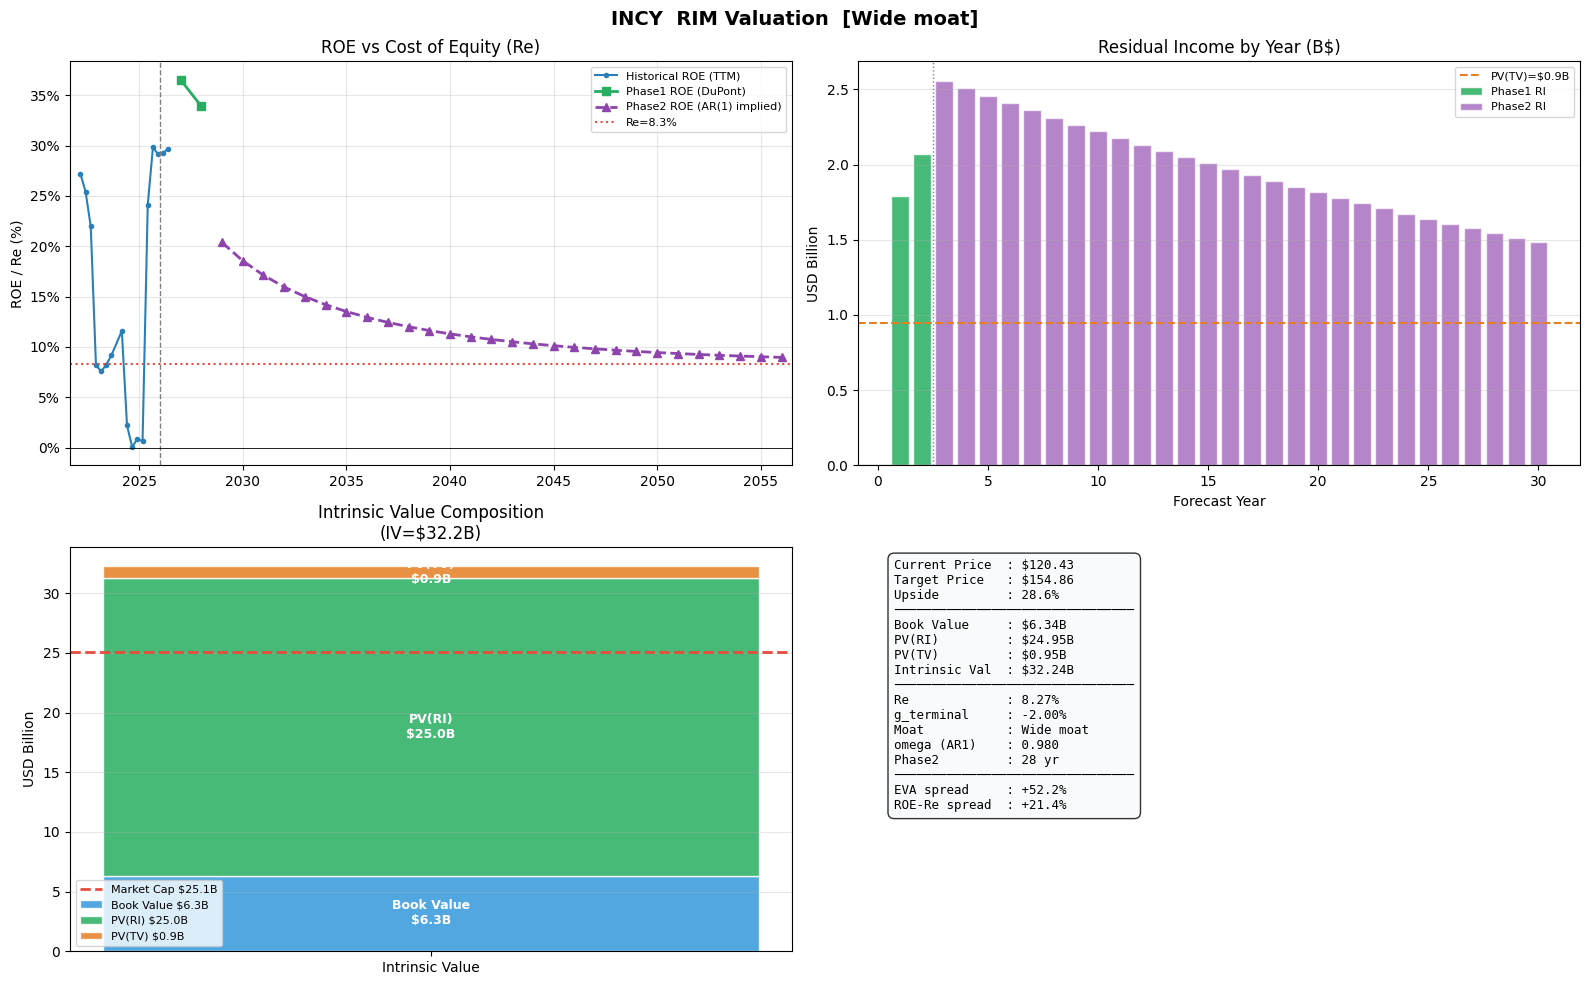

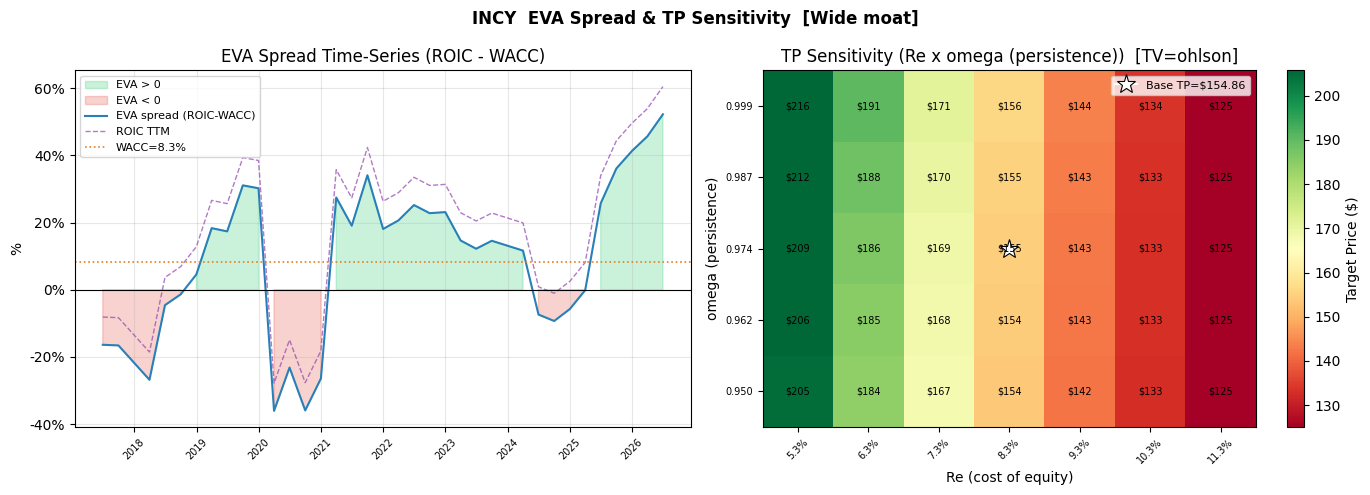

[INCY] _fetch_rim_extras best-effort fail: (1054, "Unknown column 'close_price' in 'field list'")
[00:01:54][INCY] DuPont coefs  NPM=0.3477(ols)  AT=0.697(TTM/Assets median)  FL=1.35(median)
[00:01:54][INCY] DuPont coefs  NPM=0.3477(ols)  AT=0.697(TTM/Assets median)  FL=1.35(median)
[00:01:54][INCY] DuPont coefs  NPM=0.3477(ols)  AT=0.697(TTM/Assets median)  FL=1.35(median)
[INCY] Excel saved: C:\Users\82108\OneDrive\INVESTMENT\미국주식\FCFF_valuation_results\INCY_RIM_20260916_v19format.xlsx

  Excel        : C:\Users\82108\OneDrive\INVESTMENT\미국주식\FCFF_valuation_results\INCY_RIM_20260916_v19format.xlsx
  DB rows      : 0
  Re           : 8.27%    Moat: Wide moat (w=0.980, Ph1=0yr, Ph2=28yr)
  TV mode      : ohlson   TV=$14.15B  (비중 2.9%)
  BV / PV(RI)  : $6.34B / $24.95B   → IV $32.24B
  Target Price : $154.86
  Current Price: $120.43
  Upside       : +28.6%

[개별 RIM Valuation 완료] OK=1  FAIL=0


,status,ticker,target_price,current_price,upside_pct,re,moat_label,omega,n_phase1,n_phase2,rows_saved
0,ok,INCY,154.859097,120.43,28.588472,0.08272,Wide moat,0.98,0,28,0


In [16]:
# ═══════════════════════════════════════════════════════════════════════
#  실행 · 개별 RIM Valuation — INDIVIDUAL_TICKERS 순회  [v15]
#  ───────────────────────────────────────────────────────────────────────
#  순서 (종목별):
#    ① model.run()             — Sales → 재무제표 → DuPont ROE → RI → Valuation
#    ② print_rim_diagnostics   — 진단 출력 (재평가 없음, 같은 객체 재사용)
#    ③ export_rim_excel        — 8-시트 엑셀 (EXPORT_EXCEL=True 일 때)
#    ④ save_to_db              — us_rim_valuation 저장 (SAVE_TO_DB=True 일 때)
#
#  ★ v14: 종목당 run() 호출은 정확히 1회입니다.
#     v13 은 클래스 셀 테스트(패치 전 v11) + 진단 셀(패치 전) + Excel 셀 +
#     배치 셀에서 각각 평가가 일어나 같은 종목의 적정주가가 여러 개 나왔습니다.
#  종목 변경은 Cell 2 의 INDIVIDUAL_TICKERS 만 수정하면 됩니다.
# ═══════════════════════════════════════════════════════════════════════

# ── 사전 검증 — 엔진/패치 적용 여부 ─────────────────────────────────────
assert hasattr(RIMModel, "_check_currency_v12") and \
       getattr(RIMModel.compute_valuation, "__name__", "") == "compute_valuation_v12", \
    "v12 Validity 패치 미적용 — PART 2 (엔진 2) 를 먼저 실행하세요."
assert hasattr(RIMModel, "export_rim_excel"), \
    "Excel Export 미적용 — PART 2 (엔진 3) 을 먼저 실행하세요."
assert "print_rim_diagnostics" in globals(), \
    "진단 함수 미정의 — PART 2 (엔진 4) 를 먼저 실행하세요."

if EXPORT_EXCEL:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)

_ind_results = []
_n = len(INDIVIDUAL_TICKERS)

for _i, _tic in enumerate(INDIVIDUAL_TICKERS, 1):
    print("=" * 72)
    print(f"[{_i}/{_n}] {_tic}   (RUN_DATE={RUN_DATE})")
    print("=" * 72)
    try:
        _m = RIMModel(ticker=_tic, engine=engine, verbose=VERBOSE_SINGLE)

        # ── ① RIM 실행 (유일한 평가 호출) ──────────────────────────────
        _m.run()
        v = _m.valuation

        # ── ② 진단 출력 (재평가 없음) ──────────────────────────────────
        if SHOW_DIAGNOSTICS:
            print_rim_diagnostics(_m, show_plots=SHOW_PLOTS)
        elif SHOW_PLOTS:
            _m.plot()

        # ── ③ Excel export ────────────────────────────────────────────
        _xlsx = (_m.export_rim_excel(out_dir=EXPORT_DIR) if EXPORT_EXCEL
                 else "(엑셀 저장 생략 — EXPORT_EXCEL=False)")

        # ── ④ DB 저장 ─────────────────────────────────────────────────
        _rows = _m.save_to_db(RUN_DATE) if SAVE_TO_DB else 0

        # ── 결과 요약 ─────────────────────────────────────────────────
        print(f"\n  Excel        : {_xlsx}")
        print(f"  DB rows      : {_rows}")
        print(f"  Re           : {v['re'] * 100:.2f}%    "
              f"Moat: {v['moat_label']} (w={v['omega']:.3f}, "
              f"Ph1={v.get('n_phase1', 0)}yr, Ph2={v['n_phase2']}yr)")
        print(f"  TV mode      : {v.get('tv_mode', V12_TV_MODE)}   "
              f"TV=${v['terminal_value'] / 1e9:.2f}B  "
              f"(비중 {v.get('tv_weight_pct', float('nan')):.1f}%)")
        print(f"  BV / PV(RI)  : ${v['bv0'] / 1e9:.2f}B / ${v['pv_ri'] / 1e9:.2f}B"
              f"   → IV ${v['intrinsic_value'] / 1e9:.2f}B")
        print(f"  Target Price : ${v['target_price']:.2f}")
        print(f"  Current Price: ${v['current_price']:.2f}")
        print(f"  Upside       : {v['upside_pct']:+.1f}%")

        _ind_results.append({
            "status": "ok", "ticker": _tic,
            "target_price":  v.get("target_price",  np.nan),
            "current_price": v.get("current_price", np.nan),
            "upside_pct":    v.get("upside_pct",    np.nan),
            "re":            v.get("re",            np.nan),
            "moat_label":    v.get("moat_label", ""),
            "omega":         v.get("omega",         np.nan),
            "n_phase1":      v.get("n_phase1",      0),
            "n_phase2":      v.get("n_phase2",      0),
            "tv_mode":       v.get("tv_mode", ""),
            "mktcap_ratio":  v.get("mktcap_ratio",  np.nan),
            "rows_saved":    _rows,
            "excel":         str(_xlsx),
        })

    except Exception as _e:
        print(f"  ✗ FAIL: {_e}")
        traceback.print_exc()
        _ind_results.append({
            "status": "fail", "ticker": _tic,
            "target_price": np.nan, "current_price": np.nan, "upside_pct": np.nan,
            "re": np.nan, "moat_label": "", "omega": np.nan,
            "n_phase1": 0, "n_phase2": 0, "tv_mode": "", "mktcap_ratio": np.nan,
            "rows_saved": 0, "excel": "", "msg": str(_e)[:120],
        })
    finally:
        clear_memory()

# ── 전체 요약 테이블 ─────────────────────────────────────────────────────
print()
print("=" * 72)
print(f"[개별 RIM Valuation 완료] OK={sum(r['status'] == 'ok' for r in _ind_results)}"
      f"  FAIL={sum(r['status'] == 'fail' for r in _ind_results)}")
print("=" * 72)
individual_summary = pd.DataFrame(_ind_results)
display(individual_summary[["status", "ticker", "target_price", "current_price",
                            "upside_pct", "re", "moat_label", "omega",
                            "n_phase1", "n_phase2", "rows_saved"]])
